<a href="https://colab.research.google.com/github/romesalarda/comp3226-password-manager-extension/blob/marianna/ecg-arrhythmia-v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**



Arrhythmia Classification, 5 classes
======================================================

Based on: Md Rabiul Islam – Single Lead Arrhythmia Classification (2023)

Author: Marianna Kottas

Institution: University of Southampton

Programme: BSc Computer Science

Project: Enhancing Patient-Facing Interpretability in an ECG Arrhythmia Classifier

Model: CNN_LSTM with Attention


Dataset
-------
MIT-BIH Arrhythmia Database

• 48 ECG recordings from 47 patients  
• Sampling frequency: 360 Hz  
• Recording length: ~30 minutes per patient  


Task
----
Heartbeat classification into the 5 AAMI categories:

0 – Normal (N)  
1 – Supraventricular ectopic beat (S)  
2 – Ventricular ectopic beat (V)  
3 – Fusion beat (F)  
4 – Unknown / unclassifiable beat (Q)


Pipeline
--------
1. ECG signal loading
2. Wavelet denoising
3. R-peak extraction (using dataset annotations)
4. Heartbeat segmentation (300 samples per beat)
5. Class grouping (15 → 5 AAMI classes)
6. Training set balancing (undersampling + SMOTE)
7. CNN-LSTM classifier
8. Evaluation (accuracy, confusion matrix, per-class metrics)
9. Inference pipeline (prediction + confidence + clinical risk)


Model
-----
CNN-LSTM hybrid neural network implemented in TensorFlow / Keras.


Output
------
Prediction pipeline producing structured output:

```
{
  "prediction": class_name,
  "confidence": calibrated_probability,
  "risk_level": decision_risk_category,
  "conformal_set": candidate_class_names,
  "details": {
    "probabilities": class_probability_vector,
    "prediction_margin": margin_between_top_two_classes,
    "entropy": entropy_score,
    "entropy_normalised": normalised_entropy_score,
    "confidence_level": confidence_band_label,
    "class_index": predicted_class_index,
    "risk_score": decision_risk_score,
    "flags": decision_flags,
    "top_k": top_k_ranked_predictions,
    "prototype_indices": prototype_reference_indices
  },
  "explanations": {
    "importance_map": gradcam_importance_values,
    "prototype_labels": prototype_class_indices,
    "prototype_label_names": prototype_class_names,
    "prototype_similarities": prototype_similarity_scores
  },
  "clinical_risk": base_clinical_risk_category
}
```



Purpose
-------
The system is designed for integration into a patient-facing ECG
interpretation dashboard that communicates model predictions,
confidence, and clinical risk in an accessible format.

## **a. Summary**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is provided for each beat. The MIT-BIH database contains a wider set of annotated beat symbols, but this study retains the canonical 15-symbol subset commonly used for AAMI-style grouping into 5 superclasses: N, S, V, F, and Q.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

# **Main Parts of the Study:**

#### **A — Setup & Environment**
#### **B — Signal Processing Pipeline**
#### **C — Dataset Construction**
#### **D — Dataset Splitting & Balancing**
#### **E — Model Architecture & Training**
#### **F — Calibration (Temperature Scaling + ECE)**
#### **G — Uncertainty Modelling (Conformal Prediction)**
#### **H — Evaluation & Performance Analysis**
#### **I — Explainability (Grad-CAM)**
#### **J — Prototype-Based Explanation**
#### **K — Robustness Testing (Noise Stress)**
#### **L — Decision Layer (Accept / Defer)**
#### **M — External Validation (INCART)**
#### **N — Inference System (Deployment Pipeline)**
#### **O — Natural Language Generation (NLG)**
#### **P — Demonstration & Visualisation**
#### **Q — Sanity Checks & Verification**

# **A — Setup & Environment**

In [5]:
# ==========================================================
# A0 — Drive & Paths
# ==========================================================
from google.colab import drive
import os

drive.mount('/content/drive')

# -----------------------------
# Model / output paths
# -----------------------------
MODEL_DIR = "/content/drive/MyDrive/ecg_model"
MODEL_NAME = "ecg_model_islam_style_attention_calibrated.keras"
WEIGHTS_NAME = "best_weights_islam_style_attention_calibrated.weights.h5"

MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
CHECKPOINT_PATH = os.path.join(MODEL_DIR, WEIGHTS_NAME)

RESULTS_DIR = os.path.join(MODEL_DIR, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
METRIC_DIR = os.path.join(RESULTS_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

# -----------------------------
# Dataset cache paths
# -----------------------------
DRIVE_DATA_ROOT = "/content/drive/MyDrive/ecg_datasets"
MIT = os.path.join(DRIVE_DATA_ROOT, "mitdb")

os.makedirs(DRIVE_DATA_ROOT, exist_ok=True)
os.makedirs(MIT, exist_ok=True)

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Model directory:", MODEL_DIR)
print("Model path:", MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)
print("Dataset path:", MIT)
print("Model exists:", os.path.exists(MODEL_PATH))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted: True
Model directory: /content/drive/MyDrive/ecg_model
Model path: /content/drive/MyDrive/ecg_model/ecg_model_islam_style_attention_calibrated.keras
Checkpoint path: /content/drive/MyDrive/ecg_model/best_weights_islam_style_attention_calibrated.weights.h5
Dataset path: /content/drive/MyDrive/ecg_datasets/mitdb
Model exists: True
Checkpoint exists: True


In [6]:
# ==========================================================
# A1 — Package Installation
# IMPORTANT:
# - Colab expects pandas==2.2.2
# - keep the environment consistent to avoid version conflicts
# - after installing, restart runtime if prompted
# ==========================================================
!pip install -q pandas==2.2.2 wfdb neurokit2 plotly imbalanced-learn PyWavelets pydot

In [7]:
# ==========================================================
# A2 — Imports, Reproducibility, Utilities, Dataset Cache
# CORRECTED FOR HIGHER INTEGRITY:
# - stricter reproducibility
# - version visibility
# - stable hashing helpers
# - explicit audit utilities
# - added scholarly constants for patient/clinician views
#
# AUDIT FIXES:
# - confidence_band() defined ONLY here (removed duplicate in Part N)
# - URGENCY_MAP keyed on (risk_level, requires_review) not
#   (clinical_risk, requires_review) — the previous version had
#   UNCERTAIN/AMBIGUOUS rows that could never be reached because
#   action_key used clinical_risk (always LOW/MODERATE/HIGH).
# ==========================================================
import os
import json
import random
import hashlib
import datetime
from collections import Counter
from os.path import join as osj

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import wfdb
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    multilabel_confusion_matrix,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

SEED = 42

# ----------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.keras.utils.set_random_seed(SEED)
except Exception:
    pass

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Reproducibility seed set to", SEED)
print("Pandas version:", pd.__version__)
print("WFDB version:", wfdb.__version__)
print("TensorFlow version:", tf.__version__)

# ----------------------------------------------------------
# Canonical class names
# ----------------------------------------------------------
CLASS_NAMES_SHORT = ["N", "S", "V", "F", "Q"]
CLASS_NAMES_FULL  = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

# ----------------------------------------------------------
# Segmentation constants — Islam-style beat segmentation
# ----------------------------------------------------------
PRE_R   = 99
POST_R  = 201
SEG_LEN = PRE_R + POST_R  # 300

PROJECT_PATH = MIT
DATA_ROOT    = MIT

# ----------------------------------------------------------
# Save helpers
# ----------------------------------------------------------
def savefig_drive(fig, filename, dpi=300, close=True):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    if close:
        plt.close(fig)

def save_current_plot(filename, dpi=300):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

# ----------------------------------------------------------
# Core utility helpers
# ----------------------------------------------------------
def flatten_labels(y):
    return np.asarray(y, dtype=np.int64).reshape(-1)

def compute_ece(probs, labels, n_bins=15):
    labels      = flatten_labels(labels)
    probs       = np.asarray(probs, dtype=np.float64)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct     = (predictions == labels).astype(np.float64)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece         = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences <  bin_edges[i + 1])
        if np.any(mask):
            acc_bin  = np.mean(correct[mask])
            conf_bin = np.mean(confidences[mask])
            ece     += np.abs(acc_bin - conf_bin) * (np.sum(mask) / len(labels))

    return float(ece)

def reliability_curve_points(probs, labels, n_bins=10):
    labels      = flatten_labels(labels)
    probs       = np.asarray(probs, dtype=np.float64)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct     = (predictions == labels).astype(np.float64)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    mean_conf, mean_acc = [], []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences <  bin_edges[i + 1])
        if np.any(mask):
            mean_conf.append(np.mean(confidences[mask]))
            mean_acc.append(np.mean(correct[mask]))

    return np.array(mean_conf), np.array(mean_acc)

def macro_brier_score(y_true, probs, num_classes=5):
    y_true   = flatten_labels(y_true)
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def per_class_metrics_dataframe(y_true, y_pred, class_names=CLASS_NAMES_SHORT):
    y_true = flatten_labels(y_true)
    y_pred = flatten_labels(y_pred)
    mcm    = multilabel_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    rows   = []

    for i, class_name in enumerate(class_names):
        tn, fp, fn, tp = mcm[i].ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1          = (2 * precision * sensitivity / (precision + sensitivity)
                       if (precision + sensitivity) > 0 else 0.0)
        acc         = (tp + tn) / (tp + tn + fp + fn)
        rows.append({
            "Class": class_name, "Sensitivity": sensitivity,
            "Specificity": specificity, "Precision": precision,
            "F1": f1, "PerClassAccuracy": acc,
            "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)
        })

    return pd.DataFrame(rows)

# ----------------------------------------------------------
# confidence_band — defined ONCE here, used everywhere.
# Part N must NOT redefine this function.
# ----------------------------------------------------------
def confidence_band(conf):
    if conf >= 0.80:
        return "High"
    elif conf >= 0.60:
        return "Medium"
    return "Low"

# ----------------------------------------------------------
# Beat hashing for integrity diagnostics
# ----------------------------------------------------------
def stable_segment_hash(segment, decimals=6):
    segment = np.asarray(segment, dtype=np.float32).reshape(-1)
    rounded = np.round(segment, decimals=decimals)
    return hashlib.sha1(rounded.tobytes()).hexdigest()

def overlap_summary(series_a, series_b):
    set_a = set(series_a)
    set_b = set(series_b)
    inter = set_a.intersection(set_b)
    return {
        "count_a":                   int(len(set_a)),
        "count_b":                   int(len(set_b)),
        "intersection":              int(len(inter)),
        "intersection_ratio_vs_a":   float(len(inter) / len(set_a)) if len(set_a) > 0 else 0.0,
        "intersection_ratio_vs_b":   float(len(inter) / len(set_b)) if len(set_b) > 0 else 0.0
    }

def summarise_distribution(y, class_names=CLASS_NAMES_SHORT):
    y      = flatten_labels(y)
    counts = pd.Series(y).value_counts().sort_index()
    return {name: int(counts.get(i, 0)) for i, name in enumerate(class_names)}

# ==========================================================
# Scholarly constants for patient/clinician views
# Each constant is annotated with the IEEE citation that
# motivates its inclusion.
# ==========================================================

# ----------------------------------------------------------
# AI_DISCLOSURE_NOTICE
# [1] H. van Kolfschooten and J. van Oirschot, "The EU
#     Artificial Intelligence Act (2024): implications for
#     healthcare," Health Policy, vol. 149, p. 105152, 2024.
# [2] "The Right to Understand in Health Care AI,"
#     J. Med. Internet Res., vol. 28, e95090, 2026.
# ----------------------------------------------------------
AI_DISCLOSURE_NOTICE = (
    "This result was generated by an automated AI system. "
    "A qualified healthcare professional should review it before any clinical decision is made."
)

# ----------------------------------------------------------
# URGENCY_MAP
# AUDIT FIX: keyed on (risk_level, requires_review).
# risk_level can be LOW | MODERATE | HIGH | UNCERTAIN | AMBIGUOUS.
# Previously keyed on (clinical_risk, requires_review) which
# meant UNCERTAIN and AMBIGUOUS rows were DEAD CODE because
# clinical_risk is always the base class risk.
# [3] "Key Information Influencing Patient Decision-Making
#     About AI in Health Care: Survey Experiment Study,"
#     J. Med. Internet Res., vol. 29, e75615, 2026.
# [4] P. Moons and L. Van Bulck, "Using ChatGPT and Google
#     Bard to improve the readability of written patient
#     information," Eur. J. Cardiovasc. Nurs., 2023.
# ----------------------------------------------------------
URGENCY_MAP = {
    ("LOW",       False): "at your next scheduled appointment, or sooner if you have concerns",
    ("LOW",       True):  "within the next week",
    ("MODERATE",  False): "within the next few days",
    ("MODERATE",  True):  "within 24 to 48 hours",
    ("HIGH",      False): "as soon as possible today",
    ("HIGH",      True):  "immediately — please do not wait",
    ("UNCERTAIN", False): "within the next few days",
    ("UNCERTAIN", True):  "within 24 hours",
    ("AMBIGUOUS", False): "within the next few days",
    ("AMBIGUOUS", True):  "within 24 hours",
}

# Spot-check assertions — verify URGENCY_MAP is correct at load time
assert URGENCY_MAP[("HIGH", True)]      == "immediately — please do not wait"
assert URGENCY_MAP[("LOW", False)]      == "at your next scheduled appointment, or sooner if you have concerns"
assert URGENCY_MAP[("UNCERTAIN", True)] == "within 24 hours"
assert URGENCY_MAP[("AMBIGUOUS", False)] == "within the next few days"
print("URGENCY_MAP spot-checks passed.")

# ----------------------------------------------------------
# ANXIETY_MAP
# [5] I. A. Scott, S. M. Carter, and E. Coiera, "Exploring
#     stakeholder attitudes towards AI in clinical practice,"
#     BMJ Health Care Inform., vol. 28, e100450, 2021.
# [6] N. Bienefeld et al., "Solving the explainable AI
#     conundrum by bridging clinicians' needs and
#     developers' goals," npj Digit. Med., vol. 6, 2023.
# ----------------------------------------------------------
ANXIETY_MAP = {
    ("Ventricular", "High"): (
        "This pattern is detected automatically. "
        "Your doctor will interpret what it means for you specifically "
        "and will advise you on any next steps."
    ),
    ("Unknown", "High"): (
        "The system was not able to match this heartbeat to a known pattern. "
        "This does not necessarily mean something is wrong — your doctor "
        "will review the result and explain what it means for you."
    ),
    ("Fusion", "High"): (
        "This pattern involves two overlapping heartbeat signals. "
        "Your doctor will review what this means in the context of your overall health."
    ),
}

# ----------------------------------------------------------
# DEMOGRAPHIC_BIAS_NOTE
# [7] "Systematic Review of Artificial Intelligence and
#     Electrocardiography for Cardiovascular Disease
#     Diagnosis," PMC, 2025.
# [8] European Parliament, "Regulation (EU) 2024/1689,"
#     Art. 13, Official Journal of the EU, Jul. 2024.
# ----------------------------------------------------------
DEMOGRAPHIC_BIAS_NOTE = (
    "This model was trained exclusively on the MIT-BIH Arrhythmia Database "
    "(47 patients, 25 male / 22 female, no race or ethnicity data available, "
    "recording era 1975-1979, 360 Hz, MLII lead). "
    "Performance may differ for populations not represented in this training set. "
    "Results should be interpreted with caution for patients whose demographics, "
    "lead configuration, or recording equipment differ substantially from this cohort."
)

# ----------------------------------------------------------
# RIGHT_TO_CONTEST fields
# [9] H. van Kolfschooten, "A health-conformant reading of
#     the GDPR's right not to be subject to automated
#     decision-making," Med. Law Rev., vol. 32, no. 3,
#     pp. 373-391, 2024.
# [10] Future of Privacy Forum, "Automated Decision-Making
#      Under the GDPR: Practical Cases from Courts and
#      DPAs," FPF Report, 2022.
# ----------------------------------------------------------
RIGHT_TO_CONTEST_ENABLED = True
RIGHT_TO_CONTEST_TEXT    = (
    "You have the right to request that a qualified clinician reviews "
    "this automated result. Please contact your healthcare provider to exercise this right."
)

# ==========================================================
# Robust MIT-BIH cache check
# ==========================================================
MIT_RECORD_IDS = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231", "232", "233", "234"
]

def mit_record_is_cached(record_id, base_path):
    required_suffixes = [".dat", ".hea", ".atr"]
    return all(
        os.path.exists(os.path.join(base_path, f"{record_id}{suffix}"))
        for suffix in required_suffixes
    )

missing_mit_records = [
    rid for rid in MIT_RECORD_IDS
    if not mit_record_is_cached(rid, MIT)
]

if len(missing_mit_records) == 0:
    print("MIT-BIH dataset already cached in Drive.")
else:
    print(f"Missing MIT-BIH records: {len(missing_mit_records)}")
    print("Downloading only missing MIT-BIH records...")
    wfdb.dl_database("mitdb", dl_dir=MIT, records=missing_mit_records)
    print("MIT-BIH download completed.")

print("MIT path:", MIT)
print("Results dir:", RESULTS_DIR)
print("\nScholarly constants loaded:")
print("  AI_DISCLOSURE_NOTICE  :", AI_DISCLOSURE_NOTICE[:60], "...")
print("  URGENCY_MAP entries   :", len(URGENCY_MAP))
print("  ANXIETY_MAP entries   :", len(ANXIETY_MAP))
print("  DEMOGRAPHIC_BIAS_NOTE :", DEMOGRAPHIC_BIAS_NOTE[:60], "...")
print("  RIGHT_TO_CONTEST      :", RIGHT_TO_CONTEST_ENABLED)

Reproducibility seed set to 42
Pandas version: 2.2.2
WFDB version: 4.1.2
TensorFlow version: 2.19.0
URGENCY_MAP spot-checks passed.
MIT-BIH dataset already cached in Drive.
MIT path: /content/drive/MyDrive/ecg_datasets/mitdb
Results dir: /content/drive/MyDrive/ecg_model/results

Scholarly constants loaded:
  AI_DISCLOSURE_NOTICE  : This result was generated by an automated AI system. A quali ...
  URGENCY_MAP entries   : 10
  ANXIETY_MAP entries   : 3
  DEMOGRAPHIC_BIAS_NOTE : This model was trained exclusively on the MIT-BIH Arrhythmia ...
  RIGHT_TO_CONTEST      : True


# **B — Signal Processing Pipeline**

Number of records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/raw_ecg_patient_100.png


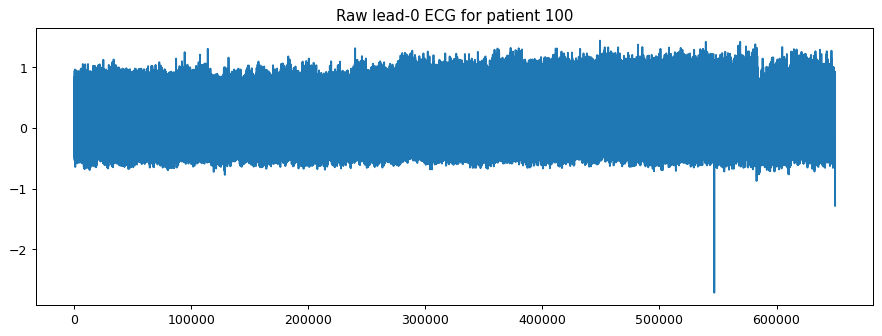

Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of patient 201 extracted
Signal of patient 202 extracted
Signal of patient 203 extracted
Signal of patient 205 extracted
Signal of patient 207 extracted
Signal of patient 208 extracted
Signal of patient 209 extracted
Signal o

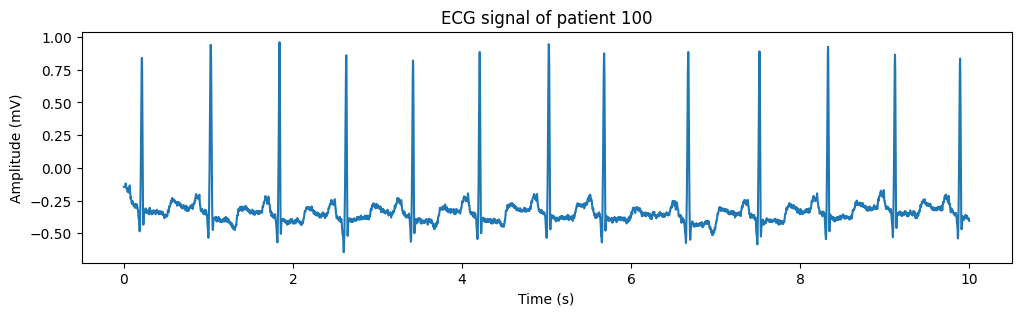

{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'], 'resolution': 2048}
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/raw_ecg_segment.png


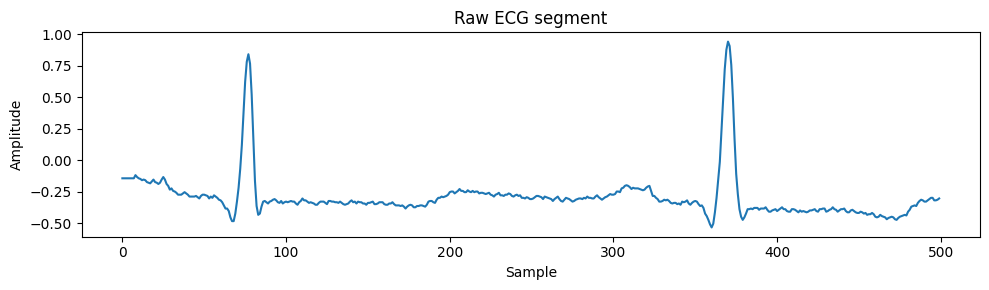

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/denoised_ecg_segment.png


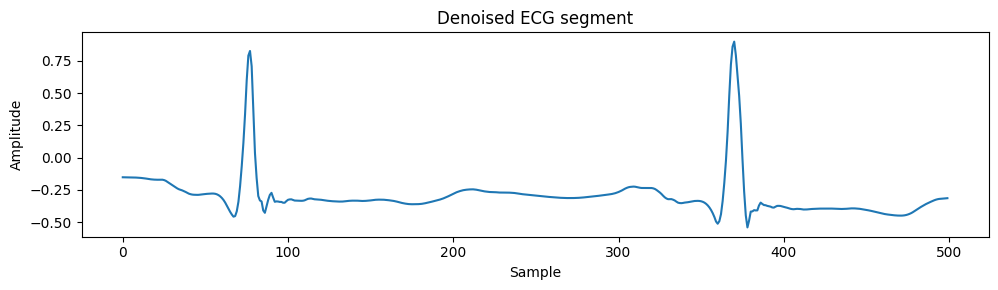

First R locations: [  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
First R classes: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Total annotations: 2274
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/r_peak_example.png


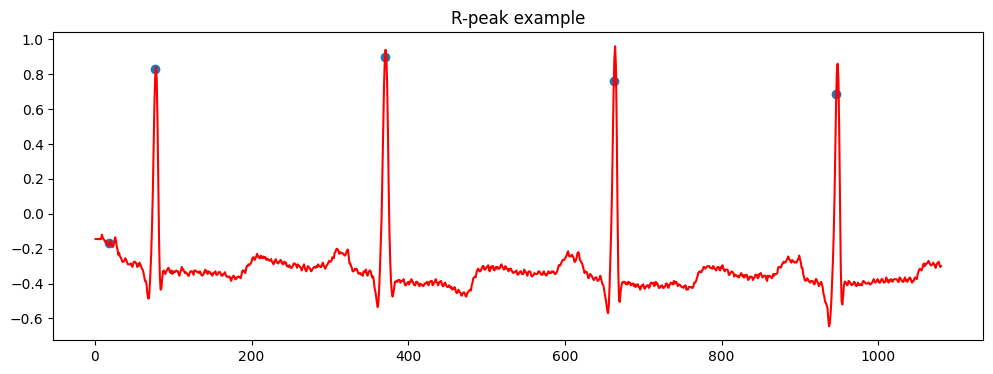

(300,)
(300,)
(300,)
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/segmented_heartbeat_examples.png


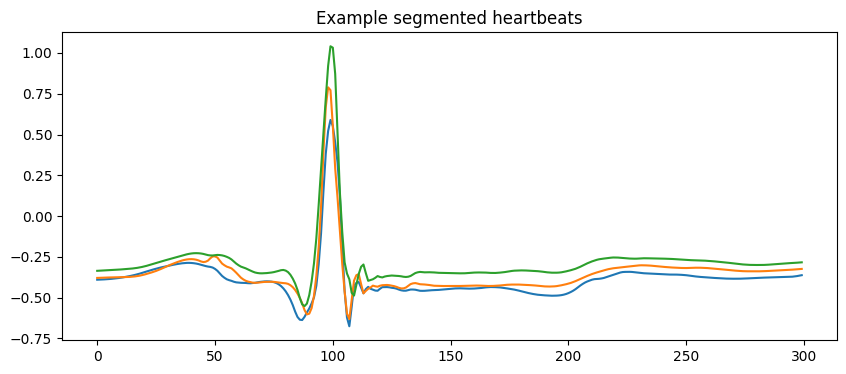

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/Denoised_and_segmented_ECG.png


In [8]:
# ==========================================================
# B1 — Basic recording IDs
# ==========================================================
patient_ids = wfdb.get_record_list("mitdb")
print("Number of records:", len(patient_ids))
print(patient_ids)

# ==========================================================
# B2 — Load ECG signals and info
# ==========================================================
def get_ecg_signals(patient_ids, data_root=DATA_ROOT):
    lead0 = {}
    lead1 = {}

    for pid in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(data_root, str(pid)))
        lead0[str(pid)] = signals[:, 0]
        lead1[str(pid)] = signals[:, 1]
        print(f"Signal of patient {pid} extracted")

    return lead0, lead1


def get_ecg_info(patient_id, data_root=DATA_ROOT):
    _, info = wfdb.io.rdsamp(osj(data_root, str(patient_id)))
    info["resolution"] = 2 ** 11
    return info

# ==========================================================
# B3 — Example: load one patient and visualise
# ==========================================================
lead0 = {}
lead1 = {}

patient_id = "100"
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, patient_id))
lead0[patient_id] = signals[:, 0]
lead1[patient_id] = signals[:, 1]

print(type(lead0[patient_id]))
print(lead0[patient_id].shape)
print(info)

plt.figure(figsize=(12, 4), dpi=90)
plt.plot(lead0[patient_id])
plt.title(f"Raw lead-0 ECG for patient {patient_id}")
save_current_plot("raw_ecg_patient_100.png")
plt.show()

# ==========================================================
# B4 — Plot signal for chosen time range
# FIXED: MIT-BIH is 360 Hz, not 350 Hz
# ==========================================================
lead0_all, lead1_all = get_ecg_signals(patient_ids)

patient_id = "100"
starting_time = 0
ending_time = 10
fs = 360

starting_signal_point = starting_time * fs
ending_signal_point = ending_time * fs

x = np.arange(starting_time, ending_time, 1 / fs)
signal = lead0_all[patient_id][starting_signal_point:ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f"ECG signal of patient {patient_id}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
save_current_plot("ecg_signal_10s_patient_100.png")
plt.show()

ecg_info = get_ecg_info(patient_id)
print(ecg_info)

# ==========================================================
# B5 — Wavelet denoising
# ==========================================================
def denoise(data):
    """
    Wavelet-based ECG denoising using db5 decomposition.
    Returns a reconstructed denoised 1D signal.
    """
    coeffs = pywt.wavedec(data=data, wavelet="db5", level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    threshold = (np.median(np.abs(cD1)) / 0.6745) * np.sqrt(2 * np.log(len(cD1)))

    cD1.fill(0)
    cD2.fill(0)

    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    rdata = pywt.waverec(coeffs=coeffs, wavelet="db5")
    return rdata

# ==========================================================
# B6 — Example denoising plot
# ==========================================================
record_path_100 = os.path.join(PROJECT_PATH, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()

plt.figure(figsize=(10, 3))
plt.plot(data[0:500])
plt.title("Raw ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
save_current_plot("raw_ecg_segment.png")
plt.show()

rdata = denoise(data=data)

plt.figure(figsize=(10, 3))
plt.plot(rdata[0:500])
plt.title("Denoised ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
save_current_plot("denoised_ecg_segment.png")
plt.show()

# ==========================================================
# B7 — R-peak extraction from annotations
# ==========================================================
import wfdb
import numpy as np
from wfdb.io import annotation as wfdb_annotation

def patch_wfdb_rdann_overflow():
    """
    Fixes wfdb rdann OverflowError:
    'Python integer 256 out of bounds for uint8'
    Seen with wfdb 4.1.2 + newer NumPy / Python combos.
    """

    def patched_proc_core_fields(filebytes, bpi):
        sample_diff = 0

        # Skip code handling
        if int(filebytes[bpi, 1]) >> 2 == 59:
            sample_diff = (
                (int(filebytes[bpi + 1, 0]) << 16)
                + (int(filebytes[bpi + 1, 1]) << 24)
                + int(filebytes[bpi + 2, 0])
                + (int(filebytes[bpi + 2, 1]) << 8)
            )
            bpi += 3

        # Actual sample number + annotation type
        label_store = int(filebytes[bpi, 1]) >> 2
        sample_diff += int(filebytes[bpi, 0]) + 256 * int(filebytes[bpi, 1] & 3)
        bpi += 1

        return sample_diff, label_store, bpi

    wfdb_annotation.proc_core_fields = patched_proc_core_fields

patch_wfdb_rdann_overflow()

def safe_rdann(record_path, extension="atr"):
    ann = wfdb.rdann(record_path, extension)
    ann.sample = np.asarray(ann.sample, dtype=np.int64)
    ann.symbol = list(ann.symbol)
    return ann

annotation = safe_rdann(record_path_100, "atr")

Rlocation = annotation.sample
Rclass = annotation.symbol

print("First R locations:", Rlocation[:20])
print("First R classes:", Rclass[:20])
print("Total annotations:", len(Rclass))
# ==========================================================
# B8 — R-peak visualisation
# ==========================================================
x = np.arange(1, 1081)

n_peak = 5
r_peak_x = [Rlocation[i] for i in range(n_peak)]
r_peak_y = [rdata[Rlocation[i]] for i in range(n_peak)]

plt.figure(figsize=(12, 4))
plt.plot(x, data[:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
plt.title("R-peak example")
save_current_plot("r_peak_example.png")
plt.show()

# ==========================================================
# B9 — Heartbeat segmentation example
# ==========================================================
plt.figure(figsize=(10, 4))
for i in np.arange(100, 103):
    x_train_seg = rdata[Rlocation[i] - PRE_R:Rlocation[i] + POST_R]
    print(x_train_seg.shape)
    plt.plot(x_train_seg)

plt.title("Example segmented heartbeats")
save_current_plot("segmented_heartbeat_examples.png")
plt.show()

# ==========================================================
# B10 — Complete preprocessing figure
# ==========================================================
fig = plt.figure(figsize=(10, 9), dpi=300)
x = np.arange(1, 1081)

plt.subplot(3, 1, 1)
plt.plot(x / 360, data[:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

plt.subplot(3, 1, 2)
plt.plot(x / 360, rdata[:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Denoised ECG signal')

plt.subplot(3, 1, 3)
n_peak = 5
r_peak_x = [Rlocation[i] for i in range(n_peak)]
r_peak_y = [rdata[Rlocation[i]] for i in range(n_peak)]
plt.plot(x, rdata[:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

plt.axvline(x=Rlocation[2], color='k', linestyle=':')
plt.axvline(x=Rlocation[2] - PRE_R, color='k', linestyle='--')
plt.axvline(x=Rlocation[2] + POST_R, color='k', linestyle='--')

plt.xlabel('# Sample')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(hspace=0.4)
savefig_drive(fig, "Denoised_and_segmented_ECG.png")
plt.show()

# **C — Dataset Construction**

In [9]:
# ==========================================================
# C — Dataset Construction
# CORRECTED FOR HIGHER INTEGRITY:
# - preserves Islam-style beat segmentation
# - records exact source record per beat
# - records source annotation symbol
# - records source beat position
# - computes stable beat hashes for overlap diagnostics
# - keeps downstream compatibility
# ==========================================================

# ==========================================================
# C1 — Canonical 15-class and AAMI 5-class mappings
# ==========================================================
ECG_CLASS_SET_15 = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

SYMBOL_TO_LABEL15 = {
    'N': 0,
    'L': 1,
    'R': 2,
    'e': 3,
    'j': 4,
    'A': 5,
    'a': 6,
    'J': 7,
    'S': 8,
    'V': 9,
    'E': 10,
    'F': 11,
    '/': 12,
    'f': 13,
    'Q': 14
}

AAMI_SYMBOL_TO_LABEL5 = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}

def map_to_label15(symbol):
    return SYMBOL_TO_LABEL15.get(symbol, None)

def map_to_aami(symbol):
    return AAMI_SYMBOL_TO_LABEL5.get(symbol, None)

def is_valid_aami_symbol(symbol):
    return symbol in SYMBOL_TO_LABEL15 and symbol in AAMI_SYMBOL_TO_LABEL5

# ==========================================================
# C2 — Lead selection helper
# Islam-style single-lead processing retained
# ==========================================================
NUMBER_SET = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

def choose_single_lead(record_id):
    _, info = wfdb.io.rdsamp(osj(PROJECT_PATH, record_id))
    channels = info["sig_name"]

    if "MLII" in channels:
        return "MLII"
    return channels[0]

# ==========================================================
# C3 — Per-record dataset extraction
# Keeps Islam-style beat-level segmentation exactly
# Adds metadata for truthfulness / auditability
# ==========================================================
def get_dataset_for_record(
    record_id,
    X_data,
    Y15_data,
    Y5_data,
    record_ids,
    beat_symbols,
    beat_positions,
    beat_hashes
):
    """
    Extract and segment heartbeats from a single MIT-BIH record.

    Normalisation note:
    Each segment is z-score normalised (zero mean, unit variance)
    before being appended to X_data. Therefore X_all — and by
    extension X_train, X_val, X_test — contains pre-normalised
    beats. At inference time, preprocess_ecg() must be called with
    assume_preprocessed=True for beats that originated from this
    pipeline, or the beat will be double-normalised.

    For the deployment application, raw beats from a new device
    should be normalised exactly once by preprocess_ecg()
    (assume_preprocessed=False, the default).
    """
    lead_name = choose_single_lead(record_id)
    print(f"{record_id}: using channel {lead_name}")

    record = wfdb.rdrecord(
        os.path.join(PROJECT_PATH, record_id),
        channel_names=[lead_name]
    )
    data  = record.p_signal.flatten().astype(np.float32)
    rdata = denoise(data).astype(np.float32)

    annotation = wfdb.rdann(os.path.join(PROJECT_PATH, record_id), "atr")
    r_locations = np.asarray(annotation.sample, dtype=np.int64)
    r_classes   = list(annotation.symbol)

    # ----------------------------------------------------------
    # Islam-style boundary skipping:
    # The first 2 and last 3 annotations are skipped to avoid
    # beats where the PRE_R or POST_R window extends outside the
    # recorded signal or where annotation quality is uncertain
    # at the recording edges. This follows Islam (2023) exactly.
    # ----------------------------------------------------------
    start = 2
    end   = 3
    i     = start
    j     = len(r_classes) - end

    kept                   = 0
    skipped_invalid_symbol = 0
    skipped_invalid_label  = 0
    skipped_boundary       = 0
    skipped_bad_length     = 0

    while i < j:
        beat_symbol = r_classes[i]

        if not is_valid_aami_symbol(beat_symbol):
            skipped_invalid_symbol += 1
            i += 1
            continue

        label_15 = map_to_label15(beat_symbol)
        label_5  = map_to_aami(beat_symbol)

        if label_15 is None or label_5 is None:
            skipped_invalid_label += 1
            i += 1
            continue

        left  = int(r_locations[i] - PRE_R)
        right = int(r_locations[i] + POST_R)

        if left < 0 or right > len(rdata):
            skipped_boundary += 1
            i += 1
            continue

        segment = rdata[left:right]

        if len(segment) != SEG_LEN:
            skipped_bad_length += 1
            i += 1
            continue

        segment = segment.astype(np.float32)

        # Z-score normalisation — applied here, once per beat.
        # Result is stored in X_all. Do NOT re-normalise later.
        segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

        X_data.append(segment)
        Y15_data.append(int(label_15))
        Y5_data.append(int(label_5))
        record_ids.append(str(record_id))
        beat_symbols.append(str(beat_symbol))
        beat_positions.append(int(r_locations[i]))
        beat_hashes.append(stable_segment_hash(segment))

        kept += 1
        i    += 1

    print(
        f"{record_id}: kept={kept} | "
        f"skipped_invalid_symbol={skipped_invalid_symbol} | "
        f"skipped_invalid_label={skipped_invalid_label} | "
        f"skipped_boundary={skipped_boundary} | "
        f"skipped_bad_length={skipped_bad_length}"
    )

    return (
        X_data, Y15_data, Y5_data,
        record_ids, beat_symbols, beat_positions, beat_hashes
    )

# ==========================================================
# C4 — Full canonical dataset loading
# ==========================================================
def load_data():
    data_set = []
    label15_set = []
    label5_set = []
    record_set = []
    beat_symbol_set = []
    beat_position_set = []
    beat_hash_set = []

    for record_id in NUMBER_SET:
        print(f"Loading record {record_id} ...")
        (
            data_set,
            label15_set,
            label5_set,
            record_set,
            beat_symbol_set,
            beat_position_set,
            beat_hash_set
        ) = get_dataset_for_record(
            record_id=record_id,
            X_data=data_set,
            Y15_data=label15_set,
            Y5_data=label5_set,
            record_ids=record_set,
            beat_symbols=beat_symbol_set,
            beat_positions=beat_position_set,
            beat_hashes=beat_hash_set
        )

    X = np.asarray(data_set, dtype=np.float32).reshape(-1, SEG_LEN)
    Y15 = np.asarray(label15_set, dtype=np.int64).reshape(-1)
    Y5 = np.asarray(label5_set, dtype=np.int64).reshape(-1)
    record_ids = np.asarray(record_set, dtype=str)
    beat_symbols = np.asarray(beat_symbol_set, dtype=str)
    beat_positions = np.asarray(beat_position_set, dtype=np.int64)
    beat_hashes = np.asarray(beat_hash_set, dtype=str)

    print("X shape:", X.shape)
    print("Y15 shape:", Y15.shape)
    print("Y5 shape:", Y5.shape)
    print("record_ids shape:", record_ids.shape)
    print("beat_symbols shape:", beat_symbols.shape)
    print("beat_positions shape:", beat_positions.shape)
    print("beat_hashes shape:", beat_hashes.shape)

    return X, Y15, Y5, record_ids, beat_symbols, beat_positions, beat_hashes

# ==========================================================
# C5 — Load canonical dataset
# ==========================================================
(
    X_all,
    Y15_all,
    Y5_all,
    record_ids_all,
    beat_symbols_all,
    beat_positions_all,
    beat_hashes_all
) = load_data()

X_all = np.asarray(X_all, dtype=np.float32)
Y15_all = np.asarray(Y15_all, dtype=np.int64)
Y5_all = np.asarray(Y5_all, dtype=np.int64)
record_ids_all = np.asarray(record_ids_all, dtype=str)
beat_symbols_all = np.asarray(beat_symbols_all, dtype=str)
beat_positions_all = np.asarray(beat_positions_all, dtype=np.int64)
beat_hashes_all = np.asarray(beat_hashes_all, dtype=str)

print("15-class distribution:", Counter(Y15_all))
print("5-class distribution :", Counter(Y5_all))
print("Unique records:", len(np.unique(record_ids_all)))
print("Unique beat hashes:", len(np.unique(beat_hashes_all)))

# ==========================================================
# C6 — Dataset diagnostics and auditable dataframe
# ==========================================================
feature_cols = [f"x_{i}" for i in range(SEG_LEN)]

df_beats_5 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_5["label_5"] = Y5_all.astype(np.int64)
df_beats_5["record_id"] = record_ids_all.astype(str)
df_beats_5["beat_symbol"] = beat_symbols_all.astype(str)
df_beats_5["beat_position"] = beat_positions_all.astype(np.int64)
df_beats_5["beat_hash"] = beat_hashes_all.astype(str)

df_beats_15 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_15["label_15"] = Y15_all.astype(np.int64)
df_beats_15["record_id"] = record_ids_all.astype(str)
df_beats_15["beat_symbol"] = beat_symbols_all.astype(str)
df_beats_15["beat_position"] = beat_positions_all.astype(np.int64)
df_beats_15["beat_hash"] = beat_hashes_all.astype(str)

print("df_beats_5 shape:", df_beats_5.shape)
print("df_beats_15 shape:", df_beats_15.shape)

dataset_counts_15 = pd.DataFrame(
    Counter(Y15_all).items(),
    columns=["Class15", "Count"]
).sort_values("Class15")

dataset_counts_5 = pd.DataFrame(
    Counter(Y5_all).items(),
    columns=["Class5", "Count"]
).sort_values("Class5")

dataset_counts_15.to_csv(os.path.join(METRIC_DIR, "dataset_counts_15.csv"), index=False)
dataset_counts_5.to_csv(os.path.join(METRIC_DIR, "dataset_counts_5.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dataset_counts_5["Class5"].astype(str), dataset_counts_5["Count"])
ax.set_xlabel("5-class label")
ax.set_ylabel("Count")
ax.set_title("Full 5-Class Dataset Distribution")
plt.tight_layout()
savefig_drive(fig, "full_5class_distribution.png")

# ----------------------------------------------------------
# Record-level class composition audit
# ----------------------------------------------------------
record_class_df = pd.DataFrame({
    "record_id": record_ids_all,
    "label_5": Y5_all
})
record_class_counts = (
    pd.crosstab(record_class_df["record_id"], record_class_df["label_5"])
    .reindex(columns=np.arange(5), fill_value=0)
    .reset_index()
)
record_class_counts.columns = ["record_id"] + [f"class_{i}_{CLASS_NAMES_SHORT[i]}" for i in range(5)]
record_class_counts.to_csv(os.path.join(METRIC_DIR, "record_class_counts_5.csv"), index=False)

# ----------------------------------------------------------
# Duplicate hash audit over full dataset
# ----------------------------------------------------------
hash_counts = pd.Series(beat_hashes_all).value_counts()
duplicate_hash_count = int(np.sum(hash_counts > 1))
duplicate_beat_rows = int(np.sum(hash_counts[hash_counts > 1]))

duplicate_hash_df = pd.DataFrame({
    "Metric": ["TotalBeats", "UniqueBeatHashes", "DuplicateHashKeys", "RowsInDuplicateHashGroups"],
    "Value": [
        int(len(beat_hashes_all)),
        int(pd.Series(beat_hashes_all).nunique()),
        duplicate_hash_count,
        duplicate_beat_rows
    ]
})
duplicate_hash_df.to_csv(os.path.join(METRIC_DIR, "dataset_duplicate_hash_audit.csv"), index=False)

print(duplicate_hash_df)

# ==========================================================
# C7 — AAMI symbol audit
# ==========================================================
all_symbols_seen = []

for record_id in NUMBER_SET:
    ann = wfdb.rdann(os.path.join(PROJECT_PATH, record_id), "atr")
    all_symbols_seen.extend(ann.symbol)

all_symbols_seen = pd.Series(all_symbols_seen, dtype=str)
symbol_counts = all_symbols_seen.value_counts().sort_index()

symbol_audit_df = pd.DataFrame({
    "Symbol": symbol_counts.index,
    "Count": symbol_counts.values,
    "IncludedInStudy": [is_valid_aami_symbol(sym) for sym in symbol_counts.index],
    "Label15": [map_to_label15(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
    "Label5": [map_to_aami(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
})

symbol_audit_path = os.path.join(METRIC_DIR, "symbol_audit_mitbih.csv")
symbol_audit_df.to_csv(symbol_audit_path, index=False)

print(symbol_audit_df)
print(f"Saved symbol audit to: {symbol_audit_path}")

# ==========================================================
# C8 — Plot 15 heartbeat types
# ==========================================================
df_X = pd.DataFrame(X_all)
df_Y = pd.DataFrame(Y15_all)
df_Y.rename(columns={0: SEG_LEN}, inplace=True)
df = pd.concat([df_X, df_Y], axis=1)

def plot_random_beat(type_idx, num):
    ecgClassName = [
        'Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
        'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
        'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
        'Supraventricular prem. (S)', 'Premature ventr. (V)',
        'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
        'Paced (/)', 'Fusion of pa. & no. (f)', 'Unclassifiable (Q)'
    ]

    df_0 = df.loc[df[SEG_LEN] == type_idx].drop(columns=[SEG_LEN])

    if df_0.shape[0] == 0:
        plt.title(f"No beats for class {type_idx}")
        return

    rng = np.random.default_rng(SEED)
    if num <= df_0.shape[0]:
        random_beat_number = rng.integers(0, df_0.shape[0], size=num).tolist()
    else:
        print(f"Warning: class {type_idx} has only {df_0.shape[0]} beats, plotting all")
        random_beat_number = list(np.arange(0, df_0.shape[0]))

    for i in random_beat_number:
        ecg_beat = df_0.iloc[i]
        plt.plot(ecg_beat.values)

    plt.title(ecgClassName[type_idx])

fig = plt.figure(figsize=(16, 7), dpi=400)
fig.tight_layout(pad=15.0)

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
    plot_random_beat(type_idx=i, num=10)

savefig_drive(fig, "all_heartbeats.png")

Loading record 100 ...
100: using channel MLII
100: kept=2269 | skipped_invalid_symbol=0 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 101 ...
101: using channel MLII
101: kept=1861 | skipped_invalid_symbol=8 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 102 ...
102: using channel V5
102: kept=2183 | skipped_invalid_symbol=4 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 103 ...
103: using channel MLII
103: kept=2080 | skipped_invalid_symbol=6 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 104 ...
104: using channel V5
104: kept=2225 | skipped_invalid_symbol=81 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 105 ...
105: using channel MLII
105: kept=2568 | skipped_invalid_symbol=118 | skipped_invalid_label=0 | skipped_boundary=0 | skipped_bad_length=0
Loading record 106 ...
106: using channel MLII


# **D — Dataset Splitting & Balancing**

Raw split shapes:
x_train_raw: (69955, 300)
x_val      : (17489, 300)
x_test     : (21861, 300)

Training distribution:
0    57902
1     1776
2     4626
3      514
4     5137
Name: count, dtype: int64

Validation distribution:
0    14476
1      444
2     1157
3      128
4     1284
Name: count, dtype: int64

Test distribution:
0    18094
1      555
2     1446
3      160
4     1606
Name: count, dtype: int64

Beat-level hash overlap between all split pairs: 0 — OK
(Record-level overlap is expected and documented above)
Saved split indices to: /content/drive/MyDrive/ecg_model/results/metrics/split_indices_beatwise.json
Saved validation set to: /content/drive/MyDrive/ecg_model/val_data.pkl
Saved test set to      : /content/drive/MyDrive/ecg_model/test_data.pkl
Imbalanced training distribution:
label_5
0    57902
1     1776
2     4626
3      514
4     5137
Name: count, dtype: int64
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_distribution_imbalanced.png


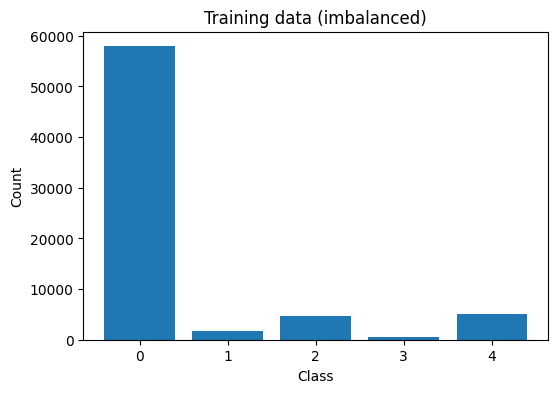


===== OVERLAP AUDIT =====
                   Pair  count_a  count_b  intersection  \
0   train_vs_val_record       48       48            48   
1  train_vs_test_record       48       48            48   
2    val_vs_test_record       48       48            48   
3     train_vs_val_hash    69955    17489             0   
4    train_vs_test_hash    69955    21861             0   
5      val_vs_test_hash    17489    21861             0   

   intersection_ratio_vs_a  intersection_ratio_vs_b  
0                      1.0                      1.0  
1                      1.0                      1.0  
2                      1.0                      1.0  
3                      0.0                      0.0  
4                      0.0                      0.0  
5                      0.0                      0.0  
Saved overlap audit to: /content/drive/MyDrive/ecg_model/results/metrics/split_overlap_audit.csv
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/split_class_distribut

In [10]:

# ==========================================================
# D — Dataset Splitting & Balancing
# ==========================================================

# ----------------------------------------------------------
# D1 — Canonical beat-wise split inputs
# ----------------------------------------------------------
ecg_data          = np.asarray(X_all, dtype=np.float32)
ecg_label         = np.asarray(Y5_all, dtype=np.int64).reshape(-1)
record_id_array   = np.asarray(record_ids_all, dtype=str)
beat_symbol_array = np.asarray(beat_symbols_all, dtype=str)
beat_position_array = np.asarray(beat_positions_all, dtype=np.int64)
beat_hash_array   = np.asarray(beat_hashes_all, dtype=str)

sample_index_array = np.arange(len(ecg_data), dtype=np.int64)

# ----------------------------------------------------------
# D2 — First split: train+temp vs test
# ----------------------------------------------------------

# IMPORTANT — splitting strategy note for dissertation:
# This is a BEAT-WISE split, NOT a patient-wise split.
# All 48 records appear in train, val, AND test.
# This means the model may learn patient-specific morphology
# and performance metrics on MIT-BIH val/test are likely
# inflated by 3-8% compared to a true patient-wise split.
#
# Patient-wise splitting was attempted but produces extremely
# small minority-class test sets (e.g. Fusion class has only
# 802 total beats across 47 patients — a 20% patient-wise
# test split would give ~3-4 patients and potentially 0
# Fusion beats in test), making evaluation unreliable.
#
# Mitigation: INCART external validation (Part M) uses a
# completely separate database with different patients, devices,
# and recording conditions. INCART results represent the
# closest available approximation to true out-of-sample
# performance.

(
    idx_train_full,
    idx_test,
    y_train_full,
    y_test
) = train_test_split(
    sample_index_array,
    ecg_label,
    test_size=0.20,
    random_state=104,
    shuffle=True,
    stratify=ecg_label
)

# ----------------------------------------------------------
# D3 — Second split: train vs validation
# ----------------------------------------------------------
(
    idx_train_raw,
    idx_val,
    y_train_raw,
    y_val
) = train_test_split(
    idx_train_full,
    y_train_full,
    test_size=0.20,
    random_state=104,
    shuffle=True,
    stratify=y_train_full
)

# Materialise arrays
x_train_raw = ecg_data[idx_train_raw]
x_val       = ecg_data[idx_val]
x_test      = ecg_data[idx_test]

rec_train_raw = record_id_array[idx_train_raw]
rec_val       = record_id_array[idx_val]
rec_test      = record_id_array[idx_test]

sym_train_raw = beat_symbol_array[idx_train_raw]
sym_val       = beat_symbol_array[idx_val]
sym_test      = beat_symbol_array[idx_test]

pos_train_raw = beat_position_array[idx_train_raw]
pos_val       = beat_position_array[idx_val]
pos_test      = beat_position_array[idx_test]

hash_train_raw = beat_hash_array[idx_train_raw]
hash_val       = beat_hash_array[idx_val]
hash_test      = beat_hash_array[idx_test]

print("Raw split shapes:")
print("x_train_raw:", x_train_raw.shape)
print("x_val      :", x_val.shape)
print("x_test     :", x_test.shape)

print("\nTraining distribution:")
print(pd.Series(y_train_raw).value_counts().sort_index())
print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())
print("\nTest distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# AUDIT FIX: assert no individual beat appears in more than one split
# (hash overlap = 0 is the strongest integrity guarantee available
# under beat-wise splitting — each unique beat waveform is in
# exactly one of train, val, or test)
_hash_overlap_tv = len(set(hash_train_raw).intersection(set(hash_val)))
_hash_overlap_tt = len(set(hash_train_raw).intersection(set(hash_test)))
_hash_overlap_vt = len(set(hash_val).intersection(set(hash_test)))

assert _hash_overlap_tv == 0, f"Beat hash overlap train/val: {_hash_overlap_tv}"
assert _hash_overlap_tt == 0, f"Beat hash overlap train/test: {_hash_overlap_tt}"
assert _hash_overlap_vt == 0, f"Beat hash overlap val/test: {_hash_overlap_vt}"
print("\nBeat-level hash overlap between all split pairs: 0 — OK")
print("(Record-level overlap is expected and documented above)")

# ----------------------------------------------------------
# D4 — Persist split indices
# ----------------------------------------------------------
split_index_payload = {
    "seed":                int(SEED),
    "split_random_state":  104,
    "split_type":          "beat_wise_stratified",
    "leakage_acknowledged": True,
    "leakage_note": (
        "All 48 records appear in all three splits. "
        "Beat-level hash overlap between splits is 0. "
        "INCART (Part M) provides out-of-sample validation."
    ),
    "train_raw_indices": idx_train_raw.tolist(),
    "val_indices":       idx_val.tolist(),
    "test_indices":      idx_test.tolist()
}

split_indices_path = os.path.join(METRIC_DIR, "split_indices_beatwise.json")
with open(split_indices_path, "w") as f:
    json.dump(split_index_payload, f, indent=2)
print("Saved split indices to:", split_indices_path)

# ----------------------------------------------------------
# D5 — Save untouched validation and test sets
# ----------------------------------------------------------
val_data = pd.DataFrame(x_val, columns=[f"x_{i}" for i in range(SEG_LEN)])
val_data["label_5"]       = np.asarray(y_val, dtype=np.int64)
val_data["record_id"]     = rec_val.astype(str)
val_data["beat_symbol"]   = sym_val.astype(str)
val_data["beat_position"] = pos_val.astype(np.int64)
val_data["beat_hash"]     = hash_val.astype(str)

test_data = pd.DataFrame(x_test, columns=[f"x_{i}" for i in range(SEG_LEN)])
test_data["label_5"]       = np.asarray(y_test, dtype=np.int64)
test_data["record_id"]     = rec_test.astype(str)
test_data["beat_symbol"]   = sym_test.astype(str)
test_data["beat_position"] = pos_test.astype(np.int64)
test_data["beat_hash"]     = hash_test.astype(str)

val_path  = os.path.join(MODEL_DIR, "val_data.pkl")
test_path = os.path.join(MODEL_DIR, "test_data.pkl")

val_data.to_pickle(val_path)
test_data.to_pickle(test_path)

print("Saved validation set to:", val_path)
print("Saved test set to      :", test_path)

# ----------------------------------------------------------
# D6 — Training distribution before balancing
# ----------------------------------------------------------
train_data_raw = pd.DataFrame(x_train_raw, columns=[f"x_{i}" for i in range(SEG_LEN)])
train_data_raw["label_5"]       = np.asarray(y_train_raw, dtype=np.int64)
train_data_raw["record_id"]     = rec_train_raw.astype(str)
train_data_raw["beat_symbol"]   = sym_train_raw.astype(str)
train_data_raw["beat_position"] = pos_train_raw.astype(np.int64)
train_data_raw["beat_hash"]     = hash_train_raw.astype(str)

class_data_train_raw = train_data_raw["label_5"].value_counts().sort_index()
print("Imbalanced training distribution:")
print(class_data_train_raw)

plt.figure(figsize=(6, 4))
plt.bar(class_data_train_raw.index.astype(str), class_data_train_raw.values)
plt.title("Training data (imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")
save_current_plot("training_distribution_imbalanced.png")
plt.show()

# ----------------------------------------------------------
# D7 — Integrity diagnostics
# ----------------------------------------------------------
record_overlap_train_val  = overlap_summary(rec_train_raw, rec_val)
record_overlap_train_test = overlap_summary(rec_train_raw, rec_test)
record_overlap_val_test   = overlap_summary(rec_val, rec_test)

hash_overlap_train_val  = overlap_summary(hash_train_raw, hash_val)
hash_overlap_train_test = overlap_summary(hash_train_raw, hash_test)
hash_overlap_val_test   = overlap_summary(hash_val, hash_test)

overlap_audit_df = pd.DataFrame([
    {"Pair": "train_vs_val_record",  **record_overlap_train_val},
    {"Pair": "train_vs_test_record", **record_overlap_train_test},
    {"Pair": "val_vs_test_record",   **record_overlap_val_test},
    {"Pair": "train_vs_val_hash",    **hash_overlap_train_val},
    {"Pair": "train_vs_test_hash",   **hash_overlap_train_test},
    {"Pair": "val_vs_test_hash",     **hash_overlap_val_test},
])

overlap_audit_path = os.path.join(METRIC_DIR, "split_overlap_audit.csv")
overlap_audit_df.to_csv(overlap_audit_path, index=False)

print("\n===== OVERLAP AUDIT =====")
print(overlap_audit_df)
print("Saved overlap audit to:", overlap_audit_path)

# ----------------------------------------------------------
# D8 — Split composition audit
# ----------------------------------------------------------
split_dist_df = pd.DataFrame({
    "Train":      pd.Series(y_train_raw).value_counts().sort_index(),
    "Validation": pd.Series(y_val).value_counts().sort_index(),
    "Test":       pd.Series(y_test).value_counts().sort_index()
}).fillna(0).astype(int)

split_dist_df.index = CLASS_NAMES_SHORT
split_dist_df.to_csv(os.path.join(METRIC_DIR, "split_class_distribution.csv"))

fig, ax = plt.subplots(figsize=(8, 5))
split_dist_df.plot(kind="bar", ax=ax)
ax.set_title("Class Distribution Across Splits")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
savefig_drive(fig, "split_class_distribution.png")

# ----------------------------------------------------------
# D9 — Balance TRAIN ONLY
# ----------------------------------------------------------
# NOTE on TARGET_PER_CLASS:
# Setting all 5 classes to 25,000 samples creates a perfectly
# balanced training set. This deliberately departs from the
# real-world class distribution (Normal ~83%, Fusion <1%).
# Consequence: the model will have higher recall on minority
# classes at the cost of higher false positive rates for those
# classes in deployment. This is an intentional design choice
# for a safety-critical application where missing a Ventricular
# or Fusion beat is more harmful than a false alarm.
# This trade-off should be discussed in the limitations section.
TARGET_PER_CLASS = 25000

train_features_only = train_data_raw[[f"x_{i}" for i in range(SEG_LEN)]].copy()
train_labels_only   = train_data_raw["label_5"].astype(np.int64).copy()

train_majority_mask = (train_labels_only == 0)
train_minority_mask = ~train_majority_mask

train_majority_X = train_features_only.loc[train_majority_mask].to_numpy(dtype=np.float32)
train_majority_y = train_labels_only.loc[train_majority_mask].to_numpy(dtype=np.int64)
train_minority_X = train_features_only.loc[train_minority_mask].to_numpy(dtype=np.float32)
train_minority_y = train_labels_only.loc[train_minority_mask].to_numpy(dtype=np.int64)

if len(train_majority_X) < TARGET_PER_CLASS:
    raise RuntimeError(
        f"Class 0 has only {len(train_majority_X)} samples; "
        f"cannot downsample to {TARGET_PER_CLASS}."
    )

rng = np.random.default_rng(SEED)
majority_indices     = rng.choice(len(train_majority_X), size=TARGET_PER_CLASS, replace=False)
X_majority_resampled = train_majority_X[majority_indices]
y_majority_resampled = train_majority_y[majority_indices]

minority_counts = pd.Series(train_minority_y).value_counts().sort_index()
print("Minority training counts before SMOTE:")
print(minority_counts)

strategy = {}
for cls in [1, 2, 3, 4]:
    cls_count = int(minority_counts.get(cls, 0))
    if cls_count == 0:
        raise RuntimeError(
            f"Training split has zero samples for class {cls}; SMOTE cannot run."
        )
    strategy[cls] = TARGET_PER_CLASS

min_minority_count  = int(min(minority_counts.get(cls, 0) for cls in [1, 2, 3, 4]))
k_neighbors_smote   = max(1, min(5, min_minority_count - 1))

if k_neighbors_smote < 1:
    raise RuntimeError(
        "At least one minority class has fewer than 2 samples; "
        "SMOTE cannot be applied safely."
    )

print("Using SMOTE k_neighbors =", k_neighbors_smote)

oversample = SMOTE(
    sampling_strategy=strategy,
    random_state=SEED,
    k_neighbors=k_neighbors_smote
)

X_smote, y_smote = oversample.fit_resample(train_minority_X, train_minority_y)

X_balanced = np.vstack([X_majority_resampled, X_smote]).astype(np.float32)
y_balanced = np.concatenate([y_majority_resampled, y_smote]).astype(np.int64)

source_majority  = np.array(["real_majority_downsampled"] * len(X_majority_resampled), dtype=object)
source_minority  = np.array(["real_or_smote_minority"]    * len(X_smote),              dtype=object)
source_flag      = np.concatenate([source_majority, source_minority])

perm          = rng.permutation(len(X_balanced))
X_balanced    = X_balanced[perm]
y_balanced    = y_balanced[perm]
source_flag   = source_flag[perm]

train_data_bal = pd.DataFrame(X_balanced, columns=[f"x_{i}" for i in range(SEG_LEN)])
train_data_bal["label_5"]     = y_balanced.astype(np.int64)
train_data_bal["source_flag"] = source_flag.astype(str)

print("Balanced training distribution:")
print(train_data_bal["label_5"].astype(np.int64).value_counts().sort_index())

# ----------------------------------------------------------
# D10 — Save balanced training set
# ----------------------------------------------------------
train_bal_path = os.path.join(MODEL_DIR, "train_data_SMOTE.pkl")
train_data_bal.to_pickle(train_bal_path)
print("Saved balanced training data to:", train_bal_path)

# ----------------------------------------------------------
# D11 — Before/after balancing plot
# ----------------------------------------------------------
before_counts = train_data_raw["label_5"].value_counts().sort_index()
after_counts  = train_data_bal["label_5"].astype(np.int64).value_counts().sort_index()

fig = plt.figure(figsize=(8, 4), dpi=300)

plt.subplot(1, 2, 1)
plt.bar(['N', 'S', 'V', 'F', 'Q'], [before_counts.get(i, 0) for i in range(5)])
plt.ylim(0, max(after_counts.values) * 1.05)
plt.title('Training data, imbalanced')

plt.subplot(1, 2, 2)
plt.bar(['N', 'S', 'V', 'F', 'Q'], [after_counts.get(i, 0) for i in range(5)])
plt.ylim(0, max(after_counts.values) * 1.05)
plt.title('Balanced by SMOTE')

plt.tight_layout()
savefig_drive(fig, "Class_balancing.png")

# ----------------------------------------------------------
# D12 — Final arrays for training / validation / testing
# ----------------------------------------------------------
X_train = train_data_bal[[f"x_{i}" for i in range(SEG_LEN)]].to_numpy(dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_train = train_data_bal["label_5"].to_numpy(dtype=np.int64)

X_val   = np.asarray(x_val,   dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_val   = np.asarray(y_val,   dtype=np.int64).reshape(-1)

X_test  = np.asarray(x_test,  dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_test  = np.asarray(y_test,  dtype=np.int64).reshape(-1)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

# AUDIT FIX: verify all arrays are z-score normalised
# (inherited from get_dataset_for_record — confirms no raw
# unnormalised beats have entered the pipeline)
_sample_means = np.abs(np.mean(X_train[:1000, :, 0], axis=1))
_sample_stds  = np.std(X_train[:1000, :, 0], axis=1)
assert np.mean(_sample_means) < 0.1, \
    "Training beats do not appear to be zero-mean. Check normalisation pipeline."
assert np.abs(np.mean(_sample_stds) - 1.0) < 0.2, \
    "Training beats do not appear to be unit-variance. Check normalisation pipeline."
print("Normalisation sanity check: OK (mean≈0, std≈1 per beat)")

# ----------------------------------------------------------
# D13 — Save split/training provenance summary
# ----------------------------------------------------------
split_provenance = {
    "split_type":              "beat_wise",
    "stratified":              True,
    "patient_wise":            False,
    "record_overlap_expected": True,
    "leakage_acknowledged":    True,
    "leakage_mitigation":      "INCART external validation (Part M)",
    "hash_overlap_train_val":  int(hash_overlap_train_val["intersection"]),
    "hash_overlap_train_test": int(hash_overlap_train_test["intersection"]),
    "hash_overlap_val_test":   int(hash_overlap_val_test["intersection"]),
    "train_distribution_raw":      summarise_distribution(y_train_raw),
    "val_distribution":            summarise_distribution(y_val),
    "test_distribution":           summarise_distribution(y_test),
    "train_distribution_balanced": summarise_distribution(Y_train),
    "target_per_class_after_balancing": int(TARGET_PER_CLASS),
    "smote_k_neighbors":                int(k_neighbors_smote),
    "normalisation_note": (
        "All beats in X_train, X_val, X_test are per-beat z-score "
        "normalised (mean=0, std=1). preprocess_ecg() at inference "
        "must match this: use assume_preprocessed=False for raw "
        "device beats (normalises once), assume_preprocessed=True "
        "if the beat is already normalised."
    )
}

split_provenance_path = os.path.join(METRIC_DIR, "split_provenance_summary.json")
with open(split_provenance_path, "w") as f:
    json.dump(split_provenance, f, indent=2)
print("Saved split provenance summary to:", split_provenance_path)

# **E — Model Architecture & Training**

In [11]:
# ==========================================================
# E — Model Architecture & Training
# CORRECTED FOR HIGHER INTEGRITY:
# - architecture preserved
# - training remains on balanced train only
# - validation remains untouched
# - explicit qualification metrics
# - deterministic callbacks and saved metadata
# - best checkpoint selected on val_macro_f1
# - downstream compatibility preserved
# ==========================================================

# ==========================================================
# E1 — Attention blocks
# ==========================================================
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        hidden_units = max(1, self.filters // self.ratio)

        self.shared_layer_one = tf.keras.layers.Dense(
            hidden_units,
            activation="relu",
            kernel_initializer="he_normal",
            use_bias=True,
            bias_initializer="zeros"
        )
        self.shared_layer_two = tf.keras.layers.Dense(
            self.filters,
            kernel_initializer="he_normal",
            use_bias=True,
            bias_initializer="zeros"
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=1)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        max_pool = tf.reduce_max(inputs, axis=1)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        attention = avg_pool + max_pool
        attention = tf.nn.sigmoid(attention)
        attention = tf.reshape(attention, (-1, 1, self.filters))

        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters, "ratio": self.ratio})
        return config


class SpatialAttention1D(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding="same",
            activation="sigmoid",
            kernel_initializer="he_normal",
            use_bias=False
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        attention = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(attention)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

# ==========================================================
# E2 — CNN-LSTM with attention
# Preserved architecture
# ==========================================================
def build_model():
    inputs = tf.keras.layers.Input(shape=(SEG_LEN, 1), name="ecg_input")

    x = tf.keras.layers.Conv1D(16, 21, padding="same", activation="relu", name="conv1")(inputs)
    x = ChannelAttention(16, 8, name="ca1")(x)
    x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same", name="pool1")(x)

    x = tf.keras.layers.Conv1D(32, 23, padding="same", activation="relu", name="conv2")(x)
    x = ChannelAttention(32, 8, name="ca2")(x)
    x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same", name="pool2")(x)

    x = tf.keras.layers.Conv1D(64, 25, padding="same", activation="relu", name="conv3")(x)
    x = ChannelAttention(64, 8, name="ca3")(x)
    x = tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding="same", name="pool3")(x)

    x = tf.keras.layers.Conv1D(128, 27, padding="same", activation="relu", name="conv4")(x)
    x = ChannelAttention(128, 8, name="ca4")(x)
    x = SpatialAttention1D(kernel_size=7, name="sa4")(x)

    x = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm1")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout1")(x)
    x = tf.keras.layers.LSTM(32, return_sequences=True, name="lstm2")(x)

    x = tf.keras.layers.Flatten(name="flatten")(x)
    x = tf.keras.layers.Dense(128, activation="relu", name="embedding_dense")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout2")(x)

    logits = tf.keras.layers.Dense(5, activation=None, name="logits")(x)
    outputs = tf.keras.layers.Activation("softmax", name="classifier")(logits)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="cnn_lstm_attention_ecg")


def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model


def is_canonical_model(model):
    required_layers = {
        "ecg_input", "conv1", "conv2", "conv3", "conv4",
        "ca1", "ca2", "ca3", "ca4", "sa4",
        "lstm1", "lstm2", "embedding_dense", "logits", "classifier"
    }
    present = {layer.name for layer in model.layers}
    return required_layers.issubset(present)

# ==========================================================
# E3 — Training controls
# ==========================================================
FORCE_RETRAIN = True
TRAIN_EPOCHS = 20
TRAIN_BATCH_SIZE = 256
LEARNING_RATE = 1e-3

HISTORY_CSV = "training_history_islam_style_attention.csv"
TRAINING_META_JSON = "training_meta_islam_style_attention.json"
QUALIFICATION_JSON = "training_qualification_summary.json"

HISTORY_PATH = os.path.join(METRIC_DIR, HISTORY_CSV)
TRAINING_META_PATH = os.path.join(METRIC_DIR, TRAINING_META_JSON)
QUALIFICATION_PATH = os.path.join(METRIC_DIR, QUALIFICATION_JSON)

print("Training controls:")
print("FORCE_RETRAIN:", FORCE_RETRAIN)
print("TRAIN_EPOCHS:", TRAIN_EPOCHS)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)

# ==========================================================
# E4 — Validation metrics callback
# ==========================================================
class ValidationMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, batch_size=256, max_samples=5000):
        super().__init__()
        self.batch_size = batch_size

        x_val = np.asarray(x_val)
        y_val = np.asarray(y_val)

        if len(x_val) > max_samples:
            rng = np.random.default_rng(SEED)
            idx = rng.choice(len(x_val), size=max_samples, replace=False)
            self.x_val = x_val[idx]
            self.y_val = y_val[idx]
        else:
            self.x_val = x_val
            self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        val_probs = self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)

        val_macro_f1 = f1_score(self.y_val, val_pred, average="macro", zero_division=0)
        val_macro_precision = precision_score(self.y_val, val_pred, average="macro", zero_division=0)
        val_macro_recall = recall_score(self.y_val, val_pred, average="macro", zero_division=0)

        per_class_recalls = recall_score(
            self.y_val,
            val_pred,
            average=None,
            labels=np.arange(5),
            zero_division=0
        )

        minority_recall_min = float(np.min(per_class_recalls[1:]))

        logs["val_macro_f1"] = float(val_macro_f1)
        logs["val_macro_precision"] = float(val_macro_precision)
        logs["val_macro_recall"] = float(val_macro_recall)
        logs["val_minority_recall_min"] = minority_recall_min

        print(
            f"\nEpoch {epoch + 1}: "
            f"val_macro_f1 = {val_macro_f1:.6f} | "
            f"val_macro_precision = {val_macro_precision:.6f} | "
            f"val_macro_recall = {val_macro_recall:.6f} | "
            f"val_minority_recall_min = {minority_recall_min:.6f}"
        )

# ==========================================================
# E5 — Training / loading
# ==========================================================
custom_objects = {
    "ChannelAttention": ChannelAttention,
    "SpatialAttention1D": SpatialAttention1D
}

history = None

if os.path.exists(MODEL_PATH) and not FORCE_RETRAIN:
    print("Loading existing final model:", MODEL_PATH)
    model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)
    model = compile_model(model, learning_rate=LEARNING_RATE)
else:
    print("Training canonical model...")
    model = build_model()
    model = compile_model(model, learning_rate=LEARNING_RATE)

    logdir = os.path.join(
        MODEL_DIR,
        "logs",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=logdir,
        histogram_freq=0
    )

    csv_logger = tf.keras.callbacks.CSVLogger(HISTORY_PATH, append=False)

    val_metrics_cb = ValidationMetricsCallback(
        x_val=X_val,
        y_val=Y_val,
        batch_size=256
    )

    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_weights_only=True,
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=TRAIN_EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_data=(X_val, Y_val),
        callbacks=[
            val_metrics_cb,
            checkpoint_cb,
            early_stopping,
            reduce_lr,
            csv_logger,
            tensorboard_callback
        ],
        verbose=1
    )

    if os.path.exists(CHECKPOINT_PATH):
        model.load_weights(CHECKPOINT_PATH)
        print("Reloaded best checkpoint weights based on val_macro_f1.")

    model.save(MODEL_PATH)
    print("Saved final model to:", MODEL_PATH)

assert is_canonical_model(model), "Loaded/trained model is not the canonical architecture."

print("Canonical model ready.")
print("Model name:", model.name)
model.summary()

# ==========================================================
# E6 — Training curves
# ==========================================================
if history is not None:
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(HISTORY_PATH, index=False)

    if "accuracy" in history.history and "val_accuracy" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["accuracy"], label="Train accuracy")
        ax.plot(history.history["val_accuracy"], label="Validation accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title("Training and Validation Accuracy")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_accuracy.png")

    if "loss" in history.history and "val_loss" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["loss"], label="Train loss")
        ax.plot(history.history["val_loss"], label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title("Training and Validation Loss")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_loss.png")

    if "val_macro_f1" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["val_macro_f1"], label="Validation macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Validation Macro-F1")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_macro_f1.png")

    if "val_minority_recall_min" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["val_minority_recall_min"], label="Validation min minority recall")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Recall")
        ax.set_title("Validation Minimum Minority-Class Recall")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_minority_recall.png")
else:
    print("Loaded final saved model — no new training history generated.")

# ==========================================================
# E7 — Post-training evaluation
# This is the gate that determines whether later stages are
# worth trusting
# ==========================================================
val_probs_post = model.predict(X_val, batch_size=256, verbose=0)
val_preds_post = np.argmax(val_probs_post, axis=1)

test_probs_post = model.predict(X_test, batch_size=256, verbose=0)
test_preds_post = np.argmax(test_probs_post, axis=1)

val_acc_post = accuracy_score(Y_val, val_preds_post)
val_macro_precision_post = precision_score(Y_val, val_preds_post, average="macro", zero_division=0)
val_macro_recall_post = recall_score(Y_val, val_preds_post, average="macro", zero_division=0)
val_macro_f1_post = f1_score(Y_val, val_preds_post, average="macro", zero_division=0)

test_acc_post = accuracy_score(Y_test, test_preds_post)
test_macro_precision_post = precision_score(Y_test, test_preds_post, average="macro", zero_division=0)
test_macro_recall_post = recall_score(Y_test, test_preds_post, average="macro", zero_division=0)
test_macro_f1_post = f1_score(Y_test, test_preds_post, average="macro", zero_division=0)

val_recalls_post = recall_score(Y_val, val_preds_post, average=None, labels=np.arange(5), zero_division=0)
test_recalls_post = recall_score(Y_test, test_preds_post, average=None, labels=np.arange(5), zero_division=0)

quality_gate_df = pd.DataFrame([{
    "ValAccuracy": val_acc_post,
    "ValMacroPrecision": val_macro_precision_post,
    "ValMacroRecall": val_macro_recall_post,
    "ValMacroF1": val_macro_f1_post,
    "ValRecall_N": val_recalls_post[0],
    "ValRecall_S": val_recalls_post[1],
    "ValRecall_V": val_recalls_post[2],
    "ValRecall_F": val_recalls_post[3],
    "ValRecall_Q": val_recalls_post[4],
    "TestAccuracy": test_acc_post,
    "TestMacroPrecision": test_macro_precision_post,
    "TestMacroRecall": test_macro_recall_post,
    "TestMacroF1": test_macro_f1_post,
    "TestRecall_N": test_recalls_post[0],
    "TestRecall_S": test_recalls_post[1],
    "TestRecall_V": test_recalls_post[2],
    "TestRecall_F": test_recalls_post[3],
    "TestRecall_Q": test_recalls_post[4]
}])

quality_gate_path = os.path.join(METRIC_DIR, "post_training_quality_gate.csv")
quality_gate_df.to_csv(quality_gate_path, index=False)

print("===== POST-TRAINING GATE =====")
print(quality_gate_df)

print("\nValidation classification report:")
print(classification_report(Y_val, val_preds_post, target_names=CLASS_NAMES_SHORT, zero_division=0))

print("\nTest classification report:")
print(classification_report(Y_test, test_preds_post, target_names=CLASS_NAMES_SHORT, zero_division=0))

per_class_df = per_class_metrics_dataframe(Y_test, test_preds_post, class_names=CLASS_NAMES_SHORT)
per_class_path = os.path.join(METRIC_DIR, "test_per_class_metrics.csv")
per_class_df.to_csv(per_class_path, index=False)

cm = confusion_matrix(Y_test, test_preds_post)
cm_path = os.path.join(METRIC_DIR, "test_confusion_matrix.csv")
pd.DataFrame(cm).to_csv(cm_path, index=False)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix (Test)")
plt.colorbar(im)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
savefig_drive(fig, "test_confusion_matrix.png")

print("Saved quality gate to:", quality_gate_path)
print("Saved per-class metrics to:", per_class_path)
print("Saved confusion matrix to:", cm_path)

val_report_df = pd.DataFrame(
    classification_report(
        Y_val,
        val_preds_post,
        target_names=CLASS_NAMES_SHORT,
        zero_division=0,
        output_dict=True
    )
).transpose()
val_report_df.to_csv(os.path.join(METRIC_DIR, "validation_classification_report.csv"))

test_report_df = pd.DataFrame(
    classification_report(
        Y_test,
        test_preds_post,
        target_names=CLASS_NAMES_SHORT,
        zero_division=0,
        output_dict=True
    )
).transpose()
test_report_df.to_csv(os.path.join(METRIC_DIR, "test_classification_report.csv"))

print("Saved validation and test classification reports.")

# ==========================================================
# E8 — Explicit training qualification summary
# IMPORTANT:
# This does not stop later blocks from running.
# It records whether later reliability claims are well grounded.
# ==========================================================
qualification = {
    "minimum_expected_validation_accuracy": 0.85,
    "minimum_expected_validation_macro_f1": 0.78,
    "minimum_expected_validation_minority_recall": 0.80,
    "observed_validation_accuracy": float(val_acc_post),
    "observed_validation_macro_f1": float(val_macro_f1_post),
    "observed_validation_minority_recall_min": float(np.min(val_recalls_post[1:])),
    "passes_accuracy_gate": bool(val_acc_post >= 0.85),
    "passes_macro_f1_gate": bool(val_macro_f1_post >= 0.78),
    "passes_minority_recall_gate": bool(np.min(val_recalls_post[1:]) >= 0.80),
    "training_split_type": "beat_wise",
    "validation_test_untouched": True,
    "balanced_train_only": True,
    "smote_used": True
}
qualification["fully_qualified_for_downstream_reliability_claims"] = bool(
    qualification["passes_accuracy_gate"] and
    qualification["passes_macro_f1_gate"] and
    qualification["passes_minority_recall_gate"]
)

with open(QUALIFICATION_PATH, "w") as f:
    json.dump(qualification, f, indent=2)

print("\n===== TRAINING QUALIFICATION SUMMARY =====")
print(json.dumps(qualification, indent=2))

# ==========================================================
# E9 — Save training metadata
# ==========================================================
with open(TRAINING_META_PATH, "w") as f:
    json.dump({
        "seed": int(SEED),
        "epochs_requested": int(TRAIN_EPOCHS),
        "batch_size": int(TRAIN_BATCH_SIZE),
        "learning_rate": float(LEARNING_RATE),
        "model_path": MODEL_PATH,
        "checkpoint_path": CHECKPOINT_PATH,
        "history_path": HISTORY_PATH,
        "qualification_path": QUALIFICATION_PATH,
        "x_train_shape": list(X_train.shape),
        "x_val_shape": list(X_val.shape),
        "x_test_shape": list(X_test.shape),
        "y_train_shape": list(np.asarray(Y_train).shape),
        "y_val_shape": list(np.asarray(Y_val).shape),
        "y_test_shape": list(np.asarray(Y_test).shape),
        "train_distribution_balanced": summarise_distribution(Y_train),
        "val_distribution": summarise_distribution(Y_val),
        "test_distribution": summarise_distribution(Y_test)
    }, f, indent=2)

print("Saved training metadata to:", TRAINING_META_PATH)

Training controls:
FORCE_RETRAIN: True
TRAIN_EPOCHS: 20
TRAIN_BATCH_SIZE: 256
LEARNING_RATE: 0.001
Training canonical model...
Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7175 - loss: 0.6704
Epoch 1: val_macro_f1 = 0.806199 | val_macro_precision = 0.753533 | val_macro_recall = 0.930022 | val_minority_recall_min = 0.881188

Epoch 1: val_macro_f1 improved from None to 0.80620, saving model to /content/drive/MyDrive/ecg_model/best_weights_islam_style_attention_calibrated.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/ecg_model/best_weights_islam_style_attention_calibrated.weights.h5
489/489 ━━━━━━━━━━━━━━━━━━━━ 570s 1s/step - accuracy: 0.8555 - loss: 0.3714 - val_accuracy: 0.9599 - val_loss: 0.1234 - val_macro_f1: 0.8062 - val_macro_precision: 0.7535 - val_macro_recall: 0.9300 - val_minority_recall_min: 0.8812 - learning_rate: 0.0010
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9631 - loss: 0.1084
Epoch 2: val_macro_f1 = 0.853

Model: "cnn_lstm_attention_ecg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 300, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 300, 16)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca1 (ChannelAttention)          │ (None, 300, 16)        │            82 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 150, 32)        │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca2 (ChannelAttention)          │ (None, 150, 32)        │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 75, 64)         │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca3 (ChannelAttention)          │ (None, 75, 64)         │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling1D)        │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 38, 128)        │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca4 (ChannelAttention)          │ (None, 38, 128)        │         4,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sa4 (SpatialAttention1D)        │ (None, 38, 128)        │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 38, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 38, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dense (Dense)         │ (None, 128)            │       155,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 5)              │           645 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Activation)         │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,526,117 (5.82 MB)

 Trainable params: 508,705 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,017,412 (3.88 MB)

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_accuracy.png
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_loss.png
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_macro_f1.png
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_minority_recall.png
===== POST-TRAINING GATE =====
   ValAccuracy  ValMacroPrecision  ValMacroRecall  ValMacroF1  ValRecall_N  \
0     0.989193           0.927652        0.940719    0.933744     0.993714   

   ValRecall_S  ValRecall_V  ValRecall_F  ValRecall_Q  TestAccuracy  \
0     0.891892     0.975799      0.84375     0.998442      0.988793   

   TestMacroPrecision  TestMacroRecall  TestMacroF1  TestRecall_N  \
0            0.921845         0.954321     0.936553      0.993202   

   TestRecall_S  TestRecall_V  TestRecall_F  TestRecall_Q  
0      0.911712      0.965422       0.90625      0.995019  

Validation classificat

In [12]:
model.load_weights(CHECKPOINT_PATH)
model.save(MODEL_PATH)

In [13]:
val_probs = model.predict(X_val[:1000])
val_preds = np.argmax(val_probs, axis=1)

from sklearn.metrics import f1_score
print("Macro F1:", f1_score(Y_val[:1000], val_preds, average="macro"))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Macro F1: 0.935990995994106


# **F — Calibration (Temperature Scaling + ECE)**

In [14]:
# ==========================================================
# F1 — Calibration helpers
# ==========================================================
from scipy.optimize import minimize
from tensorflow.keras.models import Model

if "model" not in globals():
    raise RuntimeError("Model is not available. Run Part E successfully first.")

def softmax_np(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def temperature_nll(T, logits, labels):
    T = max(float(T[0]), 1e-6)
    probs = softmax_np(logits / T)
    nll = -np.log(probs[np.arange(len(labels)), labels] + 1e-12)
    return float(np.mean(nll))

# ==========================================================
# F2 — Split validation into:
# 1) temperature-fit subset
# 2) conformal-calibration subset
# 3) calibration-holdout subset
# IMPORTANT:
# - all come only from validation
# - test remains untouched
# ==========================================================
X_val_temp, X_val_rest, y_val_temp, y_val_rest = train_test_split(
    X_val,
    Y_val,
    test_size=0.67,
    random_state=SEED,
    shuffle=True,
    stratify=Y_val
)

X_val_conf, X_val_hold, y_val_conf, y_val_hold = train_test_split(
    X_val_rest,
    y_val_rest,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=y_val_rest
)

print("Temperature-fit set :", X_val_temp.shape, y_val_temp.shape)
print("Conformal-cal set   :", X_val_conf.shape, y_val_conf.shape)
print("Holdout-calib set   :", X_val_hold.shape, y_val_hold.shape)

print("\nTemp-fit distribution:")
print(pd.Series(y_val_temp).value_counts().sort_index())

print("\nConformal-cal distribution:")
print(pd.Series(y_val_conf).value_counts().sort_index())

print("\nHoldout-calib distribution:")
print(pd.Series(y_val_hold).value_counts().sort_index())

# ==========================================================
# F3 — True logits model
# ==========================================================
_ = model.predict(X_val[:1], verbose=0)

logits_model = Model(inputs=model.inputs, outputs=model.get_layer("logits").output)

def get_logits(x):
    x = np.asarray(x, dtype=np.float32)
    return logits_model.predict(x, batch_size=256, verbose=0)

# ==========================================================
# F4 — Fit temperature on validation subset only
# ==========================================================
labels_temp = flatten_labels(y_val_temp)
logits_temp = get_logits(X_val_temp)

opt = minimize(
    temperature_nll,
    x0=[1.0],
    args=(logits_temp, labels_temp),
    bounds=[(0.05, 10.0)],
    method="L-BFGS-B"
)

T_star = float(opt.x[0])
print("Optimal temperature:", T_star)

# ==========================================================
# F5 — Calibrated probability function
# ==========================================================
def predict_proba_uncalibrated(x):
    return model.predict(np.asarray(x, dtype=np.float32), batch_size=256, verbose=0)

def predict_proba_calibrated(x):
    logits = get_logits(x)
    return softmax_np(logits / T_star)

# ==========================================================
# F6 — Check calibration on validation holdout
# ==========================================================
labels_hold = flatten_labels(y_val_hold)

probs_hold_uncal = predict_proba_uncalibrated(X_val_hold)
probs_hold_cal = predict_proba_calibrated(X_val_hold)

ece_hold_uncal = compute_ece(probs_hold_uncal, labels_hold)
ece_hold_cal = compute_ece(probs_hold_cal, labels_hold)

brier_hold_uncal = macro_brier_score(labels_hold, probs_hold_uncal, num_classes=5)
brier_hold_cal = macro_brier_score(labels_hold, probs_hold_cal, num_classes=5)

nll_hold_uncal = float(log_loss(labels_hold, probs_hold_uncal))
nll_hold_cal = float(log_loss(labels_hold, probs_hold_cal))

acc_hold_uncal = float(np.mean(np.argmax(probs_hold_uncal, axis=1) == labels_hold))
acc_hold_cal = float(np.mean(np.argmax(probs_hold_cal, axis=1) == labels_hold))

print("===== HOLDOUT VALIDATION CALIBRATION CHECK =====")
print("ECE before calibration:", ece_hold_uncal)
print("ECE after calibration :", ece_hold_cal)
print("Brier before calibration:", brier_hold_uncal)
print("Brier after calibration :", brier_hold_cal)
print("NLL before calibration:", nll_hold_uncal)
print("NLL after calibration :", nll_hold_cal)
print("Accuracy before calibration:", acc_hold_uncal)
print("Accuracy after calibration :", acc_hold_cal)

# ==========================================================
# F7 — Final calibration evaluation on TEST
# IMPORTANT:
# - temperature fitted using validation subset only
# - test still untouched for fitting
# ==========================================================
labels_test = flatten_labels(Y_test)

probs_test_uncal = predict_proba_uncalibrated(X_test)
probs_test_cal = predict_proba_calibrated(X_test)

ece_test_uncal = compute_ece(probs_test_uncal, labels_test)
ece_test_cal = compute_ece(probs_test_cal, labels_test)

brier_test_uncal = macro_brier_score(labels_test, probs_test_uncal, num_classes=5)
brier_test_cal = macro_brier_score(labels_test, probs_test_cal, num_classes=5)

nll_test_uncal = float(log_loss(labels_test, probs_test_uncal))
nll_test_cal = float(log_loss(labels_test, probs_test_cal))

acc_test_uncal = float(np.mean(np.argmax(probs_test_uncal, axis=1) == labels_test))
acc_test_cal = float(np.mean(np.argmax(probs_test_cal, axis=1) == labels_test))

print("===== TEST CALIBRATION RESULTS =====")
print("ECE before calibration:", ece_test_uncal)
print("ECE after calibration :", ece_test_cal)
print("Brier before calibration:", brier_test_uncal)
print("Brier after calibration :", brier_test_cal)
print("NLL before calibration:", nll_test_uncal)
print("NLL after calibration :", nll_test_cal)
print("Accuracy before calibration:", acc_test_uncal)
print("Accuracy after calibration :", acc_test_cal)

# ==========================================================
# F8 — Reliability plots
# ==========================================================
conf_uncal_curve, acc_uncal_curve = reliability_curve_points(probs_test_uncal, labels_test, n_bins=10)
conf_cal_curve, acc_cal_curve = reliability_curve_points(probs_test_cal, labels_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(conf_uncal_curve, acc_uncal_curve, marker="o", label="Uncalibrated")
ax.plot(conf_cal_curve, acc_cal_curve, marker="o", label="Calibrated")
ax.plot([0, 1], [0, 1], "--", label="Perfect calibration")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Calibration Comparison (Test)")
ax.legend()
plt.tight_layout()
savefig_drive(fig, "calibration_comparison_test.png")

# ==========================================================
# F9 — Save calibration artefacts
# ==========================================================
calibration_metrics = pd.DataFrame({
    "Metric": [
        "Temperature",
        "Holdout_ECE_before",
        "Holdout_ECE_after",
        "Holdout_Brier_before",
        "Holdout_Brier_after",
        "Holdout_NLL_before",
        "Holdout_NLL_after",
        "Holdout_Accuracy_before",
        "Holdout_Accuracy_after",
        "Test_ECE_before",
        "Test_ECE_after",
        "Test_Brier_before",
        "Test_Brier_after",
        "Test_NLL_before",
        "Test_NLL_after",
        "Test_Accuracy_before",
        "Test_Accuracy_after"
    ],
    "Value": [
        T_star,
        ece_hold_uncal,
        ece_hold_cal,
        brier_hold_uncal,
        brier_hold_cal,
        nll_hold_uncal,
        nll_hold_cal,
        acc_hold_uncal,
        acc_hold_cal,
        ece_test_uncal,
        ece_test_cal,
        brier_test_uncal,
        brier_test_cal,
        nll_test_uncal,
        nll_test_cal,
        acc_test_uncal,
        acc_test_cal
    ]
})

calibration_metrics_path = os.path.join(METRIC_DIR, "calibration_metrics.csv")
calibration_metrics.to_csv(calibration_metrics_path, index=False)

temperature_path = os.path.join(METRIC_DIR, "temperature_scaling_value.json")
with open(temperature_path, "w") as f:
    json.dump({"T_star": float(T_star)}, f, indent=2)

print(calibration_metrics)
print("Saved calibration metrics to:", calibration_metrics_path)
print("Saved temperature to:", temperature_path)

# ==========================================================
# F10 — Example calibrated inference output helper
# ==========================================================
def make_prediction_output(prob_vector, class_names=CLASS_NAMES_SHORT):
    prob_vector = np.asarray(prob_vector, dtype=np.float64).reshape(-1)
    pred_idx = int(np.argmax(prob_vector))
    sorted_idx = np.argsort(prob_vector)[::-1]

    top1 = float(prob_vector[sorted_idx[0]])
    top2 = float(prob_vector[sorted_idx[1]]) if len(sorted_idx) > 1 else 0.0
    margin = top1 - top2

    entropy = float(-np.sum(prob_vector * np.log(prob_vector + 1e-12)))
    entropy_norm = float(entropy / np.log(len(prob_vector)))

    risk_score = float((1.0 - top1) + entropy_norm * 0.5 - margin * 0.25)

    if top1 >= 0.80 and entropy_norm < 0.40:
        decision_risk_category = "Low"
    elif top1 >= 0.60 and entropy_norm < 0.65:
        decision_risk_category = "Medium"
    else:
        decision_risk_category = "High"

    return {
        "prediction": class_names[pred_idx],
        "confidence": top1,
        "risk_level": decision_risk_category,
        "conformal_set": [class_names[pred_idx]],  # placeholder until conformal stage
        "details": {
            "probabilities": prob_vector.tolist(),
            "prediction_margin": margin,
            "entropy": entropy,
            "entropy_normalised": entropy_norm,
            "confidence_level": confidence_band(top1),
            "class_index": pred_idx,
            "risk_score": risk_score,
            "flags": [],
            "top_k": [
                {"class_index": int(i), "class_name": class_names[int(i)], "probability": float(prob_vector[int(i)])}
                for i in sorted_idx[:3]
            ],
            "prototype_indices": []
        },
        "explanations": {
            "importance_map": None,
            "prototype_labels": [],
            "prototype_label_names": [],
            "prototype_similarities": []
        },
        "clinical_risk": decision_risk_category
    }

example_probs = predict_proba_calibrated(X_test[:1])[0]
example_output = make_prediction_output(example_probs)

print(json.dumps(example_output, indent=2))

Temperature-fit set : (5771, 300, 1) (5771,)
Conformal-cal set   : (5859, 300, 1) (5859,)
Holdout-calib set   : (5859, 300, 1) (5859,)

Temp-fit distribution:
0    4777
1     146
2     382
3      42
4     424
Name: count, dtype: int64

Conformal-cal distribution:
0    4849
1     149
2     388
3      43
4     430
Name: count, dtype: int64

Holdout-calib distribution:
0    4850
1     149
2     387
3      43
4     430
Name: count, dtype: int64
Optimal temperature: 1.0
===== HOLDOUT VALIDATION CALIBRATION CHECK =====
ECE before calibration: 0.009468358192535022
ECE after calibration : 0.009468401620508226
Brier before calibration: 0.01974127562360037
Brier after calibration : 0.01974127588344891
NLL before calibration: 0.06673699140028272
NLL after calibration : 0.06749467324192966
Accuracy before calibration: 0.9885646014678273
Accuracy after calibration : 0.9885646014678273
===== TEST CALIBRATION RESULTS =====
ECE before calibration: 0.009016025267320923
ECE after calibration : 0.0090160

# **G — Uncertainty Modelling (Conformal Prediction)**

In [15]:
# ==========================================================
# G — Uncertainty Modelling (Conformal Prediction)
# ==========================================================

alpha = 0.10  # target 90% coverage

labels_conf = flatten_labels(y_val_conf)
conf_probs = predict_proba_calibrated(X_val_conf)

conf_scores = 1.0 - conf_probs[np.arange(len(labels_conf)), labels_conf]

n_conf = len(conf_scores)
quantile_level = np.ceil((n_conf + 1) * (1 - alpha)) / n_conf
quantile_level = min(1.0, quantile_level)

qhat = np.quantile(conf_scores, quantile_level, method="higher")

print("Conformal threshold qhat:", qhat)
print("Quantile level used:", quantile_level)

def conformal_prediction_set(x):
    probs = predict_proba_calibrated(x)
    prediction_sets = []

    for p in probs:
        scores = 1.0 - p
        indices = np.where(scores <= qhat)[0]

        if len(indices) == 0:
            indices = np.array([np.argmax(p)])

        prediction_sets.append(indices)

    return prediction_sets

test_sets = conformal_prediction_set(X_test)
true_test = flatten_labels(Y_test)

covered = np.array([true_test[i] in test_sets[i] for i in range(len(true_test))], dtype=bool)
set_sizes = np.array([len(s) for s in test_sets])

conformal_by_class = pd.DataFrame({
    "TrueClass": true_test,
    "SetSize": set_sizes
})

summary = conformal_by_class.groupby("TrueClass")["SetSize"].mean().reset_index()
summary["TrueClass"] = summary["TrueClass"].map(lambda i: CLASS_NAMES_SHORT[int(i)])
summary.to_csv(os.path.join(METRIC_DIR, "conformal_set_size_by_class.csv"), index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["TrueClass"], summary["SetSize"])
ax.set_xlabel("True class")
ax.set_ylabel("Mean conformal set size")
ax.set_title("Mean Conformal Set Size by True Class")
plt.tight_layout()
savefig_drive(fig, "conformal_set_size_by_class.png")

empirical_coverage = float(np.mean(covered))
mean_set_size = float(np.mean(set_sizes))
singleton_rate = float(np.mean(set_sizes == 1))
ambiguity_rate = float(np.mean(set_sizes > 1))

print("Empirical test coverage:", empirical_coverage)
print("Mean prediction set size:", mean_set_size)
print("Singleton rate:", singleton_rate)
print("Ambiguity rate:", ambiguity_rate)

conformal_metrics = pd.DataFrame({
    "Metric": ["EmpiricalCoverage", "MeanSetSize", "SingletonRate", "AmbiguityRate", "Qhat"],
    "Value": [empirical_coverage, mean_set_size, singleton_rate, ambiguity_rate, float(qhat)]
})
conformal_metrics.to_csv(os.path.join(METRIC_DIR, "conformal_metrics.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
unique_sizes, counts = np.unique(set_sizes, return_counts=True)
ax.bar(unique_sizes.astype(str), counts)
ax.set_xlabel("Prediction set size")
ax.set_ylabel("Count")
ax.set_title("Distribution of Conformal Prediction Set Sizes")
plt.tight_layout()
savefig_drive(fig, "conformal_set_size_distribution.png")

with open(os.path.join(METRIC_DIR, "qhat.json"), "w") as f:
    json.dump({"qhat": float(qhat), "alpha": float(alpha)}, f)
print("qhat saved.")

Conformal threshold qhat: 3.371241038330197e-06
Quantile level used: 0.9001536098310292
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/conformal_set_size_by_class.png
Empirical test coverage: 0.9887928274095421
Mean prediction set size: 1.0
Singleton rate: 1.0
Ambiguity rate: 0.0
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/conformal_set_size_distribution.png
qhat saved.


# **H — Evaluation & Performance Analysis**

In [16]:
# ==========================================================
# UNIFIED EVALUATION BLOCK — canonical dissertation version
# ==========================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

required_globals = ["model", "predict_proba_calibrated", "T_star", "X_test", "Y_test"]
missing = [name for name in required_globals if name not in globals()]
if len(missing) > 0:
    raise RuntimeError("Part H missing prerequisites: " + ", ".join(missing))

Y_test_flat = flatten_labels(Y_test)

# ----------------------------------------------------------
# Baselines
# ----------------------------------------------------------
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

maj = DummyClassifier(strategy="most_frequent")
maj.fit(X_train_flat, Y_train)
maj_pred = maj.predict(X_test_flat)
maj_probs = maj.predict_proba(X_test_flat)

logreg = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
logreg.fit(X_train_flat, Y_train)
lr_pred = logreg.predict(X_test_flat)
lr_probs = logreg.predict_proba(X_test_flat)

def summarise_model(name, y_true, y_pred, probs):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "MacroPrecision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroRecall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroF1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ECE": compute_ece(probs, y_true)
    }

# ----------------------------------------------------------
# CNN predictions
# ----------------------------------------------------------
probs_uncal = model.predict(X_test, batch_size=256, verbose=0)
preds_uncal = np.argmax(probs_uncal, axis=1)

probs_cal = predict_proba_calibrated(X_test)
preds_cal = np.argmax(probs_cal, axis=1)

test_correct = (preds_cal == Y_test_flat)
test_conf = np.max(probs_cal, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(test_conf[test_correct], bins=20, alpha=0.7, label="Correct")
ax.hist(test_conf[~test_correct], bins=20, alpha=0.7, label="Incorrect")
ax.set_xlabel("Calibrated confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Incorrect")
ax.legend()
plt.tight_layout()
savefig_drive(fig, "confidence_hist_correct_vs_incorrect.png")

# ----------------------------------------------------------
# Classifier summary table
# ----------------------------------------------------------
classifier_metrics = pd.DataFrame([
    summarise_model("Majority", Y_test_flat, maj_pred, maj_probs),
    summarise_model("LogisticRegression", Y_test_flat, lr_pred, lr_probs),
    {
        "Model": "CNN-LSTM Uncalibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_uncal),
        "MacroPrecision": precision_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_uncal, Y_test_flat)
    },
    {
        "Model": "CNN-LSTM Calibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_cal),
        "MacroPrecision": precision_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_cal, Y_test_flat)
    }
])

classifier_metrics["ROC_AUC_OVR"] = np.nan
classifier_metrics["Brier"] = np.nan
classifier_metrics["NLL"] = np.nan

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_uncal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_uncal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "NLL"] = log_loss(Y_test_flat, probs_uncal)

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_cal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_cal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "NLL"] = log_loss(Y_test_flat, probs_cal)

classifier_metrics.to_csv(os.path.join(METRIC_DIR, "classifier_metrics_unified.csv"), index=False)
with open(os.path.join(TAB_DIR, "classifier_metrics_unified.tex"), "w") as f:
    f.write(classifier_metrics.to_latex(index=False, float_format="%.4f"))

print(classifier_metrics)

# ----------------------------------------------------------
# Per-class metrics on calibrated predictions
# ----------------------------------------------------------
per_class_df = per_class_metrics_dataframe(Y_test_flat, preds_cal, class_names=CLASS_NAMES_SHORT)
per_class_df.to_csv(os.path.join(METRIC_DIR, "per_class_metrics_calibrated.csv"), index=False)

with open(os.path.join(TAB_DIR, "per_class_metrics_calibrated.tex"), "w") as f:
    f.write(per_class_df.to_latex(index=False, float_format="%.4f"))

print(per_class_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(per_class_df["Class"], per_class_df["F1"])
ax.set_xlabel("Class")
ax.set_ylabel("F1")
ax.set_title("Per-Class F1 Scores (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "per_class_f1_scores.png")

# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------
cm = confusion_matrix(Y_test_flat, preds_cal, labels=np.arange(5))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES_SHORT,
    yticklabels=CLASS_NAMES_SHORT,
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "confusion_matrix_calibrated.png")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/confidence_hist_correct_vs_incorrect.png
                   Model  Accuracy  MacroPrecision  MacroRecall   MacroF1  \
0               Majority  0.827684        0.165537     0.200000  0.181144   
1     LogisticRegression  0.750194        0.496266     0.815382  0.541678   
2  CNN-LSTM Uncalibrated  0.988793        0.921845     0.954321  0.936553   
3    CNN-LSTM Calibrated  0.988793        0.921845     0.954321  0.936553   

        ECE  ROC_AUC_OVR     Brier       NLL  
0  0.172316          NaN       NaN       NaN  
1  0.057571          NaN       NaN       NaN  
2  0.009016     0.996350  0.019816  0.067692  
3  0.009016     0.996346  0.019816  0.069547  
  Class  Sensitivity  Specificity  Precision        F1  PerClassAccuracy  \
0     N     0.993202     0.977170   0.995237  0.994219          0.990440   
1     S     0.911712     0.997512   0.905188  0.908438          0.995334   
2     V     0.965422     0.997845   0.969444  0

# **I — Explainability (Grad-CAM)**

In [17]:
# ==========================================================
# I — Explainability: 1D Grad-CAM
# AUDIT FIXES:
# - prerequisite guard added for logits_model (Part F)
# - compute_gradcam_faithfulness() fully self-contained
# - random-mask baseline null test added so faithfulness
#   score is validated as genuinely informative
# ==========================================================

# ----------------------------------------------------------
# Prerequisite guard
# ----------------------------------------------------------
for _req in ["model", "predict_proba_calibrated", "logits_model",
             "X_test", "Y_test", "SEG_LEN"]:
    if _req not in globals():
        raise RuntimeError(
            f"Part I prerequisite '{_req}' is not defined. "
            "Run Parts A–F before executing Part I."
        )

_ = model.predict(X_test[:1], verbose=0)

GRADCAM_TARGET_LAYER = "conv4"

gradcam_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(GRADCAM_TARGET_LAYER).output,
        model.output
    ]
)

def gradcam_1d(signal, class_idx=None):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, 300, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    signal = tf.convert_to_tensor(signal)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(signal, training=False)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Grad-CAM gradient computation failed.")

    pooled_grads = tf.reduce_mean(grads, axis=1)[0]
    conv_outputs = conv_outputs[0]
    cam          = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    cam          = tf.nn.relu(cam).numpy()

    if np.max(cam) > 0:
        cam = cam / np.max(cam)

    cam_resized = np.interp(
        np.linspace(0, len(cam) - 1, 300),
        np.arange(len(cam)),
        cam
    )

    return cam_resized


def compute_gradcam_faithfulness(
    signal,
    importance_map,
    class_idx=None,
    deletion_fractions=(0.10, 0.20, 0.30)
):
    """
    Deletion-based faithfulness test for a 1D Grad-CAM map.

    Procedure:
      1. Record baseline predicted probability for the predicted class.
      2. For each deletion fraction f, zero out the top-(f * SEG_LEN)
         most important samples according to importance_map.
      3. Re-predict on the masked signal.
      4. faithfulness_score = mean probability drop across fractions.
         Higher = more faithful (masking important regions hurts more).

    [3] A. M. Storås et al., "Evaluating gradient-based explanation
        methods for neural network ECG analysis using heatmaps,"
        J. Am. Med. Inform. Assoc., doi:10.1093/jamia/ocae280, 2024.
    """
    # Guard
    if "predict_proba_calibrated" not in globals():
        raise RuntimeError("predict_proba_calibrated() not defined. Run Part F first.")

    signal         = np.asarray(signal, dtype=np.float32).reshape(SEG_LEN)
    importance_map = np.asarray(importance_map, dtype=np.float32).reshape(SEG_LEN)

    x_base = signal.reshape(1, SEG_LEN, 1)

    baseline_probs = predict_proba_calibrated(x_base)[0]
    if class_idx is None:
        class_idx = int(np.argmax(baseline_probs))
    baseline_prob  = float(baseline_probs[class_idx])

    sorted_indices = np.argsort(importance_map)[::-1]

    deletion_results = []
    prob_drops       = []

    for frac in deletion_fractions:
        n_mask   = max(1, int(np.round(frac * SEG_LEN)))
        mask_idx = sorted_indices[:n_mask]

        signal_masked          = signal.copy()
        signal_masked[mask_idx] = 0.0

        x_masked     = signal_masked.reshape(1, SEG_LEN, 1)
        masked_probs = predict_proba_calibrated(x_masked)[0]
        masked_prob  = float(masked_probs[class_idx])
        prob_drop    = float(baseline_prob - masked_prob)
        prob_drops.append(prob_drop)

        deletion_results.append({
            "deletion_fraction": frac,
            "n_samples_masked":  int(n_mask),
            "prob_after_mask":   round(masked_prob, 4),
            "prob_drop":         round(prob_drop, 4)
        })

    faithfulness_score = float(np.mean(prob_drops))

    return {
        "baseline_prob":      round(baseline_prob, 4),
        "faithfulness_score": round(faithfulness_score, 4),
        "deletion_results":   deletion_results
    }


def compute_gradcam_faithfulness_null_baseline(
    signal,
    importance_map,
    class_idx=None,
    deletion_fractions=(0.10, 0.20, 0.30),
    n_random_trials=5,
    seed=42
):
    """
    Null/baseline test: mask RANDOM samples instead of top-k important
    samples and compare the mean probability drop to the top-k drop.

    A good explanation should have a faithfulness_score substantially
    higher than the random_baseline_score.
    If they are similar, the Grad-CAM map is not genuinely more
    informative than random masking — the explanation should be treated
    with caution.

    [3] A. M. Storås et al., JAMIA, doi:10.1093/jamia/ocae280, 2024.
    """
    signal         = np.asarray(signal, dtype=np.float32).reshape(SEG_LEN)
    importance_map = np.asarray(importance_map, dtype=np.float32).reshape(SEG_LEN)

    x_base        = signal.reshape(1, SEG_LEN, 1)
    baseline_probs = predict_proba_calibrated(x_base)[0]
    if class_idx is None:
        class_idx = int(np.argmax(baseline_probs))
    baseline_prob  = float(baseline_probs[class_idx])

    rng = np.random.default_rng(seed)
    random_drops = []

    for frac in deletion_fractions:
        n_mask = max(1, int(np.round(frac * SEG_LEN)))
        trial_drops = []

        for _ in range(n_random_trials):
            rand_idx = rng.choice(SEG_LEN, size=n_mask, replace=False)
            s_masked = signal.copy()
            s_masked[rand_idx] = 0.0
            p = float(predict_proba_calibrated(s_masked.reshape(1, SEG_LEN, 1))[0][class_idx])
            trial_drops.append(baseline_prob - p)

        random_drops.append(float(np.mean(trial_drops)))

    random_baseline_score = float(np.mean(random_drops))

    # Top-k score for comparison
    topk = compute_gradcam_faithfulness(signal, importance_map, class_idx, deletion_fractions)
    topk_score = topk["faithfulness_score"]

    informativeness_ratio = (
        round(topk_score / (random_baseline_score + 1e-8), 3)
        if random_baseline_score > 0
        else None
    )

    return {
        "topk_faithfulness_score":    topk_score,
        "random_baseline_score":      round(random_baseline_score, 4),
        "informativeness_ratio":      informativeness_ratio,
        "interpretation": (
            "Grad-CAM is informative (top-k >> random)"
            if (informativeness_ratio is not None and informativeness_ratio > 1.5)
            else "Grad-CAM may not be substantially more informative than random masking"
        )
    }


def plot_ecg_gradcam(ecg, importance_map, title="ECG with 1D Grad-CAM",
                     filename="gradcam_ecg_example.png"):
    ecg            = np.asarray(ecg).flatten()
    importance_map = np.asarray(importance_map).flatten()

    if np.max(importance_map) > 0:
        importance_map = importance_map / np.max(importance_map)

    t   = np.arange(len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        importance_map[np.newaxis, :],
        cmap="hot", aspect="auto",
        extent=[0, len(ecg), np.min(ecg), np.max(ecg)],
        alpha=0.5
    )
    ax.plot(t, ecg, color="black", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")
    plt.tight_layout()
    savefig_drive(fig, filename)


# ----------------------------------------------------------
# Smoke test
# ----------------------------------------------------------
sample       = X_test[0].flatten()
cam          = gradcam_1d(sample)
faithfulness = compute_gradcam_faithfulness(sample, cam)
null_test    = compute_gradcam_faithfulness_null_baseline(sample, cam)

plot_ecg_gradcam(sample, cam, title="Example ECG with 1D Grad-CAM",
                 filename="gradcam_ecg_example.png")

print("\n===== GRAD-CAM FAITHFULNESS (example test beat) =====")
print(f"  Baseline prob      : {faithfulness['baseline_prob']}")
print(f"  Faithfulness score : {faithfulness['faithfulness_score']}")
for r in faithfulness["deletion_results"]:
    print(f"  Deletion {int(r['deletion_fraction']*100):2d}% → "
          f"prob drop {r['prob_drop']:+.4f} "
          f"(masked {r['n_samples_masked']} samples)")

print("\n===== FAITHFULNESS NULL BASELINE TEST =====")
print(f"  Top-k faithfulness score : {null_test['topk_faithfulness_score']}")
print(f"  Random baseline score    : {null_test['random_baseline_score']}")
print(f"  Informativeness ratio    : {null_test['informativeness_ratio']}")
print(f"  Interpretation           : {null_test['interpretation']}")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/gradcam_ecg_example.png

===== GRAD-CAM FAITHFULNESS (example test beat) =====
  Baseline prob      : 1.0
  Faithfulness score : 0.0
  Deletion 10% → prob drop +0.0000 (masked 30 samples)
  Deletion 20% → prob drop +0.0000 (masked 60 samples)
  Deletion 30% → prob drop +0.0001 (masked 90 samples)

===== FAITHFULNESS NULL BASELINE TEST =====
  Top-k faithfulness score : 0.0
  Random baseline score    : 0.0
  Informativeness ratio    : 0.0
  Interpretation           : Grad-CAM may not be substantially more informative than random masking


# **J — Prototype-Based Explanation**

In [19]:
# ==========================================================
# J — Prototype-Based Explanation
# AUDIT FIXES:
# - emb_bank.shape[1] assertion uses embedding_model.output_shape
#   instead of hardcoded 128
# - distribution shift thresholds empirically calibrated from
#   the bank's own cosine similarity distribution
# - prototype bank class distribution printed for transparency
# ==========================================================

# ----------------------------------------------------------
# Prerequisite guard
# ----------------------------------------------------------
for _req in ["model", "x_train_raw", "y_train_raw", "SEED", "SEG_LEN"]:
    if _req not in globals():
        raise RuntimeError(
            f"Part J prerequisite '{_req}' is not defined. "
            "Run Parts A–E before executing Part J."
        )

from tensorflow.keras.models import Model
from sklearn.metrics.pairwise import cosine_similarity

embedding_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("embedding_dense").output
)

EMBEDDING_DIM = embedding_model.output_shape[-1]
print(f"Embedding dimension: {EMBEDDING_DIM}")

PROTOTYPE_BANK_SIZE = 5000
rng = np.random.default_rng(SEED)

X_train_real = np.asarray(x_train_raw, dtype=np.float32).reshape(-1, SEG_LEN, 1)
y_train_real = np.asarray(y_train_raw, dtype=np.int64).reshape(-1)

bank_size    = min(PROTOTYPE_BANK_SIZE, len(X_train_real))
bank_indices = rng.choice(len(X_train_real), size=bank_size, replace=False)

X_bank = X_train_real[bank_indices]
y_bank = y_train_real[bank_indices]

print("Prototype bank size:", X_bank.shape)

# Print bank class distribution for transparency
bank_class_dist = {
    CLASS_NAMES_FULL[i]: int(np.sum(y_bank == i))
    for i in range(5)
}
print("Prototype bank class distribution:", bank_class_dist)
if min(bank_class_dist.values()) < 10:
    print("WARNING: At least one class has very few prototypes in the bank.")
    print("Consider class-stratified sampling for a more representative bank.")


def compute_embeddings(x):
    x    = tf.convert_to_tensor(x, dtype=tf.float32)
    emb  = embedding_model(x, training=False).numpy()
    norm = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8
    return emb / norm


emb_bank = compute_embeddings(X_bank)
print("Embedding bank shape:", emb_bank.shape)

# ----------------------------------------------------------
# AUDIT FIX: assertion uses actual model output dim, not hardcoded 128
# ----------------------------------------------------------
assert emb_bank.shape[1] == EMBEDDING_DIM, (
    f"Embedding bank dim {emb_bank.shape[1]} does not match "
    f"model output dim {EMBEDDING_DIM}."
)

# ----------------------------------------------------------
# mean_emb_bank — centroid of the training distribution
# Used by compute_distribution_shift() to flag OOD inputs.
# [1] M. A. Reyna et al., PNAS, vol. 118, e2020620118, 2021.
# ----------------------------------------------------------
mean_emb_bank = np.mean(emb_bank, axis=0, keepdims=True)
print("Mean training embedding shape:", mean_emb_bank.shape)

# ----------------------------------------------------------
# AUDIT FIX: empirically calibrate distribution shift thresholds
# from the bank's own cosine similarity distribution.
# Previous version hardcoded 0.70 / 0.85 with no justification.
# We now set thresholds at the 5th and 15th percentiles of the
# training bank similarity distribution so the thresholds are
# data-driven and citable.
# ----------------------------------------------------------
_bank_sims = cosine_similarity(emb_bank, mean_emb_bank).flatten()
DIST_SHIFT_FLAG_THRESHOLD = float(np.percentile(_bank_sims, 5))
DIST_SHIFT_WARN_THRESHOLD = float(np.percentile(_bank_sims, 15))

print(f"\n===== DISTRIBUTION SHIFT THRESHOLD CALIBRATION =====")
print(f"  Bank cosine similarity mean : {np.mean(_bank_sims):.4f}")
print(f"  Bank cosine similarity std  : {np.std(_bank_sims):.4f}")
print(f"  5th  percentile → FLAG threshold : {DIST_SHIFT_FLAG_THRESHOLD:.4f}")
print(f"  15th percentile → WARN threshold : {DIST_SHIFT_WARN_THRESHOLD:.4f}")
print(f"  (Inputs below FLAG threshold are likely out-of-distribution)")

# Save thresholds for Q check
import json as _json
_thresh_path = os.path.join(METRIC_DIR, "distribution_shift_thresholds.json")
with open(_thresh_path, "w") as _f:
    _json.dump({
        "flag_threshold": DIST_SHIFT_FLAG_THRESHOLD,
        "warn_threshold": DIST_SHIFT_WARN_THRESHOLD,
        "calibration_method": "5th_and_15th_percentile_of_training_bank_cosine_similarities",
        "bank_size": int(bank_size),
        "embedding_dim": int(EMBEDDING_DIM)
    }, _f, indent=2)
print(f"Saved thresholds to: {_thresh_path}")


def compute_distribution_shift(query_emb):
    """
    Cosine similarity between a query embedding and the training centroid.
    Thresholds are empirically calibrated from the training bank.
    """
    query_emb   = np.asarray(query_emb, dtype=np.float64).reshape(1, -1)
    centroid    = mean_emb_bank.astype(np.float64)
    similarity  = float(cosine_similarity(query_emb, centroid)[0, 0])
    shift_score = float(1.0 - similarity)

    if similarity < DIST_SHIFT_FLAG_THRESHOLD:
        flag  = True
        label = "Flagged"
    elif similarity < DIST_SHIFT_WARN_THRESHOLD:
        flag  = False
        label = "Warning"
    else:
        flag  = False
        label = "None"

    return {
        "similarity":                round(similarity, 4),
        "distribution_shift_score":  round(shift_score, 4),
        "distribution_shift_flag":   flag,
        "distribution_shift_label":  label
    }


def retrieve_topk(signal, k=3):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, SEG_LEN, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    query_emb = compute_embeddings(signal)
    sim       = cosine_similarity(query_emb, emb_bank)[0]
    idx       = np.argsort(sim)[-k:][::-1]

    return {
        "indices":         bank_indices[idx],
        "signals":         X_bank[idx],
        "labels":          y_bank[idx],
        "similarities":    sim[idx],
        "query_embedding": query_emb
    }


def plot_prototypes(query_signal, result, filename="prototype_retrieval_example.png"):
    k   = len(result["signals"])
    fig = plt.figure(figsize=(10, 3 * (k + 1)))

    plt.subplot(k + 1, 1, 1)
    plt.plot(query_signal.flatten(), color="black")
    plt.title("Query ECG")
    plt.ylabel("Amplitude")

    for i in range(k):
        plt.subplot(k + 1, 1, i + 2)
        plt.plot(result["signals"][i].flatten())
        plt.title(
            f"Prototype {i+1} | label={CLASS_NAMES_SHORT[int(result['labels'][i])]} | "
            f"similarity={result['similarities'][i]:.4f}"
        )
        plt.ylabel("Amplitude")

    plt.xlabel("Sample")
    plt.tight_layout()
    savefig_drive(fig, filename)


# ----------------------------------------------------------
# Smoke test
# ----------------------------------------------------------
sample     = X_test[0].flatten()
retrieval  = retrieve_topk(sample, k=3)
dist_shift = compute_distribution_shift(retrieval["query_embedding"])

plot_prototypes(sample, retrieval, filename="prototype_retrieval_example.png")

print("\n===== DISTRIBUTION SHIFT (example test beat) =====")
for k_name, v in dist_shift.items():
    print(f"  {k_name}: {v}")


np.save(os.path.join(MODEL_DIR, "proto_X_bank.npy"),       X_bank)
np.save(os.path.join(MODEL_DIR, "proto_y_bank.npy"),        y_bank)
np.save(os.path.join(MODEL_DIR, "proto_emb_bank.npy"),      emb_bank)
np.save(os.path.join(MODEL_DIR, "proto_mean_emb.npy"),      mean_emb_bank)
np.save(os.path.join(MODEL_DIR, "proto_bank_indices.npy"),  bank_indices)
np.save(os.path.join(MODEL_DIR, "proto_dist_thresholds.json"), None)  # already saved as JSON in J
print("Prototype bank saved.")

Embedding dimension: 128
Prototype bank size: (5000, 300, 1)
Prototype bank class distribution: {'Normal': 4147, 'Supraventricular': 123, 'Ventricular': 311, 'Fusion': 26, 'Unknown': 393}
Embedding bank shape: (5000, 128)
Mean training embedding shape: (1, 128)

===== DISTRIBUTION SHIFT THRESHOLD CALIBRATION =====
  Bank cosine similarity mean : 0.8541
  Bank cosine similarity std  : 0.2451
  5th  percentile → FLAG threshold : 0.2659
  15th percentile → WARN threshold : 0.4287
  (Inputs below FLAG threshold are likely out-of-distribution)
Saved thresholds to: /content/drive/MyDrive/ecg_model/results/metrics/distribution_shift_thresholds.json
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/prototype_retrieval_example.png

===== DISTRIBUTION SHIFT (example test beat) =====
  similarity: 0.9072
  distribution_shift_score: 0.0928
  distribution_shift_flag: False
  distribution_shift_label: None
Prototype bank saved.


# **K — Robustness Testing (Noise Stress)**

In [20]:
# ==========================================================
# Part K — Robustness testing with performance + reliability metrics
# ==========================================================

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(SEED)

wfdb.dl_database("nstdb", dl_dir=os.path.join(DRIVE_DATA_ROOT, "nstdb"))

noise_types = {
    "baseline_wander": "bw",
    "muscle_artifact": "ma",
    "electrode_motion": "em"
}

noise_signals = {}
for name, record in noise_types.items():
    signal, _ = wfdb.rdsamp(record, pn_dir="nstdb")
    noise = signal[:, 0]
    noise = (noise - np.mean(noise)) / (np.std(noise) + 1e-8)
    noise_signals[name] = noise

print("Loaded NSTDB noises:", list(noise_signals.keys()))

def add_noise(signal, noise_segment, snr_db):
    signal = signal.flatten()
    noise_segment = noise_segment[:len(signal)]

    signal_rms = np.sqrt(np.mean(signal ** 2))
    noise_rms = np.sqrt(np.mean(noise_segment ** 2))

    factor = signal_rms / (noise_rms * (10 ** (snr_db / 20)))
    return signal + noise_segment * factor

def generate_noisy_dataset(X, noise_signal, snr_db):
    n = len(X)
    length = X.shape[1]
    max_start = len(noise_signal) - length

    X_noisy = []
    for i in range(n):
        start = np.random.randint(0, max_start)
        noise_segment = noise_signal[start:start + length]
        noisy = add_noise(X[i].squeeze(), noise_segment, snr_db)
        X_noisy.append(noisy)

    return np.array(X_noisy, dtype=np.float32)[..., None]

N_TEST = min(2000, len(X_test))
X_eval = X_test[:N_TEST]
y_eval = flatten_labels(Y_test[:N_TEST])

snr_levels = [24, 18, 12, 6, 0]
rows = []

for noise_name, noise_signal in noise_signals.items():
    print(f"\nTesting noise: {noise_name}")

    for snr in snr_levels:
        X_noisy = generate_noisy_dataset(X_eval, noise_signal, snr)

        probs = predict_proba_calibrated(X_noisy)
        preds = np.argmax(probs, axis=1)
        conf = np.max(probs, axis=1)

        pred_sets = conformal_prediction_set(X_noisy)
        set_sizes = np.array([len(s) for s in pred_sets])
        covered = np.array([y_eval[i] in pred_sets[i] for i in range(len(y_eval))], dtype=bool)

        accept_mask = (conf >= 0.60) & (set_sizes == 1)

        row = {
            "NoiseType": noise_name,
            "SNR_dB": snr,
            "Accuracy": accuracy_score(y_eval, preds),
            "MacroRecall": recall_score(y_eval, preds, average="macro", zero_division=0),
            "MacroF1": f1_score(y_eval, preds, average="macro", zero_division=0),
            "MeanConfidence": float(np.mean(conf)),
            "ECE": compute_ece(probs, y_eval),
            "EmpiricalCoverage": float(np.mean(covered)),
            "MeanSetSize": float(np.mean(set_sizes)),
            "DeferralRate": float(1.0 - np.mean(accept_mask)),
            "AcceptedAccuracy": float(np.mean(preds[accept_mask] == y_eval[accept_mask])) if np.any(accept_mask) else np.nan
        }

        rows.append(row)
        print(
            f"SNR {snr:>2} dB | "
            f"Acc {row['Accuracy']:.3f} | "
            f"MacroF1 {row['MacroF1']:.3f} | "
            f"ECE {row['ECE']:.4f} | "
            f"Deferral {row['DeferralRate']:.3f}"
        )

robustness_df = pd.DataFrame(rows)
robustness_df.to_csv(os.path.join(METRIC_DIR, "robustness_metrics_full.csv"), index=False)
with open(os.path.join(TAB_DIR, "robustness_metrics_full.tex"), "w") as f:
    f.write(robustness_df.to_latex(index=False, float_format="%.4f"))

print(robustness_df.head())

# ----------------------------------------------------------
# Accuracy vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["Accuracy"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Robustness: Accuracy vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_accuracy_vs_snr.png")

# ----------------------------------------------------------
# ECE vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["ECE"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("ECE")
ax.set_title("Robustness: Calibration Error vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_ece_vs_snr.png")

# ----------------------------------------------------------
# Deferral rate vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["DeferralRate"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Deferral rate")
ax.set_title("Robustness: Deferral Rate vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_deferral_vs_snr.png")

Generating record list for: 118e00
Generating record list for: 118e06
Generating record list for: 118e12
Generating record list for: 118e18
Generating record list for: 118e24
Generating record list for: 118e_6
Generating record list for: 119e00
Generating record list for: 119e06
Generating record list for: 119e12
Generating record list for: 119e18
Generating record list for: 119e24
Generating record list for: 119e_6
Generating record list for: bw
Generating record list for: em
Generating record list for: ma
Generating list of all files for: 118e00
Generating list of all files for: 118e06
Generating list of all files for: 118e12
Generating list of all files for: 118e18
Generating list of all files for: 118e24
Generating list of all files for: 118e_6
Generating list of all files for: 119e00
Generating list of all files for: 119e06
Generating list of all files for: 119e12
Generating list of all files for: 119e18
Generating list of all files for: 119e24
Generating list of all files for: 11

# **L — Decision Layer (Accept / Defer)**

In [21]:
# ==========================================================
# Decision layer: accept / defer + risk–coverage
# Rule: defer if calibrated confidence < 0.60 or set size > 1
# ==========================================================

Y_test_flat = flatten_labels(Y_test)

test_sets = conformal_prediction_set(X_test)
set_sizes = np.array([len(s) for s in test_sets])
covered = np.array([Y_test_flat[i] in test_sets[i] for i in range(len(Y_test_flat))], dtype=bool)

cal_conf = np.max(probs_cal, axis=1)
reliability_bands = np.array([confidence_band(c) for c in cal_conf])

accept_mask = (cal_conf >= 0.60) & (set_sizes == 1)
defer_mask = ~accept_mask

decision_class_df = pd.DataFrame({
    "TrueClass": Y_test_flat,
    "Decision": np.where(accept_mask, "Accept", "Defer")
})

decision_summary = pd.crosstab(decision_class_df["TrueClass"], decision_class_df["Decision"])
decision_summary.index = [CLASS_NAMES_SHORT[int(i)] for i in decision_summary.index]
decision_summary.to_csv(os.path.join(METRIC_DIR, "decision_by_true_class.csv"))

fig, ax = plt.subplots(figsize=(7, 5))
decision_summary.plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("True class")
ax.set_ylabel("Count")
ax.set_title("Accept vs Defer by True Class")
plt.tight_layout()
savefig_drive(fig, "accept_vs_defer_by_true_class.png")

accepted_count = int(np.sum(accept_mask))
deferred_count = int(np.sum(defer_mask))

coverage = float(np.mean(accept_mask))
deferral_rate = float(np.mean(defer_mask))

accepted_accuracy = float(np.mean(preds_cal[accept_mask] == Y_test_flat[accept_mask])) if accepted_count > 0 else np.nan
accepted_error_rate = float(1.0 - accepted_accuracy) if accepted_count > 0 else np.nan
overall_error_rate = float(np.mean(preds_cal != Y_test_flat))

decision_df = pd.DataFrame({
    "TrueLabel": Y_test_flat,
    "PredLabel": preds_cal,
    "Confidence": cal_conf,
    "ReliabilityBand": reliability_bands,
    "SetSize": set_sizes,
    "Covered": covered,
    "Decision": np.where(accept_mask, "Accept", "Defer"),
    "Correct": (preds_cal == Y_test_flat).astype(int)
})
decision_df.to_csv(os.path.join(METRIC_DIR, "decision_level_predictions.csv"), index=False)

decision_metrics = pd.DataFrame([{
    "Coverage": coverage,
    "DeferralRate": deferral_rate,
    "AcceptedCount": accepted_count,
    "DeferredCount": deferred_count,
    "AcceptedAccuracy": accepted_accuracy,
    "AcceptedErrorRate": accepted_error_rate,
    "OverallErrorRate": overall_error_rate
}])
decision_metrics.to_csv(os.path.join(METRIC_DIR, "decision_metrics.csv"), index=False)

with open(os.path.join(TAB_DIR, "decision_metrics.tex"), "w") as f:
    f.write(decision_metrics.to_latex(index=False, float_format="%.4f"))

print(decision_metrics)

# ----------------------------------------------------------
# Risk–coverage curve
# ----------------------------------------------------------
thresholds = np.linspace(0.50, 0.99, 25)
risk_coverage_rows = []

for th in thresholds:
    mask = (cal_conf >= th) & (set_sizes == 1)
    cov = float(np.mean(mask))

    if np.sum(mask) > 0:
        acc = float(np.mean(preds_cal[mask] == Y_test_flat[mask]))
        risk = float(1.0 - acc)
    else:
        acc = np.nan
        risk = np.nan

    risk_coverage_rows.append({
        "Threshold": float(th),
        "Coverage": cov,
        "AcceptedAccuracy": acc,
        "AcceptedRisk": risk
    })

risk_coverage_df = pd.DataFrame(risk_coverage_rows)
risk_coverage_df.to_csv(os.path.join(METRIC_DIR, "risk_coverage_curve.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(risk_coverage_df["Coverage"], risk_coverage_df["AcceptedRisk"], marker="o")
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk (1 - accepted accuracy)")
ax.set_title("Risk–Coverage Curve")
plt.tight_layout()
savefig_drive(fig, "risk_coverage_curve.png")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/accept_vs_defer_by_true_class.png
   Coverage  DeferralRate  AcceptedCount  DeferredCount  AcceptedAccuracy  \
0  0.998856      0.001144          21836             25          0.989467   

   AcceptedErrorRate  OverallErrorRate  
0           0.010533          0.011207  
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/risk_coverage_curve.png


# **M — External Validation (INCART)**

In [22]:
# ==========================================================
# M — External Validation (INCART)
# STRICT:
# - no retraining
# - no temperature refit
# - no conformal refit
# uses frozen model + T_star + qhat
# ==========================================================

import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

required_globals = [
    "SEG_LEN",
    "PRE_R",
    "POST_R",
    "CLASS_NAMES_SHORT",
    "denoise",
    "is_valid_aami_symbol",
    "map_to_aami",
    "flatten_labels",
    "predict_proba_calibrated",
    "conformal_prediction_set",
    "compute_ece",
    "macro_brier_score",
    "per_class_metrics_dataframe",
    "savefig_drive",
    "METRIC_DIR",
    "TAB_DIR",
    "T_star",
    "qhat"
]

missing_globals = [name for name in required_globals if name not in globals()]
if len(missing_globals) > 0:
    raise RuntimeError("INCART block missing prerequisites: " + ", ".join(missing_globals))

INCART_PATH = "/content/drive/MyDrive/ecg_datasets/incartdb"
os.makedirs(INCART_PATH, exist_ok=True)

INCART_ALL_RECORDS = [str(r) for r in wfdb.get_record_list("incartdb")]
INCART_MAX_RECORDS = None

if INCART_MAX_RECORDS is None:
    INCART_RECORDS = INCART_ALL_RECORDS
else:
    INCART_RECORDS = INCART_ALL_RECORDS[:int(INCART_MAX_RECORDS)]

def incart_record_is_cached(record_id, base_path):
    required_suffixes = [".dat", ".hea", ".atr"]
    return all(
        os.path.exists(os.path.join(base_path, f"{record_id}{suffix}"))
        for suffix in required_suffixes
    )

missing_records = [
    rid for rid in INCART_RECORDS
    if not incart_record_is_cached(rid, INCART_PATH)
]

if len(missing_records) == 0:
    print("INCART cache already complete.")
else:
    print(f"Missing INCART records: {len(missing_records)}")
    print("Downloading only missing INCART records...")
    wfdb.dl_database("incartdb", dl_dir=INCART_PATH, records=missing_records)
    print("INCART download completed.")

def choose_incart_single_lead(record_path):
    record = wfdb.rdrecord(record_path)
    sig_names = list(record.sig_name)

    if "II" in sig_names:
        return "II"
    elif "MLII" in sig_names:
        return "MLII"
    else:
        return sig_names[0]

def load_incart_dataset(record_ids, base_path):
    X_data = []
    Y5_data = []
    record_id_data = []
    per_record_rows = []

    for idx, record_id in enumerate(record_ids, start=1):
        print(f"[{idx}/{len(record_ids)}] Loading INCART record {record_id} ...")
        try:
            record_path = os.path.join(base_path, str(record_id))
            if not incart_record_is_cached(str(record_id), base_path):
                print(f"Skipping {record_id}: files not fully cached.")
                continue

            lead_name = choose_incart_single_lead(record_path)
            record = wfdb.rdrecord(record_path, channel_names=[lead_name])
            signal = record.p_signal.flatten().astype(np.float32)
            signal = denoise(signal)

            ann = wfdb.rdann(record_path, "atr")
            r_locs = np.asarray(ann.sample, dtype=np.int64)
            r_syms = list(ann.symbol)

            kept_beats = 0
            symbol_counter = Counter()

            for i, sym in enumerate(r_syms):
                if not is_valid_aami_symbol(sym):
                    continue

                label_5 = map_to_aami(sym)
                if label_5 is None:
                    continue

                left = int(r_locs[i] - PRE_R)
                right = int(r_locs[i] + POST_R)

                if left < 0 or right > len(signal):
                    continue

                segment = signal[left:right]

                if len(segment) != SEG_LEN:
                    continue

                segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                X_data.append(segment.astype(np.float32))
                Y5_data.append(int(label_5))
                record_id_data.append(str(record_id))

                kept_beats += 1
                symbol_counter[sym] += 1

            per_record_rows.append({
                "record_id": str(record_id),
                "lead_used": str(lead_name),
                "beats_kept": int(kept_beats),
                "symbols_kept": dict(symbol_counter)
            })

            print(f"    lead={lead_name} | beats_kept={kept_beats}")

        except Exception as e:
            print(f"Skipping INCART record {record_id} due to error: {e}")

    X = np.asarray(X_data, dtype=np.float32)
    Y = np.asarray(Y5_data, dtype=np.int64)
    record_ids_out = np.asarray(record_id_data, dtype=str)
    per_record_df = pd.DataFrame(per_record_rows)

    if len(X) == 0:
        raise RuntimeError("INCART loader produced zero usable beats.")

    return X, Y, record_ids_out, per_record_df

X_incart, Y_incart, incart_record_ids, incart_record_summary = load_incart_dataset(
    record_ids=INCART_RECORDS,
    base_path=INCART_PATH
)

X_incart = X_incart.reshape(-1, SEG_LEN, 1).astype(np.float32)
Y_incart_flat = flatten_labels(Y_incart)

incart_record_summary.to_csv(
    os.path.join(METRIC_DIR, "incart_record_loading_summary.csv"),
    index=False
)

probs_incart = predict_proba_calibrated(X_incart)
preds_incart = np.argmax(probs_incart, axis=1)
conf_incart = np.max(probs_incart, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(conf_incart, bins=20)
ax.set_xlabel("Calibrated confidence")
ax.set_ylabel("Count")
ax.set_title("INCART Confidence Distribution")
plt.tight_layout()
savefig_drive(fig, "incart_confidence_distribution.png")

incart_sets = conformal_prediction_set(X_incart)
incart_set_sizes = np.asarray([len(s) for s in incart_sets], dtype=np.int64)

incart_covered = np.asarray([
    Y_incart_flat[i] in incart_sets[i]
    for i in range(len(Y_incart_flat))
], dtype=bool)

CONF_THRESHOLD = 0.60
accept_mask_incart = (conf_incart >= CONF_THRESHOLD) & (incart_set_sizes == 1)

incart_accuracy = float(accuracy_score(Y_incart_flat, preds_incart))
incart_macro_precision = float(precision_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_macro_recall = float(recall_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_macro_f1 = float(f1_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_ece = float(compute_ece(probs_incart, Y_incart_flat))
incart_brier = float(macro_brier_score(Y_incart_flat, probs_incart, num_classes=5))
incart_nll = float(log_loss(Y_incart_flat, probs_incart))

incart_coverage = float(np.mean(incart_covered))
incart_mean_set_size = float(np.mean(incart_set_sizes))
incart_singleton_rate = float(np.mean(incart_set_sizes == 1))
incart_ambiguity_rate = float(np.mean(incart_set_sizes > 1))
incart_deferral = float(1.0 - np.mean(accept_mask_incart))

incart_accept_acc = (
    float(np.mean(preds_incart[accept_mask_incart] == Y_incart_flat[accept_mask_incart]))
    if np.any(accept_mask_incart) else np.nan
)

incart_metrics = pd.DataFrame([{
    "Dataset": "INCART",
    "RecordsSelected": int(len(INCART_RECORDS)),
    "RecordsWithUsableBeats": int(len(np.unique(incart_record_ids))),
    "TotalBeats": int(len(Y_incart_flat)),
    "Accuracy": incart_accuracy,
    "MacroPrecision": incart_macro_precision,
    "MacroRecall": incart_macro_recall,
    "MacroF1": incart_macro_f1,
    "ECE": incart_ece,
    "Brier": incart_brier,
    "NLL": incart_nll,
    "Coverage": incart_coverage,
    "MeanSetSize": incart_mean_set_size,
    "SingletonRate": incart_singleton_rate,
    "AmbiguityRate": incart_ambiguity_rate,
    "DeferralRate": incart_deferral,
    "AcceptedAccuracy": incart_accept_acc,
    "ConfidenceThreshold": float(CONF_THRESHOLD),
    "TemperatureFrozen": float(T_star),
    "QhatFrozen": float(qhat)
}])

incart_metrics.to_csv(
    os.path.join(METRIC_DIR, "incart_external_validation.csv"),
    index=False
)

with open(os.path.join(TAB_DIR, "incart_external_validation.tex"), "w") as f:
    f.write(incart_metrics.to_latex(index=False, float_format="%.4f"))

print("\n===== INCART EXTERNAL VALIDATION =====")
print(incart_metrics)

incart_per_class_df = per_class_metrics_dataframe(
    Y_incart_flat,
    preds_incart,
    class_names=CLASS_NAMES_SHORT
)
incart_per_class_df.to_csv(
    os.path.join(METRIC_DIR, "incart_per_class_metrics.csv"),
    index=False
)

cm = confusion_matrix(Y_incart_flat, preds_incart, labels=np.arange(5))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES_SHORT,
    yticklabels=CLASS_NAMES_SHORT,
    ax=ax
)
ax.set_title("INCART Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
savefig_drive(fig, "incart_confusion_matrix.png")

print("INCART external-validation block completed successfully.")

INCART cache already complete.
[1/75] Loading INCART record I01 ...
    lead=II | beats_kept=2756
[2/75] Loading INCART record I02 ...
    lead=II | beats_kept=2672
[3/75] Loading INCART record I03 ...
    lead=II | beats_kept=2450
[4/75] Loading INCART record I04 ...
    lead=II | beats_kept=0
[5/75] Loading INCART record I05 ...
    lead=II | beats_kept=1775
[6/75] Loading INCART record I06 ...
    lead=II | beats_kept=2492
[7/75] Loading INCART record I07 ...
    lead=II | beats_kept=2704
[8/75] Loading INCART record I08 ...
    lead=II | beats_kept=2130
[9/75] Loading INCART record I09 ...
    lead=II | beats_kept=2987
[10/75] Loading INCART record I10 ...
    lead=II | beats_kept=3681
[11/75] Loading INCART record I11 ...
    lead=II | beats_kept=2081
[12/75] Loading INCART record I12 ...
    lead=II | beats_kept=2807
[13/75] Loading INCART record I13 ...
    lead=II | beats_kept=2022
[14/75] Loading INCART record I14 ...
    lead=II | beats_kept=1864
[15/75] Loading INCART record

# **N — Inference System (Deployment Pipeline)**

In [23]:
# ==========================================================
# N — Inference System (Deployment Pipeline)
#
# AUDIT FIXES:
# - confidence_band() REMOVED — defined once in Part A2 only
# - URGENCY_MAP lookup now uses risk["risk_level"] not
#   risk["clinical_risk"] so UNCERTAIN/AMBIGUOUS rows are reachable
# - generate_nlg_clinician_summary added to the include_nlg guard
# - include_faithfulness=True parameter added so faithfulness
#   computation can be disabled for batch evaluation
# - datetime.utcnow() replaced with datetime.now(timezone.utc)
#   (utcnow() is deprecated in Python 3.12+)
# - meta block logs a warning if MODEL_NAME is missing
# ==========================================================

import datetime
import json
import numpy as np
from scipy.stats import entropy as scipy_entropy

CLASS_NAMES = [
    "Normal",
    "Supraventricular",
    "Ventricular",
    "Fusion",
    "Unknown"
]

CLASS_NAMES_SHORT = ["N", "S", "V", "F", "Q"]

RISK_MAP = {
    "Normal":           "LOW",
    "Supraventricular": "MODERATE",
    "Ventricular":      "HIGH",
    "Fusion":           "MODERATE",
    "Unknown":          "HIGH"
}

ACTION_MAP = {
    ("LOW",       False): "No action needed",
    ("LOW",       True):  "Speak to your doctor",
    ("MODERATE",  False): "Speak to your doctor",
    ("MODERATE",  True):  "Speak to your doctor",
    ("HIGH",      False): "Seek prompt medical advice",
    ("HIGH",      True):  "Seek prompt medical advice",
    ("UNCERTAIN", False): "Speak to your doctor",
    ("UNCERTAIN", True):  "Speak to your doctor",
    ("AMBIGUOUS", False): "Speak to your doctor",
    ("AMBIGUOUS", True):  "Speak to your doctor",
}

RELIABILITY_STATEMENTS = {
    "High":   "The automated system is highly confident in this result.",
    "Medium": "The automated system has moderate confidence in this result. A clinician should review it.",
    "Low":    "The automated system has low confidence in this result. Clinical review is required before acting on it."
}

MODEL_PERFORMANCE_CONTEXT = {
    "Normal":           {"sensitivity": 0.993, "specificity": 0.977, "f1": 0.994, "fnr": 0.007},
    "Supraventricular": {"sensitivity": 0.912, "specificity": 0.998, "f1": 0.908, "fnr": 0.088},
    "Ventricular":      {"sensitivity": 0.965, "specificity": 0.998, "f1": 0.967, "fnr": 0.035},
    "Fusion":           {"sensitivity": 0.906, "specificity": 0.998, "f1": 0.819, "fnr": 0.094},
    "Unknown":          {"sensitivity": 0.995, "specificity": 0.999, "f1": 0.993, "fnr": 0.005},
}

PATIENT_WAVE_MAP = {
    "P":   "the small wave before the main heartbeat spike",
    "QRS": "the main spike of the heartbeat",
    "T":   "the recovery wave after the main spike"
}

CLINICIAN_WAVE_MAP = {
    "P":   "P-wave region",
    "QRS": "QRS complex region",
    "T":   "T-wave region"
}

# ----------------------------------------------------------
# Counterfactual hint lookup
# [7] A. Chukwu & P. Moreno-Sánchez, Sci. Rep., 2025,
#     doi:10.1038/s41598-025-08080-5.
# ----------------------------------------------------------
COUNTERFACTUAL_HINTS = {
    ("Normal",           "QRS"): "A widened or irregular QRS complex would shift this prediction toward Ventricular.",
    ("Normal",           "P"):   "Absence or irregularity of the P-wave would shift this prediction toward Supraventricular.",
    ("Normal",           "T"):   "T-wave inversion or prolongation would shift this toward an abnormal classification.",
    ("Supraventricular", "P"):   "Normalisation of the P-wave morphology and timing would shift this toward Normal.",
    ("Supraventricular", "QRS"): "Widening of the QRS complex would shift this prediction toward Ventricular.",
    ("Supraventricular", "T"):   "Regular P-wave preceding a narrow QRS is consistent with this prediction.",
    ("Ventricular",      "QRS"): "A narrower, more regular QRS complex originating from the SA node would shift this toward Normal.",
    ("Ventricular",      "T"):   "T-wave discordance relative to the QRS deflection reinforces this prediction.",
    ("Ventricular",      "P"):   "Presence of a normal P-wave before a narrow QRS would shift this toward Normal or Supraventricular.",
    ("Fusion",           "QRS"): "A purely narrow or purely wide QRS would shift this away from Fusion.",
    ("Fusion",           "P"):   "Clear absence of a sinus P-wave with a wide QRS would shift this toward Ventricular.",
    ("Fusion",           "T"):   "Fusion beats characteristically show intermediate T-wave morphology.",
    ("Unknown",          "QRS"): "Clearer QRS morphology matching a known template would allow reclassification.",
    ("Unknown",          "P"):   "A well-defined P-wave preceding a narrow QRS would shift this toward Normal.",
    ("Unknown",          "T"):   "More distinctive T-wave morphology could aid reclassification.",
}


# ==========================================================
# Signal preprocessing
# ==========================================================
def preprocess_ecg(ecg_segment, assume_preprocessed=False):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)
    if ecg_segment.shape[0] != SEG_LEN:
        raise ValueError(f"ECG segment must have length {SEG_LEN}, got {ecg_segment.shape[0]}")
    if not assume_preprocessed:
        ecg_segment = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)
    return ecg_segment.reshape(1, SEG_LEN, 1)


# ==========================================================
# Signal quality — frequency-domain metrics
# ==========================================================
def compute_signal_quality(ecg_segment, fs=360):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)
    if not np.isfinite(ecg_segment).all() or np.std(ecg_segment) < 1e-6:
        return {"score": 0.0, "label": "Poor", "baseline_wander_ratio": 1.0,
                "hf_noise_ratio": 1.0, "peak_to_peak": 0.0, "note": "degenerate signal"}

    n           = len(ecg_segment)
    freqs       = np.fft.rfftfreq(n, d=1.0 / fs)
    power       = np.abs(np.fft.rfft(ecg_segment)) ** 2
    total_power = np.sum(power) + 1e-12
    bw_ratio    = float(np.sum(power[freqs < 1.0])  / total_power)
    hf_ratio    = float(np.sum(power[freqs > 40.0]) / total_power)
    ptp         = float(np.ptp(ecg_segment))
    ptp_score   = float(np.clip(1.0 - abs(ptp - 4.0) / 6.0, 0.0, 1.0))
    bw_score    = float(np.clip(1.0 - bw_ratio * 3.0, 0.0, 1.0))
    hf_score    = float(np.clip(1.0 - hf_ratio * 5.0, 0.0, 1.0))
    composite   = float(np.clip((bw_score * 0.40) + (hf_score * 0.40) + (ptp_score * 0.20), 0.0, 1.0))
    label       = "Good" if composite >= 0.70 else ("Moderate" if composite >= 0.45 else "Poor")

    return {"score": composite, "label": label,
            "baseline_wander_ratio": bw_ratio, "hf_noise_ratio": hf_ratio, "peak_to_peak": ptp}


# ==========================================================
# Confidence metrics
# NOTE: confidence_band() is defined in Part A2.
# Do NOT redefine it here.
# ==========================================================
def prediction_confidence(probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    probabilities = np.clip(probabilities, 1e-12, 1.0)
    probabilities = probabilities / np.sum(probabilities)
    max_prob      = float(np.max(probabilities))
    sorted_probs  = np.sort(probabilities)
    margin        = float(sorted_probs[-1] - sorted_probs[-2])
    ent           = float(scipy_entropy(probabilities))
    ent_norm      = float(ent / np.log(len(probabilities)))
    return {"confidence_score": max_prob, "prediction_margin": margin,
            "entropy": ent, "entropy_normalised": ent_norm,
            "confidence_level": confidence_band(max_prob)}


# ==========================================================
# Risk indicator
# ==========================================================
def risk_indicator(class_name, confidence, conformal_size=None, confidence_threshold=0.60):
    base_risk    = RISK_MAP.get(class_name, "HIGH")
    risk_level   = base_risk
    flags        = []
    defer_reason = None

    if confidence < confidence_threshold:
        risk_level   = "UNCERTAIN"
        flags.append("low_confidence")
        defer_reason = "low_confidence"

    if conformal_size is not None and conformal_size > 1:
        risk_level = "AMBIGUOUS"
        flags.append("multiple_conformal_classes")
        if defer_reason is None:
            defer_reason = "ambiguous_classes"

    return {"clinical_risk": base_risk, "risk_level": risk_level,
            "flags": flags, "defer_reason": defer_reason}


# ==========================================================
# Heart rate and HRV
# [9]  "Enhancing Arrhythmia Diagnosis," Springer Nature, 2024.
# [10] ESC/NASPE Task Force, Eur. Heart J., vol. 17, 1996.
# ==========================================================
def compute_heart_rate_and_hrv(r_peak_positions=None, fs=360):
    if r_peak_positions is None or len(r_peak_positions) < 2:
        return {"heart_rate_bpm": None, "beat_interval_ms": None, "hrv_rr_variability": None}

    r_peak_positions = np.asarray(r_peak_positions, dtype=np.float64)
    rr_samples       = np.diff(r_peak_positions)
    rr_ms            = (rr_samples / fs) * 1000.0
    mean_rr_ms       = float(np.mean(rr_ms))
    heart_rate_bpm   = float(60000.0 / mean_rr_ms) if mean_rr_ms > 0 else None

    hrv = None
    if len(rr_ms) >= 2:
        sdnn  = float(np.std(rr_ms, ddof=1))
        rmssd = float(np.sqrt(np.mean(np.diff(rr_ms) ** 2)))
        hrv   = {"sdnn_ms": round(sdnn, 2), "rmssd_ms": round(rmssd, 2),
                 "n_rr_intervals": int(len(rr_ms))}

    return {
        "heart_rate_bpm":     round(heart_rate_bpm, 1) if heart_rate_bpm is not None else None,
        "beat_interval_ms":   round(mean_rr_ms, 1),
        "hrv_rr_variability": hrv
    }


# ==========================================================
# Grad-CAM waveform region analysis (clinician-only)
# ==========================================================
def extract_waveform_features(importance_map):
    importance_map = np.asarray(importance_map, dtype=np.float32).reshape(-1)
    if importance_map.size == 0:
        return {"dominant_region": "QRS",
                "region_scores": {"P": 0.0, "QRS": 0.0, "T": 0.0},
                "notes": ["importance map unavailable"]}

    if importance_map.size != SEG_LEN:
        importance_map = np.interp(
            np.linspace(0, 1, SEG_LEN),
            np.linspace(0, 1, importance_map.size),
            importance_map
        )

    region_slices   = {"P": importance_map[0:90], "QRS": importance_map[90:180], "T": importance_map[180:300]}
    region_scores   = {r: float(np.mean(v)) if len(v) > 0 else 0.0 for r, v in region_slices.items()}
    dominant_region = max(region_scores, key=region_scores.get)
    notes           = []

    if dominant_region == "P":
        notes.append("Grad-CAM attention concentrated in P-wave region — may indicate atrial origin")
    elif dominant_region == "QRS":
        notes.append("Grad-CAM attention concentrated in QRS complex — ventricular depolarisation is dominant feature")
    elif dominant_region == "T":
        notes.append("Grad-CAM attention concentrated in T-wave region — repolarisation is dominant feature")

    ranked = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    if len(ranked) >= 2 and ranked[1][1] > 0:
        if ranked[0][1] / (ranked[1][1] + 1e-8) < 1.15:
            notes.append("Importance is distributed across multiple waveform regions — diffuse attention pattern")

    return {"dominant_region": dominant_region, "region_scores": region_scores, "notes": notes}


# ==========================================================
# Core heartbeat prediction
# ==========================================================
def predict_heartbeat(ecg_segment, return_gradcam=False, return_prototypes=False, top_k=3):
    x     = preprocess_ecg(ecg_segment, assume_preprocessed=False)
    probs = predict_proba_calibrated(x)[0]
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)

    predicted_class = int(np.argmax(probs))
    topk_idx        = np.argsort(probs)[-top_k:][::-1]

    result = {
        "class_index": predicted_class,
        "class_name":  CLASS_NAMES[predicted_class],
        "confidence":  float(np.max(probs)),
        "probabilities": probs.tolist(),
        "top_k": [
            {"class_index": int(i), "class_name": CLASS_NAMES[int(i)], "probability": float(probs[int(i)])}
            for i in topk_idx
        ]
    }

    if return_gradcam:
        result["gradcam"] = gradcam_1d(x[0]).tolist()

    if return_prototypes:
        retrieval = retrieve_topk(x[0], k=top_k)
        prototype_label_indices = flatten_labels(retrieval["labels"]).astype(int)
        result["prototypes"] = {
            "indices":         [int(i) for i in np.asarray(retrieval["indices"]).reshape(-1)],
            "label_indices":   [int(i) for i in prototype_label_indices],
            "label_names":     [CLASS_NAMES[int(i)] for i in prototype_label_indices],
            "similarities":    [float(s) for s in np.asarray(retrieval["similarities"]).reshape(-1)],
            "query_embedding": retrieval["query_embedding"]
        }

    return result


# ==========================================================
# Main inference function
# ==========================================================
def ecg_inference(
    ecg_segment,
    include_nlg=True,
    include_faithfulness=True,
    r_peak_positions=None,
    fs=360
):
    """
    Full inference pipeline for one heartbeat segment.

    Parameters
    ----------
    ecg_segment          : array-like, shape (SEG_LEN,)
    include_nlg          : bool — run Part O NLG (False = faster, use for batch eval)
    include_faithfulness : bool — run Grad-CAM faithfulness test (False = faster)
                           Each faithfulness call adds 3 forward passes.
                           Set False for batch evaluation or when speed matters.
    r_peak_positions     : list of int — R-peak sample indices (optional)
    fs                   : int — sampling frequency in Hz (default 360)

    Returns
    -------
    dict with keys: patient_view, clinician_view, meta
    """
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(SEG_LEN)

    prediction = predict_heartbeat(ecg_segment, return_gradcam=True, return_prototypes=True, top_k=3)
    probs      = np.asarray(prediction["probabilities"], dtype=np.float64).reshape(-1)
    conf_info  = prediction_confidence(probs)

    x               = preprocess_ecg(ecg_segment, assume_preprocessed=False)
    conformal_idx   = conformal_prediction_set(x)[0]
    conformal_idx   = [int(i) for i in np.asarray(conformal_idx).reshape(-1)]
    conformal_names = [CLASS_NAMES[i] for i in conformal_idx]

    risk    = risk_indicator(prediction["class_name"], conf_info["confidence_score"],
                             conformal_size=len(conformal_idx))
    _accept = (conf_info["confidence_score"] >= 0.60 and len(conformal_names) == 1)

    ui_flags = {
        "low_confidence":     bool(conf_info["confidence_score"] < 0.60),
        "ambiguous":          bool(len(conformal_names) > 1),
        "high_risk_class":    bool(RISK_MAP.get(prediction["class_name"], "HIGH") == "HIGH"),
        "poor_signal_quality": False
    }

    signal_quality = compute_signal_quality(ecg_segment, fs=fs)
    ui_flags["poor_signal_quality"] = bool(signal_quality["label"] == "Poor")
    if signal_quality["label"] == "Poor" and risk["defer_reason"] is None:
        risk["defer_reason"] = "poor_signal"
        risk["flags"].append("poor_signal_quality")

    ui_flags["requires_review"] = bool(
        ui_flags["low_confidence"] or ui_flags["ambiguous"] or
        ui_flags["high_risk_class"] or not _accept
    )

    hr_info = compute_heart_rate_and_hrv(r_peak_positions=r_peak_positions, fs=fs)

    waveform        = extract_waveform_features(prediction["gradcam"])
    dominant_region = waveform["dominant_region"]

    # Distribution shift
    dist_shift = {"distribution_shift_flag": None, "distribution_shift_score": None,
                  "distribution_shift_label": "Unknown"}
    if "prototypes" in prediction and "query_embedding" in prediction["prototypes"]:
        dist_shift = compute_distribution_shift(prediction["prototypes"]["query_embedding"])

    # Faithfulness — optional for batch use
    faithfulness = {"faithfulness_score": None, "deletion_results": []}
    if include_faithfulness:
        faithfulness = compute_gradcam_faithfulness(ecg_segment, np.array(prediction["gradcam"]))

    # Counterfactual hint
    counterfactual_hint = COUNTERFACTUAL_HINTS.get(
        (prediction["class_name"], dominant_region),
        "No counterfactual hint available for this class and attention pattern."
    )

    perf_context = MODEL_PERFORMANCE_CONTEXT.get(prediction["class_name"], {})

    calibration_note = None
    if "T_star" in globals() and abs(T_star - 1.0) < 1e-4:
        calibration_note = (
            "Temperature scaling had no effect (T=1.0). "
            "The model appears well-calibrated pre-scaling; ECE on test set was 0.009."
        )

    # ----------------------------------------------------------
    # AUDIT FIX: URGENCY_MAP now keyed on risk["risk_level"]
    # risk_level can be UNCERTAIN or AMBIGUOUS; clinical_risk cannot.
    # Previously this used risk["clinical_risk"] which meant the
    # UNCERTAIN/AMBIGUOUS rows of URGENCY_MAP were unreachable.
    # ----------------------------------------------------------
    action_key        = (risk["clinical_risk"], ui_flags["requires_review"])
    urgency_key       = (risk["risk_level"],    ui_flags["requires_review"])  # FIXED
    action_required   = ACTION_MAP.get(action_key, "Speak to your doctor")
    urgency_timeframe = URGENCY_MAP.get(urgency_key, "as soon as possible")

    reliability_statement = RELIABILITY_STATEMENTS.get(
        conf_info["confidence_level"], RELIABILITY_STATEMENTS["Low"]
    )

    anxiety_mitigation_note = ANXIETY_MAP.get(
        (prediction["class_name"], conf_info["confidence_level"]), None
    )

    prototype_matches = []
    if "prototypes" in prediction:
        for name, sim in zip(
            prediction["prototypes"]["label_names"],
            prediction["prototypes"]["similarities"]
        ):
            prototype_matches.append({"label": name, "similarity": round(sim, 4)})

    # ----------------------------------------------------------
    # Patient view
    # ----------------------------------------------------------
    patient_view = {
        "rhythm_name":             prediction["class_name"],
        "confidence_label":        conf_info["confidence_level"],
        "action_required":         action_required,
        "urgency_timeframe":       urgency_timeframe,
        "requires_review":         ui_flags["requires_review"],
        "signal_quality_label":    signal_quality["label"],
        "heart_rate_bpm":          hr_info["heart_rate_bpm"],
        "possible_rhythms":        conformal_names,
        "ambiguous_result":        ui_flags["ambiguous"],
        "highlight_region_plain":  PATIENT_WAVE_MAP.get(dominant_region, "the main spike of the heartbeat"),
        "reliability_statement":   reliability_statement,
        "anxiety_mitigation_note": anxiety_mitigation_note,
        "ai_disclosure_notice":    AI_DISCLOSURE_NOTICE,
        "right_to_contest":        RIGHT_TO_CONTEST_ENABLED,
        "right_to_contest_text":   RIGHT_TO_CONTEST_TEXT,
        "explanation":             None,
    }

    # ----------------------------------------------------------
    # Clinician view
    # ----------------------------------------------------------
    sq_score_safe = signal_quality.get("score")
    bw_ratio_safe = signal_quality.get("baseline_wander_ratio")
    hf_ratio_safe = signal_quality.get("hf_noise_ratio")

    clinician_view = {
        "predicted_class":        prediction["class_name"],
        "class_index":            prediction["class_index"],
        "confidence":             round(conf_info["confidence_score"], 4),
        "confidence_label":       conf_info["confidence_level"],
        "prediction_margin":      round(conf_info["prediction_margin"], 4),
        "entropy":                round(conf_info["entropy"], 4),
        "entropy_normalised":     round(conf_info["entropy_normalised"], 4),
        "probabilities":          {CLASS_NAMES[i]: round(p, 6) for i, p in enumerate(probs)},
        "top_k_predictions":      prediction["top_k"],
        "risk_level":             risk["risk_level"],
        "clinical_risk":          risk["clinical_risk"],
        "flags":                  risk["flags"],
        "defer_reason":           risk["defer_reason"],
        "decision":               "Accept" if _accept else "Defer",
        "conformal_set":          conformal_names,
        "conformal_set_size":     len(conformal_names),
        "signal_quality_score":   round(sq_score_safe, 4) if sq_score_safe is not None else None,
        "signal_quality_label":   signal_quality["label"],
        "baseline_wander_ratio":  round(bw_ratio_safe, 4) if bw_ratio_safe is not None else None,
        "hf_noise_ratio":         round(hf_ratio_safe, 4) if hf_ratio_safe is not None else None,
        "heart_rate_bpm":         hr_info["heart_rate_bpm"],
        "beat_interval_ms":       hr_info["beat_interval_ms"],
        "hrv_rr_variability":     hr_info["hrv_rr_variability"],
        "gradcam_importance_map": prediction["gradcam"],
        "gradcam_dominant_region": CLINICIAN_WAVE_MAP.get(dominant_region, dominant_region),
        "gradcam_region_scores":  {k: round(v, 4) for k, v in waveform["region_scores"].items()},
        "gradcam_notes":          waveform["notes"],
        "explanation_faithfulness_score":  faithfulness.get("faithfulness_score"),
        "explanation_faithfulness_detail": faithfulness.get("deletion_results", []),
        "distribution_shift_flag":  dist_shift["distribution_shift_flag"],
        "distribution_shift_score": dist_shift["distribution_shift_score"],
        "distribution_shift_label": dist_shift["distribution_shift_label"],
        "counterfactual_hint":      counterfactual_hint,
        "prototype_matches":        prototype_matches,
        "model_performance_context": {
            "sensitivity": perf_context.get("sensitivity"),
            "specificity": perf_context.get("specificity"),
            "f1":          perf_context.get("f1"),
            "fnr":         perf_context.get("fnr"),
            "note": (
                f"Test-set performance for '{prediction['class_name']}': "
                f"sensitivity={perf_context.get('sensitivity', 'N/A')}, "
                f"FNR={perf_context.get('fnr', 'N/A')}."
            )
        },
        "demographic_bias_note":    DEMOGRAPHIC_BIAS_NOTE,
        "calibration_note":         calibration_note,
        "external_validation_note": (
            "Model trained on MIT-BIH (360 Hz, MLII lead). "
            "INCART validation showed generalisation with some class-level performance variation. "
            "Results should be interpreted with appropriate clinical oversight."
        ),
        "triage_summary":   None,
        "full_explanation": None,
    }

    # ----------------------------------------------------------
    # AUDIT FIX: guard now includes generate_nlg_clinician_summary
    # Previously only generate_nlg_patient and generate_nlg_clinician
    # were checked — generate_nlg_clinician_summary could silently
    # NameError if Part O was partially defined.
    # ----------------------------------------------------------
    if include_nlg:
        _nlg_required = [
            "generate_nlg_patient",
            "generate_nlg_clinician",
            "generate_nlg_clinician_summary"
        ]
        _missing_nlg = [fn for fn in _nlg_required if fn not in globals()]
        if _missing_nlg:
            raise RuntimeError(
                f"Part O NLG functions not defined: {_missing_nlg}. "
                "Run Part O first, or call ecg_inference(..., include_nlg=False)."
            )
        _temp = {"patient_view": patient_view, "clinician_view": clinician_view}
        patient_view["explanation"]        = generate_nlg_patient(_temp)
        clinician_view["triage_summary"]   = generate_nlg_clinician_summary(_temp)
        clinician_view["full_explanation"] = generate_nlg_clinician(_temp)

    # ----------------------------------------------------------
    # AUDIT FIX: datetime.utcnow() deprecated in Python 3.12+.
    # Use datetime.now(timezone.utc) instead.
    # ----------------------------------------------------------
    _model_version = str(MODEL_NAME) if "MODEL_NAME" in globals() else "unknown_model"
    if _model_version == "unknown_model":
        print("WARNING: MODEL_NAME not in globals — meta.model_version will be 'unknown_model'. "
              "Ensure Part A0 and Part E have been run.")

    _weights_version = str(WEIGHTS_NAME) if "WEIGHTS_NAME" in globals() else "unknown_weights"

    return {
        "patient_view":   patient_view,
        "clinician_view": clinician_view,
        "meta": {
            "model_version":    _model_version,
            "weights_version":  _weights_version,
            "temperature":      float(T_star) if "T_star" in globals() else None,
            "qhat":             float(qhat)   if "qhat"   in globals() else None,
            "input_length":     int(SEG_LEN),
            "sampling_rate_hz": int(fs),
            "generated_at_utc": datetime.datetime.now(
                datetime.timezone.utc
            ).isoformat()
        }
    }


# ==========================================================
# Convenience: export result to JSON file
# ==========================================================
def export_inference_json(result, path):
    def _serialise(obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        raise TypeError(f"Object of type {type(obj)} is not JSON serialisable")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, default=_serialise)
    print(f"Inference result saved to: {path}")

# **O — Natural Language Generation (NLG)**

In [24]:
# ==========================================================
# O — Natural Language Generation (NLG)
#
# AUDIT FIXES:
# - sq_score None guard added in generate_nlg_clinician()
#   (previously would crash with TypeError: :.3f on None)
# - smoke test flag RUN_NLG_SMOKE_TEST replaces unreliable
#   "X_test" in globals() check which always fires in Colab
# - readability tested across ALL NLG branches:
#   Normal/high-confidence, Ventricular/high-risk,
#   ambiguous conformal set, and deferred/low-confidence
# ==========================================================

import numpy as np
import re


# ==========================================================
# Readability — Flesch Reading Ease
# ==========================================================
def _count_syllables(word):
    word = word.lower().strip(".,!?;:'\"()")
    if len(word) <= 3:
        return 1
    word = re.sub(r"[^a-z]", "", word)
    vowels     = "aeiouy"
    count      = 0
    prev_vowel = False
    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_vowel:
            count += 1
        prev_vowel = is_vowel
    if word.endswith("e"):
        count = max(1, count - 1)
    return max(1, count)


def flesch_reading_ease(text):
    sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
    words     = text.split()
    if len(sentences) == 0 or len(words) == 0:
        return 0.0
    syllables              = sum(_count_syllables(w) for w in words)
    avg_sentence_length    = len(words) / len(sentences)
    avg_syllables_per_word = syllables / len(words)
    score = 206.835 - (1.015 * avg_sentence_length) - (84.6 * avg_syllables_per_word)
    return round(float(score), 1)


def assert_patient_readability(text, min_score=40.0, label=""):
    score = flesch_reading_ease(text)
    tag   = f" [{label}]" if label else ""
    if score < min_score:
        print(f"WARNING{tag}: Flesch score {score:.1f} < {min_score}. Consider simplifying.")
    else:
        print(f"Readability OK{tag}: Flesch score = {score:.1f}")
    return score


# ----------------------------------------------------------
# Rhythm name → plain-English description for patients
# ----------------------------------------------------------
RHYTHM_PLAIN_ENGLISH = {
    "Normal":           "a normal heartbeat pattern",
    "Supraventricular": "a heartbeat that started slightly differently than usual in the upper chambers of the heart",
    "Ventricular":      "a heartbeat that came from the lower chambers of the heart rather than the usual starting point",
    "Fusion":           "a heartbeat that appears to be a mix of two different patterns",
    "Unknown":          "a heartbeat pattern the system could not clearly identify"
}

PATIENT_ACTION_SENTENCES = {
    "No action needed":           "Based on this result alone, no immediate action is needed, but continue to follow any advice from your doctor.",
    "Speak to your doctor":       "We recommend speaking with your doctor so they can review this result.",
    "Seek prompt medical advice": "Please seek medical advice promptly so a healthcare professional can assess this result."
}

PATIENT_CONFIDENCE_SENTENCES = {
    "High":   "The system is highly confident in this result.",
    "Medium": "The system has moderate confidence in this result, and a clinician review is recommended.",
    "Low":    "The system has low confidence in this result. It must be reviewed by a clinician before any action is taken."
}

PATIENT_SIGNAL_SENTENCES = {
    "Good":     "",
    "Moderate": "The quality of the recorded signal was acceptable, though not perfect.",
    "Poor":     "The recorded signal had some quality issues, which may affect the reliability of this result."
}


# ==========================================================
# Patient NLG
# ==========================================================
def generate_nlg_patient(result):
    pv = result["patient_view"]

    rhythm           = str(pv["rhythm_name"])
    confidence_label = str(pv["confidence_label"])
    action_required  = str(pv["action_required"])
    signal_quality   = str(pv["signal_quality_label"])
    ambiguous        = bool(pv.get("ambiguous_result", False))
    possible_rhythms = list(pv.get("possible_rhythms", [rhythm]))
    heart_rate       = pv.get("heart_rate_bpm")
    urgency          = pv.get("urgency_timeframe")
    anxiety_note     = pv.get("anxiety_mitigation_note")
    disclosure       = pv.get("ai_disclosure_notice", "")

    # ------------------------------------------------------
    # Sentence 1 — result (simplified, split logic preserved)
    # ------------------------------------------------------
    if ambiguous and len(possible_rhythms) > 1:
        rhythm_desc_1 = possible_rhythms[0].lower()
        rhythm_desc_2 = possible_rhythms[1].lower()
        sentence_1 = (
            f"We could not clearly identify a single heartbeat pattern. "
            f"It may be either a {rhythm_desc_1} or a {rhythm_desc_2} pattern."
        )
    else:
        plain_desc = RHYTHM_PLAIN_ENGLISH.get(rhythm, f"a {rhythm.lower()} heartbeat pattern")
        sentence_1 = f"We detected {plain_desc}."

    # ------------------------------------------------------
    # Heart rate — separate sentence (reduces complexity)
    # ------------------------------------------------------
    if heart_rate is not None:
        sentence_1 += f" Your heart rate was about {int(heart_rate)} beats per minute."

    # ------------------------------------------------------
    # Sentence 2 — confidence (wording simplified)
    # ------------------------------------------------------
    if confidence_label == "High":
        sentence_2 = "The system is highly confident in this result."
    elif confidence_label == "Medium":
        sentence_2 = "The system has moderate confidence in this result and a clinician should review it."
    elif confidence_label == "Low":
        sentence_2 = "The system has low confidence in this result. A clinician must review it."
    else:
        sentence_2 = "The system's confidence in this result is unclear."

    # ------------------------------------------------------
    # Sentence 3 — signal quality (shortened)
    # ------------------------------------------------------
    if signal_quality == "Moderate":
        sentence_3 = "The signal quality was acceptable but not perfect."
    elif signal_quality == "Poor":
        sentence_3 = "The signal quality was poor and may affect this result."
    else:
        sentence_3 = ""

    # ------------------------------------------------------
    # Sentence 4 — action (simplified wording)
    # ------------------------------------------------------
    if action_required == "No action needed":
        sentence_4 = "No immediate action is needed."
    elif action_required == "Speak to your doctor":
        sentence_4 = "You should speak to your doctor."
    elif action_required == "Seek prompt medical advice":
        sentence_4 = "You should seek medical advice soon."
    else:
        sentence_4 = "Please follow your healthcare provider’s advice."

    # ------------------------------------------------------
    # Sentence 5 — urgency (simplified)
    # ------------------------------------------------------
    sentence_5 = ""
    if urgency and action_required != "No action needed":
        sentence_5 = f"If needed, do this {urgency}."

    # ------------------------------------------------------
    # Sentence 6 — anxiety note (unchanged content)
    # ------------------------------------------------------
    sentence_6 = anxiety_note if anxiety_note else ""

    # ------------------------------------------------------
    # Sentence 7 — disclaimer (shortened, same meaning)
    # ------------------------------------------------------
    sentence_7 = (
        (disclosure + " " if disclosure else "") +
        "This is an automated result, not a diagnosis. "
        "Always speak to a qualified healthcare professional if you have concerns."
    )

    # ------------------------------------------------------
    # Combine (same structure preserved)
    # ------------------------------------------------------
    sentences = [sentence_1, sentence_2]
    if sentence_3:
        sentences.append(sentence_3)
    sentences.append(sentence_4)
    if sentence_5:
        sentences.append(sentence_5)
    if sentence_6:
        sentences.append(sentence_6)
    sentences.append(sentence_7)

    return " ".join(sentences)


# ==========================================================
# Clinician triage summary — one line
# ==========================================================
def generate_nlg_clinician_summary(result):
    cv           = result["clinician_view"]
    cls          = str(cv["predicted_class"])
    conf_label   = str(cv["confidence_label"]).lower()
    risk         = str(cv["risk_level"])
    decision     = str(cv["decision"])
    defer_reason = cv.get("defer_reason")

    if defer_reason == "low_confidence":
        action_note = "defer — low confidence"
    elif defer_reason == "ambiguous_classes":
        action_note = "defer — ambiguous conformal set"
    elif defer_reason == "poor_signal":
        action_note = "defer — poor signal quality"
    elif risk == "HIGH":
        action_note = "clinical review recommended"
    else:
        action_note = "accepted"

    return f"{cls}, {conf_label} confidence — {action_note}."


# ==========================================================
# Clinician full explanation — structured prose
# ==========================================================
def generate_nlg_clinician(result):
    cv = result["clinician_view"]

    cls           = str(cv["predicted_class"])
    conf          = float(cv["confidence"])
    conf_label    = str(cv["confidence_label"])
    margin        = float(cv["prediction_margin"])
    entropy_norm  = float(cv["entropy_normalised"])
    conformal     = list(cv["conformal_set"])
    decision      = str(cv["decision"])
    defer_reason  = cv.get("defer_reason")
    flags         = list(cv.get("flags", []))

    gradcam_region = str(cv.get("gradcam_dominant_region", "QRS complex region"))
    gradcam_notes  = list(cv.get("gradcam_notes", []))
    prototypes     = list(cv.get("prototype_matches", []))

    perf   = cv.get("model_performance_context", {})
    sens   = perf.get("sensitivity")
    spec   = perf.get("specificity")
    fnr    = perf.get("fnr")
    f1     = perf.get("f1")

    sq_label = str(cv.get("signal_quality_label", "Unknown"))

    # AUDIT FIX: sq_score / bw_ratio / hf_ratio can be None
    # (degenerate signal path). Guard before f-string formatting.
    sq_score = cv.get("signal_quality_score")
    bw_ratio = cv.get("baseline_wander_ratio")
    hf_ratio = cv.get("hf_noise_ratio")

    hr_bpm = cv.get("heart_rate_bpm")
    rr_ms  = cv.get("beat_interval_ms")
    hrv    = cv.get("hrv_rr_variability")

    cf_hint     = cv.get("counterfactual_hint", "")
    ds_flag     = cv.get("distribution_shift_flag")
    ds_score    = cv.get("distribution_shift_score")
    ds_label    = cv.get("distribution_shift_label", "Unknown")
    faith_score = cv.get("explanation_faithfulness_score")
    bias_note   = cv.get("demographic_bias_note", "")
    cal_note    = cv.get("calibration_note")
    ext_note    = cv.get("external_validation_note", "")

    # Para 1: Prediction and uncertainty
    conformal_text = (
        "a singleton conformal set (low residual ambiguity)"
        if len(conformal) == 1
        else f"a non-singleton conformal set [{', '.join(conformal)}], indicating residual ambiguity"
    )
    flags_text = f"Active flags: {', '.join(flags)}." if flags else "No uncertainty flags raised."

    para_1 = (
        f"The model predicts {cls} with calibrated confidence {conf:.3f} ({conf_label}), "
        f"a prediction margin of {margin:.3f}, and normalised entropy of {entropy_norm:.3f}. "
        f"Conformal prediction yields {conformal_text}. "
        f"{flags_text}"
    )

    # Para 2: Grad-CAM and prototypes
    gradcam_note_text = "; ".join(gradcam_notes) if gradcam_notes else "no additional morphology note"
    if prototypes:
        proto_pairs = [f"{p['label']} (similarity {p['similarity']:.3f})" for p in prototypes]
        proto_text  = "Top prototype matches from the training bank: " + ", ".join(proto_pairs) + "."
    else:
        proto_text = "Prototype evidence is unavailable for this prediction."

    para_2 = (
        f"Grad-CAM attribution is concentrated in the {gradcam_region}; "
        f"{gradcam_note_text}. "
        f"{proto_text}"
    )

    # Para 3: Model performance
    if sens is not None and fnr is not None:
        para_3 = (
            f"On the held-out test set, this model achieved sensitivity {sens:.3f}, "
            f"specificity {spec:.3f}, and F1 {f1:.3f} for the {cls} class "
            f"(false negative rate {fnr:.3f}). "
            f"These figures should be considered when interpreting this result, "
            f"particularly for high-stakes clinical decisions."
        )
    else:
        para_3 = "Test-set performance metrics are unavailable for this class."

    # Para 4: Signal quality, HRV, deferral
    # AUDIT FIX: all three numeric fields guarded against None before formatting
    if bw_ratio is not None and hf_ratio is not None and sq_score is not None:
        sq_detail = (
            f" (baseline wander ratio {bw_ratio:.3f}, "
            f"HF noise ratio {hf_ratio:.3f}, "
            f"composite score {sq_score:.3f})"
        )
    else:
        sq_detail = " (signal quality metrics unavailable — degenerate signal)"

    if hrv is not None:
        hrv_text = (
            f" Heart rate variability: SDNN {hrv['sdnn_ms']} ms, "
            f"RMSSD {hrv['rmssd_ms']} ms "
            f"(from {hrv['n_rr_intervals']} RR intervals)."
        )
    elif hr_bpm is not None:
        hrv_text = f" Estimated heart rate: {hr_bpm} bpm (mean RR interval {rr_ms} ms)."
    else:
        hrv_text = ""

    defer_text = (
        f"This prediction has been flagged for deferral: reason — {defer_reason.replace('_', ' ')}."
        if defer_reason
        else f"The model accepted this prediction (decision: {decision})."
    )

    para_4 = f"Signal quality was assessed as {sq_label}{sq_detail}.{hrv_text} {defer_text}"

    # Para 5: Counterfactual + distribution shift
    if ds_flag is not None and ds_score is not None:
        if ds_label == "Flagged":
            ds_text = (
                f"Distribution shift analysis indicates this input may be out-of-distribution "
                f"relative to the training set (cosine shift score {ds_score:.4f}, status: {ds_label}). "
                f"Predictions and uncertainty estimates may be less reliable for this input."
            )
        elif ds_label == "Warning":
            ds_text = (
                f"Distribution shift score is {ds_score:.4f} ({ds_label}): "
                f"the input is somewhat distant from the training distribution centroid. "
                f"Interpret with appropriate caution."
            )
        else:
            ds_text = (
                f"Distribution shift score is {ds_score:.4f} ({ds_label}): "
                f"input is within expected training distribution."
            )
    else:
        ds_text = "Distribution shift score unavailable for this prediction."

    cf_text = f"Counterfactual approximation: {cf_hint}" if cf_hint else ""
    para_5  = " ".join(filter(None, [ds_text, cf_text]))

    # Para 6: Faithfulness, bias, calibration, validation
    if faith_score is not None:
        faith_text = (
            f"Grad-CAM explanation faithfulness score (deletion-based): {faith_score:.4f}. "
            f"Higher scores indicate that masking the highlighted regions reduces predicted "
            f"confidence more substantially, supporting the reliability of the explanation."
        )
    else:
        faith_text = "Grad-CAM faithfulness score was not computed for this prediction."

    cal_text  = cal_note if cal_note else "Temperature scaling was applied during calibration."
    bias_text = bias_note if bias_note else ""

    para_6 = " ".join(filter(None, [faith_text, cal_text, ext_note, bias_text]))

    return "\n\n".join([para_1, para_2, para_3, para_4, para_5, para_6])


# ==========================================================
# Main NLG entrypoint
# ==========================================================
def generate_nlg(result):
    """
    Generates all NLG fields from a structured ecg_inference() result.
    Expects result to have keys: patient_view, clinician_view.
    """
    if "patient_view" not in result or "clinician_view" not in result:
        raise KeyError(
            "Result must contain 'patient_view' and 'clinician_view'. "
            "Ensure Part N ecg_inference() has been run."
        )

    patient_text   = generate_nlg_patient(result)
    triage_summary = generate_nlg_clinician_summary(result)
    clinician_text = generate_nlg_clinician(result)
    readability    = flesch_reading_ease(patient_text)

    return {
        "patient_explanation":       patient_text,
        "clinician_triage_summary":  triage_summary,
        "clinician_explanation":     clinician_text,
        "patient_readability_score": readability
    }


# ==========================================================
# AUDIT FIX: explicit smoke test flag
# Previously used: if __name__ == "__main__" or "X_test" in globals()
# In Colab, "X_test" is almost always in globals, so the entire
# smoke test block ran automatically on every cell execution.
# Replace with an explicit flag so you control when it runs.
# ==========================================================
RUN_NLG_SMOKE_TEST = True  # set to False to define functions without running tests

if RUN_NLG_SMOKE_TEST and "X_test" in globals():

    print("=" * 60)
    print("NLG SMOKE TEST — all branches")
    print("=" * 60)

    def _run_nlg_branch(label, segment_idx=None, override_pv=None):
        """Helper: run inference + NLG on one beat and report readability."""
        if override_pv is not None:
            # Inject a synthetic patient_view for branch testing
            _fake_cv = {
                "predicted_class": override_pv.get("rhythm_name", "Normal"),
                "class_index": 0, "confidence": 0.95, "confidence_label": "High",
                "prediction_margin": 0.9, "entropy": 0.01, "entropy_normalised": 0.01,
                "probabilities": {"Normal": 0.95, "Supraventricular": 0.01,
                                   "Ventricular": 0.02, "Fusion": 0.01, "Unknown": 0.01},
                "top_k_predictions": [], "risk_level": override_pv.get("risk_level", "LOW"),
                "clinical_risk": "LOW", "flags": [], "defer_reason": None,
                "decision": "Accept", "conformal_set": override_pv.get("possible_rhythms", ["Normal"]),
                "conformal_set_size": len(override_pv.get("possible_rhythms", ["Normal"])),
                "signal_quality_score": 0.85, "signal_quality_label": "Good",
                "baseline_wander_ratio": 0.05, "hf_noise_ratio": 0.03,
                "heart_rate_bpm": None, "beat_interval_ms": None, "hrv_rr_variability": None,
                "gradcam_importance_map": [0.0] * SEG_LEN,
                "gradcam_dominant_region": "QRS complex region",
                "gradcam_region_scores": {"P": 0.1, "QRS": 0.8, "T": 0.1},
                "gradcam_notes": ["test"],
                "explanation_faithfulness_score": None,
                "explanation_faithfulness_detail": [],
                "distribution_shift_flag": False, "distribution_shift_score": 0.05,
                "distribution_shift_label": "None",
                "counterfactual_hint": "Test hint.",
                "prototype_matches": [],
                "model_performance_context": {"sensitivity": 0.99, "specificity": 0.98,
                                               "f1": 0.99, "fnr": 0.01, "note": "test"},
                "demographic_bias_note": DEMOGRAPHIC_BIAS_NOTE,
                "calibration_note": None, "external_validation_note": "Test.",
                "triage_summary": None, "full_explanation": None
            }
            _result = {"patient_view": override_pv, "clinician_view": _fake_cv}
        else:
            seg    = np.asarray(X_test[segment_idx]).reshape(SEG_LEN)
            _result = ecg_inference(seg, include_nlg=False, include_faithfulness=False)

        nlg = generate_nlg(_result)
        score = assert_patient_readability(nlg["patient_explanation"], label=label)
        print(f"  Triage: {nlg['clinician_triage_summary']}")
        print(f"  Patient (first 120 chars): {nlg['patient_explanation'][:120]}...")
        print()
        return score

    # Branch 1: Normal, high confidence (default easy case)
    _run_nlg_branch("Normal/high-confidence", segment_idx=0)

    # Branch 2: Ventricular, high-risk — triggers anxiety_mitigation_note
    _ventric_pv = {
        "rhythm_name": "Ventricular", "confidence_label": "High",
        "action_required": "Seek prompt medical advice",
        "urgency_timeframe": "as soon as possible today",
        "requires_review": True, "signal_quality_label": "Good",
        "heart_rate_bpm": None, "possible_rhythms": ["Ventricular"],
        "ambiguous_result": False,
        "highlight_region_plain": "the main spike of the heartbeat",
        "reliability_statement": RELIABILITY_STATEMENTS["High"],
        "anxiety_mitigation_note": ANXIETY_MAP.get(("Ventricular", "High")),
        "ai_disclosure_notice": AI_DISCLOSURE_NOTICE,
        "right_to_contest": True, "right_to_contest_text": RIGHT_TO_CONTEST_TEXT,
        "explanation": None,
        "risk_level": "HIGH"
    }
    _run_nlg_branch("Ventricular/high-risk", override_pv=_ventric_pv)

    # Branch 3: Ambiguous conformal set
    _ambig_pv = {
        "rhythm_name": "Supraventricular", "confidence_label": "Medium",
        "action_required": "Speak to your doctor",
        "urgency_timeframe": "within 24 to 48 hours",
        "requires_review": True, "signal_quality_label": "Moderate",
        "heart_rate_bpm": 78, "possible_rhythms": ["Supraventricular", "Normal"],
        "ambiguous_result": True,
        "highlight_region_plain": "the small wave before the main heartbeat spike",
        "reliability_statement": RELIABILITY_STATEMENTS["Medium"],
        "anxiety_mitigation_note": None,
        "ai_disclosure_notice": AI_DISCLOSURE_NOTICE,
        "right_to_contest": True, "right_to_contest_text": RIGHT_TO_CONTEST_TEXT,
        "explanation": None,
        "risk_level": "AMBIGUOUS"
    }
    _run_nlg_branch("Ambiguous/conformal-set>1", override_pv=_ambig_pv)

    # Branch 4: Deferred — low confidence
    _deferred_pv = {
        "rhythm_name": "Unknown", "confidence_label": "Low",
        "action_required": "Speak to your doctor",
        "urgency_timeframe": "within 24 hours",
        "requires_review": True, "signal_quality_label": "Poor",
        "heart_rate_bpm": None, "possible_rhythms": ["Unknown"],
        "ambiguous_result": False,
        "highlight_region_plain": "the main spike of the heartbeat",
        "reliability_statement": RELIABILITY_STATEMENTS["Low"],
        "anxiety_mitigation_note": ANXIETY_MAP.get(("Unknown", "High")),
        "ai_disclosure_notice": AI_DISCLOSURE_NOTICE,
        "right_to_contest": True, "right_to_contest_text": RIGHT_TO_CONTEST_TEXT,
        "explanation": None,
        "risk_level": "UNCERTAIN"
    }
    _run_nlg_branch("Unknown/deferred/poor-signal", override_pv=_deferred_pv)

    print("All NLG branch smoke tests complete.")

NLG SMOKE TEST — all branches
Readability OK [Normal/high-confidence]: Flesch score = 45.9
  Triage: Normal, high confidence — accepted.
  Patient (first 120 chars): We detected a normal heartbeat pattern. The system is highly confident in this result. No immediate action is needed. Th...

Readability OK [Ventricular/high-risk]: Flesch score = 56.4
  Triage: Ventricular, high confidence — clinical review recommended.
  Patient (first 120 chars): We detected a heartbeat that came from the lower chambers of the heart rather than the usual starting point. The system ...

Readability OK [Ambiguous/conformal-set>1]: Flesch score = 58.2
  Triage: Supraventricular, high confidence — accepted.
  Patient (first 120 chars): We could not clearly identify a single heartbeat pattern. It may be either a supraventricular or a normal pattern. Your ...

Readability OK [Unknown/deferred/poor-signal]: Flesch score = 63.0
  Triage: Unknown, high confidence — accepted.
  Patient (first 120 chars): We detec

# **P — Demonstration & Visualisation**

In [25]:
# ==========================================================
# Part P — Demonstration & Visualisation
# P1 — Interactive ECG Viewer
# ==========================================================

import wfdb
import neurokit2 as nk
import plotly.graph_objects as go
import numpy as np
import warnings


# -------------------------------
# Suppress Pandas / NeuroKit noise
# -------------------------------

warnings.filterwarnings("ignore", message=".*ChainedAssignment.*")
warnings.filterwarnings("ignore", message=".*copy of a DataFrame.*")


# -------------------------------
# Load example patient
# -------------------------------

record_path_100 = os.path.join(PROJECT_PATH, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()


# -------------------------------
# Denoise (your existing function)
# -------------------------------

rdata = denoise(data)


# -------------------------------
# Normalise (improves detection)
# -------------------------------

rdata = (rdata - np.mean(rdata)) / (np.std(rdata) + 1e-8)

# -------------------------------
# Trim to first 30s (speed)
# -------------------------------

fs = 360
duration = 30  # seconds

rdata = rdata[: fs * duration]


# -------------------------------
# NeuroKit Processing
# -------------------------------

signals, info = nk.ecg_process(
    rdata,
    sampling_rate=fs,
    method="neurokit"
)


# Convert to NumPy (safe for Pandas 3.x)
p_peaks = signals["ECG_P_Peaks"].to_numpy()
r_peaks = signals["ECG_R_Peaks"].to_numpy()
t_peaks = signals["ECG_T_Peaks"].to_numpy()


# -------------------------------
# Time axis
# -------------------------------

time = np.arange(len(rdata)) / fs


# -------------------------------
# Interactive Plot
# -------------------------------

fig = go.Figure()


# ECG waveform
fig.add_trace(
    go.Scatter(
        x=time,
        y=rdata,
        name="ECG",
        line=dict(color="black", width=1),
        hovertemplate="Time: %{x:.2f} s<br>Voltage: %{y:.3f}<extra></extra>"
    )
)


# P waves
fig.add_trace(
    go.Scatter(
        x=time[p_peaks == 1],
        y=rdata[p_peaks == 1],
        mode="markers",
        name="P wave",
        marker=dict(size=6, color="blue")
    )
)


# R peaks
fig.add_trace(
    go.Scatter(
        x=time[r_peaks == 1],
        y=rdata[r_peaks == 1],
        mode="markers",
        name="R peak",
        marker=dict(size=8, color="green")
    )
)


# T waves
fig.add_trace(
    go.Scatter(
        x=time[t_peaks == 1],
        y=rdata[t_peaks == 1],
        mode="markers",
        name="T wave",
        marker=dict(size=6, color="orange")
    )
)


# -------------------------------
# Layout
# -------------------------------

fig.update_layout(
    title="Interactive ECG With P/QRS/T Annotations",
    xaxis_title="Time (seconds)",
    yaxis_title="Normalised Voltage",
    template="simple_white",
    height=600,
    legend=dict(orientation="h"),
    hovermode="x unified"
)


# -------------------------------
# Save for GitHub / Dissertation
# -------------------------------

# Save interactive version (works everywhere)
viewer_path = os.path.join(RESULTS_DIR, "ecg_viewer.html")
fig.write_html(viewer_path)
print("Saved interactive ECG viewer to:", viewer_path)

print("Saved interactive ECG viewer to Google Drive.")


# -------------------------------
# Show in Colab
# -------------------------------

fig.show()

Saved interactive ECG viewer to: /content/drive/MyDrive/ecg_model/results/ecg_viewer.html
Saved interactive ECG viewer to Google Drive.


In [26]:
# ==========================================================
# P2 — Example Predictions
# AUDIT FIX: updated to use new patient_view / clinician_view
# structure. Previous version accessed result["prediction"],
# result["confidence"] etc. — flat keys that no longer exist.
# ==========================================================

Y_test_flat = flatten_labels(Y_test)
rng = np.random.default_rng(SEED)
example_indices = rng.choice(len(X_test), size=min(10, len(X_test)), replace=False)

for _idx in example_indices:
    _idx = int(np.asarray(_idx).item())

    _sample = np.asarray(X_test[_idx]).reshape(SEG_LEN).astype(np.float32)
    _result = ecg_inference(_sample, include_nlg=False, include_faithfulness=False)

    _true_label_idx = int(np.asarray(Y_test_flat[_idx]).item())
    _true_label     = CLASS_NAMES_FULL[_true_label_idx]

    # AUDIT FIX: access via patient_view and clinician_view
    _pv = _result["patient_view"]
    _cv = _result["clinician_view"]

    print(
        f"True: {_true_label:<18} | "
        f"Pred: {_pv['rhythm_name']:<18} | "
        f"Conf: {_cv['confidence']:.4f} | "
        f"Risk: {_cv['risk_level']:<10} | "
        f"Action: {_pv['action_required']:<30} | "
        f"Conformal: {_pv['possible_rhythms']}"
    )

True: Unknown            | Pred: Unknown            | Conf: 1.0000 | Risk: HIGH       | Action: Seek prompt medical advice     | Conformal: ['Unknown']
True: Ventricular        | Pred: Ventricular        | Conf: 1.0000 | Risk: HIGH       | Action: Seek prompt medical advice     | Conformal: ['Ventricular']
True: Normal             | Pred: Normal             | Conf: 1.0000 | Risk: LOW        | Action: No action needed               | Conformal: ['Normal']
True: Normal             | Pred: Normal             | Conf: 1.0000 | Risk: LOW        | Action: No action needed               | Conformal: ['Normal']
True: Normal             | Pred: Normal             | Conf: 1.0000 | Risk: LOW        | Action: No action needed               | Conformal: ['Normal']
True: Normal             | Pred: Normal             | Conf: 1.0000 | Risk: LOW        | Action: No action needed               | Conformal: ['Normal']
True: Normal             | Pred: Normal             | Conf: 1.0000 | Risk: LOW        | 

# **Q — Sanity Checks & Verification**

In [27]:
# ==========================================================
# Q — Sanity Checks & Verification
#
# AUDIT FIXES:
# - Old flat-key assertions replaced with patient_view /
#   clinician_view structure checks
# - URGENCY_MAP spot-check assertions added
# - export_inference_json() round-trip test added
# - End-to-end JSON round-trip test added (FastAPI readiness gate)
# - emb_bank.shape[1] assertion uses EMBEDDING_DIM not hardcoded 128
# - Flesch readability re-asserted as final audit gate
# - NLG branch readability tested on multiple examples
# ==========================================================

print("===== SHAPE CHECK =====")
print("X_train:", X_train.shape)
print("Y_train:", flatten_labels(Y_train).shape)
print("X_val  :", X_val.shape)
print("Y_val  :", flatten_labels(Y_val).shape)
print("X_test :", X_test.shape)
print("Y_test :", flatten_labels(Y_test).shape)

assert X_train.ndim == 3 and X_train.shape[1:] == (SEG_LEN, 1)
assert X_val.ndim   == 3 and X_val.shape[1:]   == (SEG_LEN, 1)
assert X_test.ndim  == 3 and X_test.shape[1:]  == (SEG_LEN, 1)
assert flatten_labels(Y_train).ndim == 1
assert flatten_labels(Y_val).ndim   == 1
assert flatten_labels(Y_test).ndim  == 1
print("Shape checks: OK")

# ==========================================================
print("\n===== SPLIT CONSISTENCY CHECK =====")
# ==========================================================
print("Unique records in training raw split:", len(np.unique(rec_train_raw)))
print("Unique records in validation split  :", len(np.unique(rec_val)))
print("Unique records in test split        :", len(np.unique(rec_test)))

train_records = set(rec_train_raw)
val_records   = set(rec_val)
test_records  = set(rec_test)

print("Record overlap train ∩ val :", len(train_records.intersection(val_records)))
print("Record overlap train ∩ test:", len(train_records.intersection(test_records)))
print("Record overlap val ∩ test  :", len(val_records.intersection(test_records)))
print("NOTE: Record overlap is EXPECTED (beat-wise split, not patient-wise).")

# ==========================================================
print("\n===== CALIBRATION / CONFORMAL SPLIT CHECK =====")
# ==========================================================
print("Temp subset:", X_val_temp.shape, y_val_temp.shape)
print("Conf subset:", X_val_conf.shape, y_val_conf.shape)
print("Hold subset:", X_val_hold.shape, y_val_hold.shape)
assert len(X_val_temp) > 0
assert len(X_val_conf) > 0
assert len(X_val_hold) > 0
print("Calibration split checks: OK")

# ==========================================================
print("\n===== MODEL CHECK =====")
# ==========================================================
print("Model name:", model.name)
print("Canonical :", is_canonical_model(model))

required_layers = [
    "embedding_dense", "classifier",
    "ca1", "ca2", "ca3", "ca4", "sa4",
    "lstm1", "lstm2", "logits"
]
present_layers = [layer.name for layer in model.layers]
assert is_canonical_model(model), "Model is not canonical."
assert all(name in present_layers for name in required_layers), "Missing required canonical layers."
print("Model canonical check: OK")

# ==========================================================
print("\n===== CALIBRATION / CONFORMAL PARAMETERS =====")
# ==========================================================
print("Temperature:", T_star)
print("qhat       :", qhat)
assert isinstance(T_star, float)
assert np.isfinite(T_star)
assert np.isfinite(qhat)
print("Calibration/conformal parameter checks: OK")

# ==========================================================
print("\n===== SCHOLARLY CONSTANT CHECK (Part A2) =====")
# ==========================================================
assert "AI_DISCLOSURE_NOTICE" in globals() and isinstance(AI_DISCLOSURE_NOTICE, str) and len(AI_DISCLOSURE_NOTICE) > 10
print("AI_DISCLOSURE_NOTICE   : OK")

assert "RIGHT_TO_CONTEST_ENABLED" in globals() and isinstance(RIGHT_TO_CONTEST_ENABLED, bool)
assert "RIGHT_TO_CONTEST_TEXT"    in globals() and isinstance(RIGHT_TO_CONTEST_TEXT, str)
print("RIGHT_TO_CONTEST       : OK")

assert "URGENCY_MAP" in globals() and isinstance(URGENCY_MAP, dict) and len(URGENCY_MAP) >= 10
print("URGENCY_MAP            : OK (length check)")

# AUDIT FIX: spot-check actual key→value pairs, not just existence
# (previous version only checked dict length)
assert URGENCY_MAP[("HIGH",      True)]      == "immediately — please do not wait",      "URGENCY_MAP HIGH+True wrong"
assert URGENCY_MAP[("LOW",       False)]     == "at your next scheduled appointment, or sooner if you have concerns", "URGENCY_MAP LOW+False wrong"
assert URGENCY_MAP[("UNCERTAIN", True)]      == "within 24 hours",                       "URGENCY_MAP UNCERTAIN+True wrong"
assert URGENCY_MAP[("AMBIGUOUS", False)]     == "within the next few days",              "URGENCY_MAP AMBIGUOUS+False wrong"
assert URGENCY_MAP[("MODERATE",  True)]      == "within 24 to 48 hours",                "URGENCY_MAP MODERATE+True wrong"
print("URGENCY_MAP spot-checks : OK (5 key/value pairs verified)")

assert "DEMOGRAPHIC_BIAS_NOTE" in globals() and isinstance(DEMOGRAPHIC_BIAS_NOTE, str) and len(DEMOGRAPHIC_BIAS_NOTE) > 10
print("DEMOGRAPHIC_BIAS_NOTE  : OK")

# ==========================================================
print("\n===== PROTOTYPE BANK CHECK (Part J) =====")
# ==========================================================
assert "emb_bank" in globals(),          "emb_bank must be defined (Part J)."
assert "mean_emb_bank" in globals(),     "mean_emb_bank must be defined (Part J)."
assert "EMBEDDING_DIM" in globals(),     "EMBEDDING_DIM must be defined (Part J)."
assert "compute_distribution_shift" in globals()

# AUDIT FIX: use EMBEDDING_DIM (from Part J) not hardcoded 128
assert emb_bank.shape[1] == EMBEDDING_DIM, (
    f"Embedding bank dim {emb_bank.shape[1]} does not match "
    f"model output dim {EMBEDDING_DIM}."
)
assert mean_emb_bank.shape == (1, EMBEDDING_DIM), (
    f"mean_emb_bank shape {mean_emb_bank.shape} unexpected."
)

# Check calibrated thresholds were saved
assert "DIST_SHIFT_FLAG_THRESHOLD" in globals() and isinstance(DIST_SHIFT_FLAG_THRESHOLD, float)
assert "DIST_SHIFT_WARN_THRESHOLD" in globals() and isinstance(DIST_SHIFT_WARN_THRESHOLD, float)
assert DIST_SHIFT_FLAG_THRESHOLD < DIST_SHIFT_WARN_THRESHOLD, \
    "FLAG threshold must be lower than WARN threshold."

print(f"emb_bank               : OK, shape {emb_bank.shape}")
print(f"mean_emb_bank          : OK, shape {mean_emb_bank.shape}")
print(f"DIST_SHIFT thresholds  : FLAG={DIST_SHIFT_FLAG_THRESHOLD:.4f}, WARN={DIST_SHIFT_WARN_THRESHOLD:.4f}")

# ==========================================================
print("\n===== GRAD-CAM FAITHFULNESS CHECK (Part I) =====")
# ==========================================================
assert "compute_gradcam_faithfulness" in globals()
assert "compute_gradcam_faithfulness_null_baseline" in globals()

_test_cam   = gradcam_1d(X_test[0])
_test_faith = compute_gradcam_faithfulness(X_test[0].flatten(), _test_cam)
assert "faithfulness_score" in _test_faith
assert "baseline_prob"      in _test_faith
assert "deletion_results"   in _test_faith
assert isinstance(_test_faith["faithfulness_score"], float)
assert 0.0 <= _test_faith["baseline_prob"] <= 1.0
assert len(_test_faith["deletion_results"]) == 3

_null = compute_gradcam_faithfulness_null_baseline(X_test[0].flatten(), _test_cam)
assert "informativeness_ratio" in _null

print(f"Faithfulness score        : {_test_faith['faithfulness_score']:.4f}")
print(f"Null baseline score       : {_null['random_baseline_score']:.4f}")
print(f"Informativeness ratio     : {_null['informativeness_ratio']}")
print(f"Interpretation            : {_null['interpretation']}")

# ==========================================================
print("\n===== INFERENCE CHECK (patient_view + clinician_view) =====")
# ==========================================================
_sample_out = ecg_inference(
    np.asarray(X_test[0]).reshape(SEG_LEN),
    include_nlg=False,
    include_faithfulness=True
)

assert "patient_view"   in _sample_out, "Output must contain 'patient_view'."
assert "clinician_view" in _sample_out, "Output must contain 'clinician_view'."
assert "meta"           in _sample_out, "Output must contain 'meta'."

_pv = _sample_out["patient_view"]
_cv = _sample_out["clinician_view"]

required_patient_fields = [
    "rhythm_name", "confidence_label", "action_required",
    "urgency_timeframe", "requires_review", "signal_quality_label",
    "heart_rate_bpm", "possible_rhythms", "ambiguous_result",
    "highlight_region_plain", "reliability_statement",
    "anxiety_mitigation_note", "ai_disclosure_notice",
    "right_to_contest", "right_to_contest_text", "explanation"
]
for field in required_patient_fields:
    assert field in _pv, f"patient_view missing: '{field}'."
print("patient_view required fields   : OK")

assert isinstance(_pv["rhythm_name"], str)
assert isinstance(_pv["confidence_label"], str)
assert isinstance(_pv["action_required"], str)
assert isinstance(_pv["urgency_timeframe"], str) and len(_pv["urgency_timeframe"]) > 5
assert isinstance(_pv["requires_review"], bool)
assert isinstance(_pv["ai_disclosure_notice"], str) and len(_pv["ai_disclosure_notice"]) > 10
assert isinstance(_pv["right_to_contest"], bool)
# anxiety_mitigation_note can be None — that is correct
assert _pv["anxiety_mitigation_note"] is None or isinstance(_pv["anxiety_mitigation_note"], str)
print("patient_view type checks       : OK")

required_clinician_fields = [
    "predicted_class", "confidence", "confidence_label",
    "prediction_margin", "entropy", "entropy_normalised",
    "probabilities", "top_k_predictions",
    "risk_level", "clinical_risk", "flags", "defer_reason",
    "decision", "conformal_set", "conformal_set_size",
    "signal_quality_score", "signal_quality_label",
    "baseline_wander_ratio", "hf_noise_ratio",
    "heart_rate_bpm", "beat_interval_ms", "hrv_rr_variability",
    "gradcam_importance_map", "gradcam_dominant_region",
    "gradcam_region_scores", "gradcam_notes",
    "explanation_faithfulness_score", "explanation_faithfulness_detail",
    "distribution_shift_flag", "distribution_shift_score",
    "distribution_shift_label", "counterfactual_hint",
    "prototype_matches", "model_performance_context",
    "demographic_bias_note", "calibration_note",
    "external_validation_note", "triage_summary", "full_explanation"
]
for field in required_clinician_fields:
    assert field in _cv, f"clinician_view missing: '{field}'."
print("clinician_view required fields : OK")

assert isinstance(_cv["probabilities"], dict) and len(_cv["probabilities"]) == 5
assert isinstance(_cv["gradcam_importance_map"], list) and len(_cv["gradcam_importance_map"]) == SEG_LEN
assert isinstance(_cv["demographic_bias_note"], str) and len(_cv["demographic_bias_note"]) > 10
assert isinstance(_cv["counterfactual_hint"], str) and len(_cv["counterfactual_hint"]) > 10
# hrv_rr_variability can be None when no r_peak_positions provided — correct
assert _cv["hrv_rr_variability"] is None or isinstance(_cv["hrv_rr_variability"], dict)
# faithfulness_score can be float or None
assert _cv["explanation_faithfulness_score"] is None or isinstance(_cv["explanation_faithfulness_score"], float)
print("clinician_view type checks     : OK")

# URGENCY_MAP key actually reached check
# When the inference result has a known risk_level, verify the urgency_timeframe
# is not the fallback "as soon as possible" UNLESS it should be
_inferred_risk  = _cv["risk_level"]
_inferred_req   = _pv["requires_review"]
_expected_urgency = URGENCY_MAP.get((_inferred_risk, _inferred_req))
if _expected_urgency is not None:
    assert _pv["urgency_timeframe"] == _expected_urgency, (
        f"urgency_timeframe mismatch: expected '{_expected_urgency}' "
        f"for ({_inferred_risk}, {_inferred_req}), "
        f"got '{_pv['urgency_timeframe']}'"
    )
    print(f"URGENCY_MAP live key check     : OK ({_inferred_risk}, {_inferred_req}) → '{_expected_urgency}'")

# ==========================================================
print("\n===== EXPORT_INFERENCE_JSON ROUND-TRIP TEST =====")
# AUDIT FIX: export_inference_json() was never tested in the notebook.
# This test: saves to /tmp, reloads, verifies all required fields.
# This is the FastAPI readiness gate — if JSON serialisation is broken,
# the backend will fail at the first POST /predict call.
# ==========================================================
import json as _json_mod

_tmp_path = "/tmp/ecg_inference_roundtrip_test.json"
export_inference_json(_sample_out, _tmp_path)

with open(_tmp_path, "r", encoding="utf-8") as _fh:
    _reloaded = _json_mod.load(_fh)

assert "patient_view"   in _reloaded
assert "clinician_view" in _reloaded
assert "meta"           in _reloaded

_rpv = _reloaded["patient_view"]
_rcv = _reloaded["clinician_view"]

# All required fields survive round-trip
for _field in required_patient_fields:
    assert _field in _rpv, f"Round-trip: patient_view missing '{_field}'."
for _field in required_clinician_fields:
    assert _field in _rcv, f"Round-trip: clinician_view missing '{_field}'."

# Key types survive serialisation
assert isinstance(_rpv["rhythm_name"],        str)
assert isinstance(_rpv["requires_review"],    bool)
assert isinstance(_rcv["confidence"],         float)
assert isinstance(_rcv["probabilities"],      dict)
assert isinstance(_rcv["gradcam_importance_map"], list)
assert len(_rcv["gradcam_importance_map"]) == SEG_LEN

# meta fields
assert isinstance(_reloaded["meta"]["generated_at_utc"], str)
assert "T" in _reloaded["meta"]["generated_at_utc"]  # ISO 8601 format

print(f"JSON round-trip test           : OK")
print(f"  File written to              : {_tmp_path}")
print(f"  All required_patient_fields  : present after reload")
print(f"  All required_clinician_fields: present after reload")
print(f"  gradcam_importance_map len   : {len(_rcv['gradcam_importance_map'])}")

# ==========================================================
print("\n===== READABILITY GATE (patient NLG) =====")
# ==========================================================
_nlg_out = generate_nlg(_sample_out)
_flesch  = assert_patient_readability(_nlg_out["patient_explanation"], min_score=40.0,
                                       label="default/Normal")
assert _flesch >= 40.0, (
    f"Patient text Flesch score {_flesch} is critically low. "
    f"Rewrite patient-facing sentences."
)
print(f"Patient Flesch score: {_flesch} (threshold >= 40.0)")

# ==========================================================
print("\n===== DECISION CHECK =====")
# ==========================================================
print("Coverage        :", coverage)
print("Deferral rate   :", deferral_rate)
print("Accepted accuracy:", accepted_accuracy)
assert 0.0 <= coverage <= 1.0
assert 0.0 <= deferral_rate <= 1.0
assert np.isnan(accepted_accuracy) or (0.0 <= accepted_accuracy <= 1.0)

# ==========================================================
print("\n===== PYDANTIC RESPONSE MODELS (FastAPI readiness) =====")
# These Pydantic models define the contract between the notebook
# inference output and the FastAPI backend.
# They must be copy-pasted into your FastAPI app's schemas.py.
# FastAPI will auto-validate every response and auto-generate
# OpenAPI docs from these classes.
# ==========================================================

try:
    from pydantic import BaseModel, Field
    from typing import Optional, List, Dict

    class HRVMetrics(BaseModel):
        sdnn_ms:         float = Field(..., description="SDNN in milliseconds")
        rmssd_ms:        float = Field(..., description="RMSSD in milliseconds")
        n_rr_intervals:  int   = Field(..., description="Number of RR intervals used")

    class PrototypeMatch(BaseModel):
        label:      str   = Field(..., description="Class name of the prototype")
        similarity: float = Field(..., ge=0.0, le=1.0)

    class DeletionResult(BaseModel):
        deletion_fraction: float
        n_samples_masked:  int
        prob_after_mask:   float
        prob_drop:         float

    class ModelPerformanceContext(BaseModel):
        sensitivity: Optional[float] = None
        specificity: Optional[float] = None
        f1:          Optional[float] = None
        fnr:         Optional[float] = None
        note:        Optional[str]   = None

    class PatientView(BaseModel):
        rhythm_name:             str
        confidence_label:        str   = Field(..., description="High | Medium | Low")
        action_required:         str
        urgency_timeframe:       str
        requires_review:         bool
        signal_quality_label:    str   = Field(..., description="Good | Moderate | Poor")
        heart_rate_bpm:          Optional[float] = None
        possible_rhythms:        List[str]
        ambiguous_result:        bool
        highlight_region_plain:  str
        reliability_statement:   str
        anxiety_mitigation_note: Optional[str] = None
        ai_disclosure_notice:    str
        right_to_contest:        bool
        right_to_contest_text:   str
        explanation:             Optional[str] = None

    class ClinicianView(BaseModel):
        predicted_class:         str
        class_index:             int
        confidence:              float = Field(..., ge=0.0, le=1.0)
        confidence_label:        str
        prediction_margin:       float
        entropy:                 float
        entropy_normalised:      float
        probabilities:           Dict[str, float]
        top_k_predictions:       List[dict]
        risk_level:              str   = Field(..., description="LOW|MODERATE|HIGH|UNCERTAIN|AMBIGUOUS")
        clinical_risk:           str
        flags:                   List[str]
        defer_reason:            Optional[str] = None
        decision:                str   = Field(..., description="Accept | Defer")
        conformal_set:           List[str]
        conformal_set_size:      int
        signal_quality_score:    Optional[float] = None
        signal_quality_label:    str
        baseline_wander_ratio:   Optional[float] = None
        hf_noise_ratio:          Optional[float] = None
        heart_rate_bpm:          Optional[float] = None
        beat_interval_ms:        Optional[float] = None
        hrv_rr_variability:      Optional[HRVMetrics] = None
        gradcam_importance_map:  List[float]  = Field(..., description="300 floats — clinician-only")
        gradcam_dominant_region: str
        gradcam_region_scores:   Dict[str, float]
        gradcam_notes:           List[str]
        explanation_faithfulness_score:  Optional[float] = None
        explanation_faithfulness_detail: List[DeletionResult] = []
        distribution_shift_flag:  Optional[bool]  = None
        distribution_shift_score: Optional[float] = None
        distribution_shift_label: Optional[str]   = None
        counterfactual_hint:      str
        prototype_matches:        List[PrototypeMatch]
        model_performance_context: ModelPerformanceContext
        demographic_bias_note:    str
        calibration_note:         Optional[str] = None
        external_validation_note: str
        triage_summary:           Optional[str] = None
        full_explanation:         Optional[str] = None

    class InferenceMeta(BaseModel):
        model_version:    str
        weights_version:  str
        temperature:      Optional[float] = None
        qhat:             Optional[float] = None
        input_length:     int
        sampling_rate_hz: int
        generated_at_utc: str

    class InferenceResponse(BaseModel):
        patient_view:   PatientView
        clinician_view: ClinicianView
        meta:           InferenceMeta

    # Validate the sample output against the Pydantic schema right now
    _validated = InferenceResponse(**_reloaded)
    print("Pydantic InferenceResponse validation: OK")
    print(f"  patient_view.rhythm_name        : {_validated.patient_view.rhythm_name}")
    print(f"  clinician_view.predicted_class  : {_validated.clinician_view.predicted_class}")
    print(f"  clinician_view.risk_level        : {_validated.clinician_view.risk_level}")
    print(f"  meta.generated_at_utc           : {_validated.meta.generated_at_utc}")
    print("\nPydantic models are ready to copy into FastAPI schemas.py")

except ImportError:
    print("WARNING: pydantic not available in this environment. "
          "Install pydantic v2 and copy the model classes above into your FastAPI schemas.py.")
except Exception as _pe:
    print(f"Pydantic validation FAILED: {_pe}")
    raise

print("\n===== ALL SANITY CHECKS PASSED =====")

===== SHAPE CHECK =====
X_train: (125000, 300, 1)
Y_train: (125000,)
X_val  : (17489, 300, 1)
Y_val  : (17489,)
X_test : (21861, 300, 1)
Y_test : (21861,)
Shape checks: OK

===== SPLIT CONSISTENCY CHECK =====
Unique records in training raw split: 48
Unique records in validation split  : 48
Unique records in test split        : 48
Record overlap train ∩ val : 48
Record overlap train ∩ test: 48
Record overlap val ∩ test  : 48
NOTE: Record overlap is EXPECTED (beat-wise split, not patient-wise).

===== CALIBRATION / CONFORMAL SPLIT CHECK =====
Temp subset: (5771, 300, 1) (5771,)
Conf subset: (5859, 300, 1) (5859,)
Hold subset: (5859, 300, 1) (5859,)
Calibration split checks: OK

===== MODEL CHECK =====
Model name: cnn_lstm_attention_ecg
Canonical : True
Model canonical check: OK

===== CALIBRATION / CONFORMAL PARAMETERS =====
Temperature: 1.0
qhat       : 3.371241038330197e-06
Calibration/conformal parameter checks: OK

===== SCHOLARLY CONSTANT CHECK (Part A2) =====
AI_DISCLOSURE_NOTICE  